# GrEAt Energy-Only Tabular Anomaly Detection

This notebook implements the updated fully energy-based GrEAt strategy:

\[
\mathcal{L}_{total}=\lambda_{in}\mathcal{L}_{in}+\lambda_{cov}\mathcal{L}_{cov}+\lambda_{anom}\mathcal{L}_{anom}
\]

where clean normal samples and benign covariate-shifted samples are encouraged to have low energy, while anomalous samples are encouraged to have high energy.


In [35]:
# -*- coding: utf-8 -*-
"""
Energy-Based Anomaly Detection from Tabular Data using FT-Transformer

Updated strategy:
  - energy-only objective
  - no classifier loss
  - no triplet loss
  - L_total = lambda_in L_in + lambda_cov L_cov + lambda_anom L_anom

Evaluation:
  - energy threshold selected on validation set
  - test and mutation analysis use energy-based predictions
"""

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import AlbertModel, AlbertConfig
from torch.optim import AdamW
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
import random
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score
)
from sklearn.feature_selection import mutual_info_regression
import copy


In [36]:
# ---------------------------------------------------------------------------
# 1) Reproducibility & Device
# ---------------------------------------------------------------------------
SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:" + str(device))


device:cuda


In [37]:
# ---------------------------------------------------------------------------
# 2) Load Data
# ---------------------------------------------------------------------------
file_path = "breast-cancer.csv"
target_col = "Class"

df = pd.read_csv(file_path)

df.columns

Index(['ID', 'CT', 'UCSi', 'UCSh', 'Madh', 'SECS', 'BN', 'BC', 'NN', 'Mi',
       'Class'],
      dtype='object')

In [38]:
# ---------------------------------------------------------------------------
# 2) Preprocess Data
# ---------------------------------------------------------------------------
if "Time" in df.columns:
    df = df.drop(["Time"], axis=1)
if "ID" in df.columns:
    df = df.drop(["ID"], axis=1)


def clean_dataframe(dataframe, target_col):
    dataframe = dataframe.copy()

    for col in dataframe.select_dtypes(include=["object"]):
        dataframe[col] = dataframe[col].replace(r"[:\[\],]'", "", regex=True)

    majority_value = dataframe[target_col].value_counts().idxmax()
    dataframe[target_col] = dataframe[target_col].apply(lambda x: 0 if x == majority_value else 1)

    numeric_cols_local = dataframe.select_dtypes(include=[np.number]).columns
    dataframe[numeric_cols_local] = dataframe[numeric_cols_local].fillna(dataframe[numeric_cols_local].mean())

    for col in dataframe.columns:
        if col not in numeric_cols_local:
            dataframe[col] = dataframe[col].fillna(dataframe[col].mode().iloc[0])

    return dataframe


df = clean_dataframe(df, target_col)
print(df[target_col].value_counts())

all_cols = [c for c in df.columns if c != target_col]
numeric_cols = list(df.select_dtypes(include=[np.number]).columns.drop(target_col))
categorical_cols = list(set(all_cols) - set(numeric_cols))

scaler = MinMaxScaler(feature_range=(0, 1))
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

train_df, test_df = train_test_split(
    df,
    test_size=0.1,
    random_state=SEED,
    stratify=df[target_col]
)

train_df, val_df = train_test_split(
    train_df,
    test_size=0.1,
    random_state=SEED,
    stratify=train_df[target_col]
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

# Build categorical maps from the full dataframe for consistency.
cat_id_maps = {}
cat_dims = {}
for col in categorical_cols:
    df[col] = df[col].astype("category")
    categories = df[col].cat.categories
    cat_id_maps[col] = {cat: i for i, cat in enumerate(categories)}
    cat_dims[col] = len(categories)


def encode_categorical(dataframe, col):
    return dataframe[col].apply(lambda x: cat_id_maps[col].get(x, 0)).values


Class
0    444
1    239
Name: count, dtype: int64


In [39]:
print("Rows:", len(df))
print("Numerical:", len(numeric_cols), numeric_cols)
print("Categorical:", len(categorical_cols), categorical_cols)
print("Anomaly ratio:", df[target_col].mean())

Rows: 683
Numerical: 9 ['CT', 'UCSi', 'UCSh', 'Madh', 'SECS', 'BN', 'BC', 'NN', 'Mi']
Categorical: 0 []
Anomaly ratio: 0.34992679355783307


In [40]:
# ---------------------------------------------------------------------------
# 3) Dataset & Dataloader
# ---------------------------------------------------------------------------
from torch.utils.data import WeightedRandomSampler

class AnomalyTabularDataset(Dataset):
    def __init__(self, data_df, numeric_cols, categorical_cols, target_col):
        self.df = data_df.reset_index(drop=True).copy()
        self.numeric_cols = numeric_cols
        self.categorical_cols = categorical_cols
        self.target_col = target_col

        self.numeric_data = self.df[self.numeric_cols].astype(np.float32).values

        cat_data_list = []
        for c in self.categorical_cols:
            cat_data_list.append(encode_categorical(self.df, c))

        if len(cat_data_list) == 0:
            self.cat_data = np.zeros((len(self.df), 0), dtype=np.int64)
        else:
            self.cat_data = np.stack(cat_data_list, axis=1).astype(np.int64)

        self.labels = torch.tensor(
            self.df[self.target_col].values,
            dtype=torch.long
        )

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        return {
            "numeric": self.numeric_data[idx],
            "categorical": self.cat_data[idx],
            "label": self.labels[idx]
        }


def tabular_collate_fn(batch):
    numeric_tensor = torch.tensor(
        np.stack([item["numeric"] for item in batch]),
        dtype=torch.float32
    )

    cat_tensor = torch.tensor(
        np.stack([item["categorical"] for item in batch]),
        dtype=torch.long
    )

    labels_tensor = torch.stack([item["label"] for item in batch])

    return {
        "numeric": numeric_tensor,
        "categorical": cat_tensor,
        "labels": labels_tensor
    }


batch_size = 64

train_dataset = AnomalyTabularDataset(
    train_df,
    numeric_cols,
    categorical_cols,
    target_col
)

val_dataset = AnomalyTabularDataset(
    val_df,
    numeric_cols,
    categorical_cols,
    target_col
)

test_dataset = AnomalyTabularDataset(
    test_df,
    numeric_cols,
    categorical_cols,
    target_col
)

# ---------------------------------------------------------------------------
# Balanced sampler for imbalanced anomaly detection
# ---------------------------------------------------------------------------
train_labels_np = train_dataset.labels.numpy()

class_counts = np.bincount(train_labels_np)
print("Training class counts:", class_counts)

class_weights = 1.0 / np.maximum(class_counts, 1)

sample_weights = class_weights[train_labels_np]
sample_weights = torch.tensor(sample_weights, dtype=torch.double)

train_sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    sampler=train_sampler,
    shuffle=False,
    collate_fn=tabular_collate_fn
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=tabular_collate_fn
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=tabular_collate_fn
)


Training class counts: [359 193]


In [41]:
# ---------------------------------------------------------------------------
# 4) GrEAt Encoder: FT-Transformer as the main encoder
# ---------------------------------------------------------------------------
class EnergyBasedAlbertTabTransformer(nn.Module):
    """Original ALBERT-based GrEAt encoder, kept only for ablation/backward compatibility."""
    def __init__(self, albert_model, numeric_dim, categorical_cols, cat_dims):
        super().__init__()

        self.albert = albert_model
        self.categorical_cols = categorical_cols

        self.embedding_dim = albert_model.config.embedding_size
        self.hidden_dim = albert_model.config.hidden_size

        self.numeric_projection = nn.Linear(numeric_dim, self.embedding_dim)

        self.cat_embeddings = nn.ModuleList([
            nn.Embedding(cat_dims[col], self.embedding_dim)
            for col in categorical_cols
        ])

        self.cls_token = nn.Parameter(torch.zeros(1, 1, self.embedding_dim))
        self.energy_head = nn.Sequential(
            nn.Linear(self.hidden_dim, self.hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(self.hidden_dim // 2, 1)
        )

    def forward(self, numeric, categorical, return_cls_emb=False):
        batch_size = numeric.size(0)
        device = numeric.device

        numeric_emb = self.numeric_projection(numeric).unsqueeze(1)

        cat_embs = []
        if categorical is not None and categorical.size(1) > 0:
            for i, emb_layer in enumerate(self.cat_embeddings):
                cat_i = categorical[:, i]
                cat_embs.append(emb_layer(cat_i).unsqueeze(1))

        if len(cat_embs) > 0:
            cat_embs = torch.cat(cat_embs, dim=1)
            feature_embs = torch.cat([numeric_emb, cat_embs], dim=1)
        else:
            feature_embs = numeric_emb

        cls_token = self.cls_token.expand(batch_size, 1, -1)
        transformer_input = torch.cat([cls_token, feature_embs], dim=1)

        attention_mask = torch.ones(
            transformer_input.size()[:-1],
            dtype=torch.long,
            device=device
        )

        outputs = self.albert(
            inputs_embeds=transformer_input,
            attention_mask=attention_mask,
            return_dict=True
        )

        cls_embedding = outputs.last_hidden_state[:, 0, :]
        energy_scores = self.energy_head(cls_embedding).squeeze(-1)

        if return_cls_emb:
            return energy_scores, cls_embedding

        return energy_scores


# Backward-compatible name used by the encoder-ablation cell for ALBERT variants.
EnergyBasedTabTransformer = EnergyBasedAlbertTabTransformer


class FTFeatureTokenizer(nn.Module):
    """Feature tokenizer for mixed numerical and categorical tabular inputs."""
    def __init__(self, numeric_dim, categorical_cols, cat_dims, d_token=128, use_cls=True):
        super().__init__()
        self.numeric_dim = int(numeric_dim)
        self.categorical_cols = list(categorical_cols)
        self.d_token = int(d_token)
        self.use_cls = bool(use_cls)

        if self.numeric_dim > 0:
            # One learned token vector per numerical feature.
            self.num_weight = nn.Parameter(torch.randn(self.numeric_dim, self.d_token) * 0.02)
            self.num_bias = nn.Parameter(torch.zeros(self.numeric_dim, self.d_token))
        else:
            self.num_weight = None
            self.num_bias = None

        self.cat_embeddings = nn.ModuleList([
            nn.Embedding(cat_dims[col], self.d_token)
            for col in self.categorical_cols
        ])

        if self.use_cls:
            self.cls_token = nn.Parameter(torch.zeros(1, 1, self.d_token))
        else:
            self.cls_token = None

    def forward(self, numeric, categorical):
        tokens = []
        batch_size = numeric.size(0)

        if self.numeric_dim > 0:
            # numeric: [B, N] -> numeric tokens: [B, N, d_token]
            num_tokens = numeric.unsqueeze(-1) * self.num_weight.unsqueeze(0) + self.num_bias.unsqueeze(0)
            tokens.append(num_tokens)

        if categorical is not None and categorical.size(1) > 0 and len(self.cat_embeddings) > 0:
            cat_tokens = []
            for i, emb in enumerate(self.cat_embeddings):
                cat_tokens.append(emb(categorical[:, i]).unsqueeze(1))
            tokens.append(torch.cat(cat_tokens, dim=1))

        if len(tokens) == 0:
            raise ValueError("At least one numeric or categorical feature is required.")

        x = torch.cat(tokens, dim=1)

        if self.cls_token is not None:
            cls = self.cls_token.expand(batch_size, 1, -1)
            x = torch.cat([cls, x], dim=1)

        return x


class EnergyBasedFTTransformer(nn.Module):
    """Main GrEAt model: FT-Transformer encoder + scalar energy head."""
    def __init__(
        self,
        numeric_dim,
        categorical_cols,
        cat_dims,
        d_token=128,
        n_layers=3,
        n_heads=8,
        dropout=0.1,
        ff_multiplier=4,
    ):
        super().__init__()

        if d_token % n_heads != 0:
            raise ValueError(f"d_token={d_token} must be divisible by n_heads={n_heads}.")

        self.tokenizer = FTFeatureTokenizer(
            numeric_dim=numeric_dim,
            categorical_cols=categorical_cols,
            cat_dims=cat_dims,
            d_token=d_token,
            use_cls=True,
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_token,
            nhead=n_heads,
            dim_feedforward=ff_multiplier * d_token,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.norm = nn.LayerNorm(d_token)

        self.energy_head = nn.Sequential(
            nn.Linear(d_token, d_token),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_token, 1),
        )

    def forward(self, numeric, categorical, return_cls_emb=False):
        tokens = self.tokenizer(numeric, categorical)
        encoded = self.encoder(tokens)
        cls_embedding = self.norm(encoded[:, 0, :])
        energy_scores = self.energy_head(cls_embedding).squeeze(-1)

        if return_cls_emb:
            return energy_scores, cls_embedding

        return energy_scores


def make_great_model():
    """Factory for the proposed GrEAt model used by training/reporting cells."""
    return EnergyBasedFTTransformer(
        numeric_dim=len(numeric_cols),
        categorical_cols=categorical_cols,
        cat_dims=cat_dims,
        d_token=128,
        n_layers=3,
        n_heads=8,
        dropout=0.1,
    )


In [42]:
# ---------------------------------------------------------------------------
# 5) Energy-Only Loss: L_in + L_cov + L_anom
# ---------------------------------------------------------------------------
def energy_only_loss(
    energy_scores,
    labels,
    energy_cov_scores=None,
    margin_in=-0.5,
    margin_cov=-0.1,
    margin_anomaly=0.1,
    lambda_in=1.0,
    lambda_cov=1.0,
    lambda_anomaly=1.0,
    return_components=False
):
    """
    L_total = lambda_in L_in + lambda_cov L_cov + lambda_anom L_anom

    L_in   = mean ReLU(E(x_in) - m_in), for clean normal samples.
    L_cov  = mean ReLU(E(x_cov) - m_cov), for benign covariate-shifted normal samples.
    L_anom = mean ReLU(m_a - E(x_anom)), for anomalous samples.
    """
    device = energy_scores.device

    normal_mask = labels == 0
    anomaly_mask = labels == 1

    if normal_mask.sum() > 0:
        L_in = torch.mean(F.relu(energy_scores[normal_mask] - margin_in))
    else:
        L_in = torch.tensor(0.0, device=device)

    if energy_cov_scores is not None and energy_cov_scores.numel() > 0:
        L_cov = torch.mean(F.relu(energy_cov_scores - margin_cov))
    else:
        L_cov = torch.tensor(0.0, device=device)

    if anomaly_mask.sum() > 0:
        L_anom = torch.mean(F.relu(margin_anomaly - energy_scores[anomaly_mask]))
    else:
        L_anom = torch.tensor(0.0, device=device)

    total_loss = (
        lambda_in * L_in
        + lambda_cov * L_cov
        + lambda_anomaly * L_anom
    )

    if return_components:
        return total_loss, L_in.item(), L_cov.item(), L_anom.item()

    return total_loss


def make_covariate_shifted_numeric(numeric, noise_std=0.01):
    """
    Empirical approximation of P_cov for normalized numeric features.
    Assumes numeric features are scaled to [0, 1].
    """
    noise = torch.randn_like(numeric) * noise_std
    numeric_cov = torch.clamp(numeric + noise, 0.0, 1.0)
    return numeric_cov


In [43]:
# ---------------------------------------------------------------------------
# 6) Energy-Based Evaluation
# ---------------------------------------------------------------------------
def evaluate_model_energy(model, data_loader, energy_threshold, device=device):
    model.eval()

    all_labels = []
    all_preds = []
    all_energy = []

    with torch.no_grad():
        for batch in data_loader:
            numeric = batch["numeric"].to(device)
            categorical = batch["categorical"].to(device)
            labels = batch["labels"].to(device)

            energy_scores = model(numeric, categorical)
            preds = (energy_scores >= energy_threshold).long()

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_energy.extend(energy_scores.cpu().numpy())

    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)
    all_energy = np.array(all_energy)

    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, zero_division=0)
    recall = recall_score(all_labels, all_preds, zero_division=0)
    f1 = f1_score(all_labels, all_preds, zero_division=0)
    auroc = roc_auc_score(all_labels, all_energy)
    auprc = average_precision_score(all_labels, all_energy)

    return accuracy, precision, recall, f1, auroc, auprc, all_labels, all_preds, all_energy

def find_best_energy_threshold(model, val_loader, device=device):
    model.eval()

    all_labels = []
    all_energy = []

    with torch.no_grad():
        for batch in val_loader:
            numeric = batch["numeric"].to(device)
            categorical = batch["categorical"].to(device)
            labels = batch["labels"].to(device)

            energy_scores = model(numeric, categorical)

            all_labels.extend(labels.cpu().numpy())
            all_energy.extend(energy_scores.cpu().numpy())

    all_labels = np.array(all_labels)
    all_energy = np.array(all_energy)

    if np.isclose(all_energy.min(), all_energy.max()):
        return float(all_energy.min()), 0.0

    thresholds = np.linspace(all_energy.min(), all_energy.max(), 200)

    best_threshold = thresholds[0]
    best_f1 = -1.0

    for tau in thresholds:
        preds = (all_energy >= tau).astype(int)
        curr_f1 = f1_score(all_labels, preds, zero_division=0)

        if curr_f1 > best_f1:
            best_f1 = curr_f1
            best_threshold = tau

    return float(best_threshold), float(best_f1)


In [44]:
# ---------------------------------------------------------------------------
# 7) Visualization in 2D using PCA or UMAP
# ---------------------------------------------------------------------------

def visualize_in_2D(
    model,
    data_loader,
    epoch=0,
    reduction_method="pca",   # "umap" or "pca"
    margin_in=-0.5,
    margin_cov=-0.1,
    margin_anomaly=0.1,
    noise_std=0.01,
    max_points=5000,
    device=device
):
    """
    Visualize learned embeddings in 2D using either PCA or UMAP.

    Parameters
    ----------
    reduction_method : str
        Dimensionality reduction method to use.
        Options: "umap" or "pca".
    """

    reduction_method = reduction_method.lower()

    if reduction_method not in ["umap", "pca"]:
        raise ValueError(
            f"Invalid reduction_method='{reduction_method}'. "
            "Choose either 'umap' or 'pca'."
        )

    if reduction_method == "umap":
        try:
            import umap.umap_ as umap
        except ImportError:
            raise ImportError(
                "Please install UMAP first: pip install umap-learn"
            )

    elif reduction_method == "pca":
        try:
            from sklearn.decomposition import PCA
        except ImportError:
            raise ImportError(
                "Please install scikit-learn first: pip install scikit-learn"
            )

    model.eval()

    all_embeddings = []
    all_energies = []
    all_groups = []

    seen = 0

    with torch.no_grad():
        for batch in data_loader:
            numeric = batch["numeric"].to(device)
            categorical = batch["categorical"].to(device)
            labels = batch["labels"].to(device)

            normal_mask = labels == 0
            anomaly_mask = labels == 1

            # Clean normal samples
            if normal_mask.sum() > 0:
                energy_in, emb_in = model(
                    numeric[normal_mask],
                    categorical[normal_mask],
                    return_cls_emb=True
                )

                all_embeddings.append(emb_in.cpu().numpy())
                all_energies.append(energy_in.cpu().numpy())
                all_groups.extend(["Normal"] * emb_in.size(0))
                seen += emb_in.size(0)

                # Benign covariate-shifted normal samples
                numeric_cov = make_covariate_shifted_numeric(
                    numeric[normal_mask],
                    noise_std=noise_std
                )
                categorical_cov = categorical[normal_mask]

                energy_cov, emb_cov = model(
                    numeric_cov,
                    categorical_cov,
                    return_cls_emb=True
                )

                all_embeddings.append(emb_cov.cpu().numpy())
                all_energies.append(energy_cov.cpu().numpy())
                all_groups.extend(["Noisy/Cov"] * emb_cov.size(0))
                seen += emb_cov.size(0)

            # Anomalous samples
            if anomaly_mask.sum() > 0:
                energy_anom, emb_anom = model(
                    numeric[anomaly_mask],
                    categorical[anomaly_mask],
                    return_cls_emb=True
                )

                all_embeddings.append(emb_anom.cpu().numpy())
                all_energies.append(energy_anom.cpu().numpy())
                all_groups.extend(["Anomaly"] * emb_anom.size(0))
                seen += emb_anom.size(0)

            if seen >= max_points:
                break

    if len(all_embeddings) == 0:
        print("No samples available for visualization.")
        return

    embeddings_array = np.concatenate(all_embeddings, axis=0)
    energies_array = np.concatenate(all_energies, axis=0)
    groups_array = np.array(all_groups)

    # Subsample if needed
    if embeddings_array.shape[0] > max_points:
        idx = np.random.choice(
            embeddings_array.shape[0],
            size=max_points,
            replace=False
        )
        embeddings_array = embeddings_array[idx]
        energies_array = energies_array[idx]
        groups_array = groups_array[idx]

    # -----------------------------------------------------------------------
    # Dimensionality reduction
    # -----------------------------------------------------------------------
    if reduction_method == "umap":
        reducer = umap.UMAP(
            n_components=2,
            n_neighbors=30,
            min_dist=0.1,
            metric="euclidean",
            random_state=42
        )
        coords_2D = reducer.fit_transform(embeddings_array)
        method_name = "UMAP"

    elif reduction_method == "pca":
        reducer = PCA(
            n_components=2,
            random_state=42
        )
        coords_2D = reducer.fit_transform(embeddings_array)
        method_name = "PCA"

        explained_var = reducer.explained_variance_ratio_
        print(
            f"\nPCA explained variance at epoch {epoch}: "
            f"PC1={explained_var[0]:.4f}, "
            f"PC2={explained_var[1]:.4f}, "
            f"Total={explained_var.sum():.4f}"
        )

    # -----------------------------------------------------------------------
    # Energy statistics
    # -----------------------------------------------------------------------
    print(f"\nEnergy statistics at epoch {epoch}:")
    for group in ["Normal", "Noisy/Cov", "Anomaly"]:
        mask = groups_array == group
        if mask.sum() > 0:
            print(
                f"{group}: "
                f"mean={energies_array[mask].mean():.6f}, "
                f"std={energies_array[mask].std():.6f}, "
                f"min={energies_array[mask].min():.6f}, "
                f"max={energies_array[mask].max():.6f}, "
                f"n={mask.sum()}"
            )

    # -----------------------------------------------------------------------
    # Plot
    # -----------------------------------------------------------------------
    plt.figure(figsize=(7, 5))
    plt.title(f"{method_name} Energy-Space Separation - Epoch {epoch}")

    plot_specs = {
        "Normal": "o",
        "Noisy/Cov": "s",
        "Anomaly": "^"
    }

    plot_labels = {
        "Normal": "Normal",
        "Noisy/Cov": "Covariate-shifted",
        "Anomaly": "Anomalous"
    }

    for group, marker in plot_specs.items():
        mask = groups_array == group
        if mask.sum() > 0:
            plt.scatter(
                coords_2D[mask, 0],
                coords_2D[mask, 1],
                marker=marker,
                alpha=0.65,
                label=plot_labels[group]
            )

    plt.xlabel(f"{method_name}-1")
    plt.ylabel(f"{method_name}-2")

    plt.legend(
        #title="Sample type",
        loc="best",
        frameon=True
    )

    plt.tight_layout()
    plt.show()


In [45]:
# ---------------------------------------------------------------------------
# Hyperparameters Search Space
# ---------------------------------------------------------------------------
lambda_configs = [
    (0.3, 0.2, 0.5),
    (0.5, 0.25, 0.25),
    (0.4, 0.3, 0.3),
]

margin_configs = [
    (-0.5, -0.1, 0.5),
    (-0.4, -0.1, 0.3),
    (-0.3, -0.05, 0.1),
    (-0.6, -0.2, 0.6),
]

noise_std = 0.01  # fixed, not tuned


In [19]:
# ---------------------------------------------------------------------------
# Hyperparameter Tuning
# ---------------------------------------------------------------------------

# Training warm-up function
def train_one_config(
    lambda_in,
    lambda_cov,
    lambda_anomaly,
    margin_in,
    margin_cov,
    margin_anomaly,
    warmup_epochs=3
):
    model = make_great_model().to(device)

    optimizer = AdamW(model.parameters(), lr=5e-4)

    for epoch in range(warmup_epochs):
        model.train()

        for batch in train_loader:
            numeric = batch["numeric"].to(device)
            categorical = batch["categorical"].to(device)
            labels = batch["labels"].to(device)

            optimizer.zero_grad()

            energy_scores = model(numeric, categorical)

            normal_mask = labels == 0

            if normal_mask.sum() > 0:
                numeric_cov = make_covariate_shifted_numeric(
                    numeric[normal_mask],
                    noise_std=noise_std
                )
                categorical_cov = categorical[normal_mask]
                energy_cov_scores = model(numeric_cov, categorical_cov)
            else:
                energy_cov_scores = None

            loss = energy_only_loss(
                energy_scores=energy_scores,
                labels=labels,
                energy_cov_scores=energy_cov_scores,
                margin_in=margin_in,
                margin_cov=margin_cov,
                margin_anomaly=margin_anomaly,
                lambda_in=lambda_in,
                lambda_cov=lambda_cov,
                lambda_anomaly=lambda_anomaly,
                return_components=False
            )

            loss.backward()
            optimizer.step()

    _, _, _, _, auroc, auprc, *_ = evaluate_model_energy(
        model,
        val_loader,
        energy_threshold=find_best_energy_threshold(model, val_loader)[0]
    )

    return auprc, auroc, model


# Random search
best_config = None
best_score = -1

for lambda_in, lambda_cov, lambda_anomaly in lambda_configs:
    for margin_in, margin_cov, margin_anomaly in margin_configs:

        print(
            f"Trying λ=({lambda_in}, {lambda_cov}, {lambda_anomaly}), "
            f"m=({margin_in}, {margin_cov}, {margin_anomaly})"
        )

        val_auprc, val_auroc, _ = train_one_config(
            lambda_in=lambda_in,
            lambda_cov=lambda_cov,
            lambda_anomaly=lambda_anomaly,
            margin_in=margin_in,
            margin_cov=margin_cov,
            margin_anomaly=margin_anomaly,
            warmup_epochs=3
        )

        print(f"Validation AUPRC={val_auprc:.4f}, AUROC={val_auroc:.4f}")

        if val_auprc > best_score:
            best_score = val_auprc
            best_config = {
                "lambda_in": lambda_in,
                "lambda_cov": lambda_cov,
                "lambda_anomaly": lambda_anomaly,
                "margin_in": margin_in,
                "margin_cov": margin_cov,
                "margin_anomaly": margin_anomaly,
                "val_auprc": val_auprc,
                "val_auroc": val_auroc
            }

print("Best hyperparameter config:")
print(best_config)

Trying λ=(0.3, 0.2, 0.5), m=(-0.5, -0.1, 0.5)


/tmp/ipykernel_13688/174023590.py:165: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)


Validation AUPRC=0.9890, AUROC=0.9920
Trying λ=(0.3, 0.2, 0.5), m=(-0.4, -0.1, 0.3)


/tmp/ipykernel_13688/174023590.py:165: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)


Validation AUPRC=0.9879, AUROC=0.9909
Trying λ=(0.3, 0.2, 0.5), m=(-0.3, -0.05, 0.1)


...

Validation AUPRC=0.9980, AUROC=0.9989
Trying λ=(0.4, 0.3, 0.3), m=(-0.3, -0.05, 0.1)


/tmp/ipykernel_13688/174023590.py:165: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)


Validation AUPRC=0.9945, AUROC=0.9966
Trying λ=(0.4, 0.3, 0.3), m=(-0.6, -0.2, 0.6)


/tmp/ipykernel_13688/174023590.py:165: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)


Validation AUPRC=0.9980, AUROC=0.9989
Best hyperparameter config:
{'lambda_in': 0.5, 'lambda_cov': 0.25, 'lambda_anomaly': 0.25, 'margin_in': -0.5, 'margin_cov': -0.1, 'margin_anomaly': 0.5, 'val_auprc': np.float64(0.9980237154150196), 'val_auroc': np.float64(0.9988636363636363)}


/tmp/ipykernel_13688/174023590.py:165: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)



Epoch 1/15 [One-Phase Energy Training] lambda_in=0.5, lambda_cov=0.25, lambda_anomaly=0.25


Training Epoch 1: 100%|██████████| 9/9 [00:00<00:00, 10.40it/s]


Epoch 1 - Total Loss: 0.2292
   => L_in: 0.1589, L_cov: 0.0191, L_anom: 0.5797
   => Mean E_in: -0.4604, Mean E_cov: -0.4737, Mean E_anom: -0.0111

PCA explained variance at epoch 1: PC1=0.9524, PC2=0.0345, Total=0.9870

Energy statistics at epoch 1:
Normal: mean=-0.867669, std=0.327352, min=-0.994602, max=1.050531, n=278
Noisy/Cov: mean=-0.867361, std=0.327274, min=-0.995216, max=1.045675, n=278
Anomaly: mean=0.773671, std=0.599167, min=-0.974428, max=1.211486, n=274


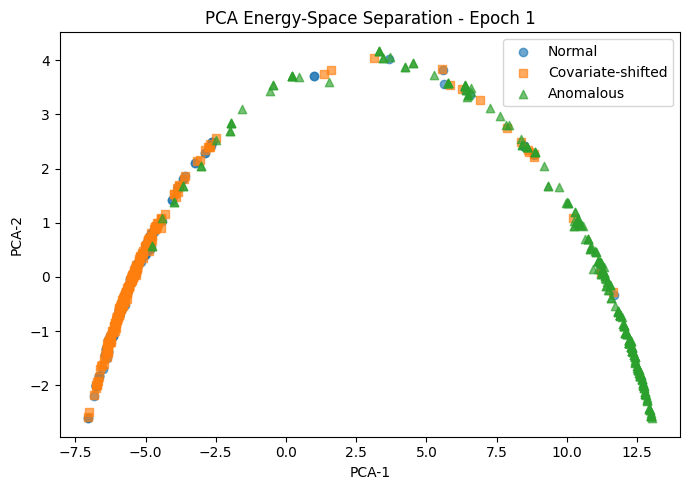

Validation Eval -> tau=-0.864869, ValF1=0.9767, ValAUROC=0.9898, ValAUPRC=0.9868, EnergyStd=0.84704661, EnergyRange=[-0.986315, 1.210764]
New best model saved at epoch 1: val_auprc=0.9868, threshold=-0.864869
Test Monitor -> Acc=0.9565, Prec=0.8889, Rec=1.0000, F1=0.9412, AUROC=0.9935, AUPRC=0.9873
Confusion Matrix:
 [[42  3]
 [ 0 24]]
Epoch 1 - Test Energy Loss: 0.0200

Epoch 2/15 [One-Phase Energy Training] lambda_in=0.5, lambda_cov=0.25, lambda_anomaly=0.25


Training Epoch 2: 100%|██████████| 9/9 [00:01<00:00,  6.46it/s]


Epoch 2 - Total Loss: 0.0729
   => L_in: 0.0483, L_cov: 0.0309, L_anom: 0.1639
   => Mean E_in: -0.7112, Mean E_cov: -0.7150, Mean E_anom: 0.8600

PCA explained variance at epoch 2: PC1=0.9486, PC2=0.0351, Total=0.9838

Energy statistics at epoch 2:
Normal: mean=-0.714918, std=0.115876, min=-0.760303, max=0.724692, n=285
Noisy/Cov: mean=-0.713118, std=0.116646, min=-0.758721, max=0.737422, n=285
Anomaly: mean=0.659653, std=0.359904, min=-0.649160, max=0.955797, n=267


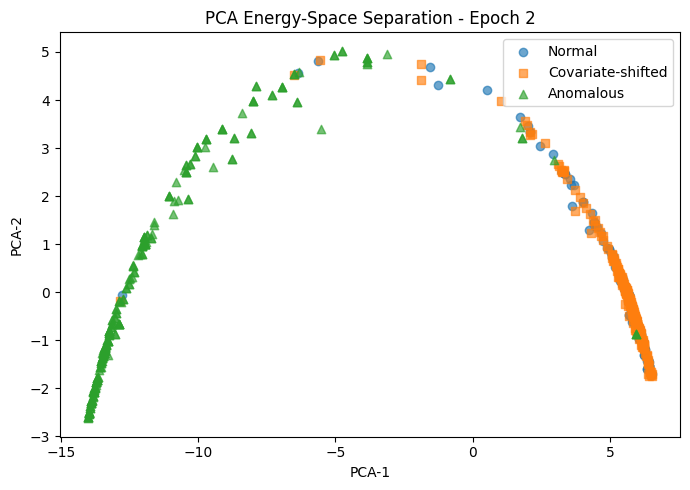

Validation Eval -> tau=-0.666320, ValF1=0.9778, ValAUROC=0.9989, ValAUPRC=0.9980, EnergyStd=0.70945692, EnergyRange=[-0.761358, 0.957954]
New best model saved at epoch 2: val_auprc=0.9980, threshold=-0.666320
Test Monitor -> Acc=0.9565, Prec=0.8889, Rec=1.0000, F1=0.9412, AUROC=0.9889, AUPRC=0.9778
Confusion Matrix:
 [[42  3]
 [ 0 24]]
Epoch 2 - Test Energy Loss: 0.0271

Epoch 3/15 [One-Phase Energy Training] lambda_in=0.5, lambda_cov=0.25, lambda_anomaly=0.25


Training Epoch 3: 100%|██████████| 9/9 [00:00<00:00, 24.37it/s]


Epoch 3 - Total Loss: 0.0461
   => L_in: 0.0370, L_cov: 0.0166, L_anom: 0.0939
   => Mean E_in: -0.7924, Mean E_cov: -0.7852, Mean E_anom: 0.5649

PCA explained variance at epoch 3: PC1=0.9609, PC2=0.0302, Total=0.9911

Energy statistics at epoch 3:
Normal: mean=-0.970372, std=0.290698, min=-1.105424, max=0.793998, n=270
Noisy/Cov: mean=-0.970469, std=0.291507, min=-1.105485, max=0.793518, n=270
Anomaly: mean=0.701929, std=0.261066, min=-0.918226, max=0.844572, n=282


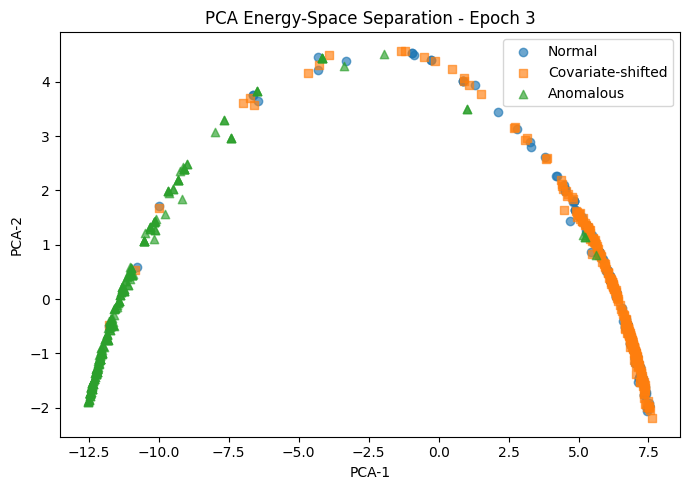

Validation Eval -> tau=-0.204840, ValF1=0.9778, ValAUROC=0.9989, ValAUPRC=0.9980, EnergyStd=0.85394162, EnergyRange=[-1.099749, 0.835978]
No improvement for 1/10 epochs. Best epoch so far: 2, best val_auprc=0.9980
Test Monitor -> Acc=0.9710, Prec=0.9231, Rec=1.0000, F1=0.9600, AUROC=0.9852, AUPRC=0.9670
Confusion Matrix:
 [[43  2]
 [ 0 24]]
Epoch 3 - Test Energy Loss: 0.0212

Epoch 4/15 [One-Phase Energy Training] lambda_in=0.5, lambda_cov=0.25, lambda_anomaly=0.25


Training Epoch 4: 100%|██████████| 9/9 [00:00<00:00, 21.72it/s]


Epoch 4 - Total Loss: 0.0309
   => L_in: 0.0275, L_cov: 0.0147, L_anom: 0.0538
   => Mean E_in: -0.8162, Mean E_cov: -0.8204, Mean E_anom: 0.7967

PCA explained variance at epoch 4: PC1=0.9686, PC2=0.0251, Total=0.9936

Energy statistics at epoch 4:
Normal: mean=-0.689951, std=0.253600, min=-0.783358, max=0.902342, n=272
Noisy/Cov: mean=-0.689003, std=0.252854, min=-0.783708, max=0.908163, n=272
Anomaly: mean=0.770445, std=0.347202, min=-0.622287, max=0.993195, n=280


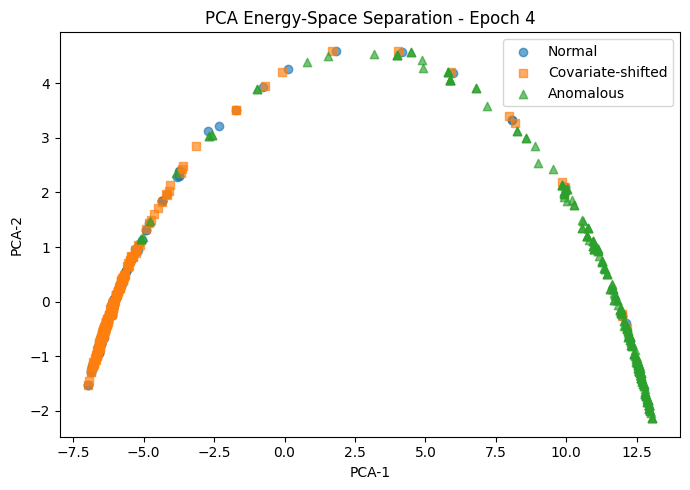

Validation Eval -> tau=-0.005751, ValF1=1.0000, ValAUROC=1.0000, ValAUPRC=1.0000, EnergyStd=0.75726897, EnergyRange=[-0.781054, 0.992340]
New best model saved at epoch 4: val_auprc=1.0000, threshold=-0.005751
Test Monitor -> Acc=0.9710, Prec=0.9231, Rec=1.0000, F1=0.9600, AUROC=0.9889, AUPRC=0.9761
Confusion Matrix:
 [[43  2]
 [ 0 24]]
Epoch 4 - Test Energy Loss: 0.0237

Epoch 5/15 [One-Phase Energy Training] lambda_in=0.5, lambda_cov=0.25, lambda_anomaly=0.25


Training Epoch 5: 100%|██████████| 9/9 [00:00<00:00, 29.51it/s]


Epoch 5 - Total Loss: 0.0387
   => L_in: 0.0331, L_cov: 0.0185, L_anom: 0.0700
   => Mean E_in: -0.7051, Mean E_cov: -0.7008, Mean E_anom: 0.6936

PCA explained variance at epoch 5: PC1=0.9634, PC2=0.0294, Total=0.9927

Energy statistics at epoch 5:
Normal: mean=-0.800593, std=0.289235, min=-0.940275, max=0.854408, n=269
Noisy/Cov: mean=-0.798598, std=0.289471, min=-0.938981, max=0.854096, n=269
Anomaly: mean=0.769861, std=0.297050, min=-0.643815, max=0.921565, n=283


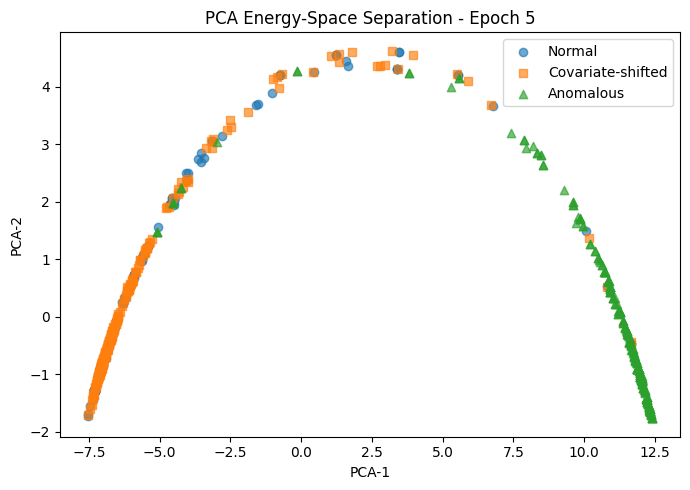

Validation Eval -> tau=0.006218, ValF1=1.0000, ValAUROC=1.0000, ValAUPRC=1.0000, EnergyStd=0.79860908, EnergyRange=[-0.936493, 0.920928]
No improvement for 1/10 epochs. Best epoch so far: 4, best val_auprc=1.0000
Test Monitor -> Acc=0.9710, Prec=0.9231, Rec=1.0000, F1=0.9600, AUROC=0.9889, AUPRC=0.9771
Confusion Matrix:
 [[43  2]
 [ 0 24]]
Epoch 5 - Test Energy Loss: 0.0243

Epoch 6/15 [One-Phase Energy Training] lambda_in=0.5, lambda_cov=0.25, lambda_anomaly=0.25


Training Epoch 6: 100%|██████████| 9/9 [00:00<00:00, 25.38it/s]


Epoch 6 - Total Loss: 0.0364
   => L_in: 0.0344, L_cov: 0.0143, L_anom: 0.0622
   => Mean E_in: -0.7709, Mean E_cov: -0.7707, Mean E_anom: 0.6311

PCA explained variance at epoch 6: PC1=0.9718, PC2=0.0217, Total=0.9935

Energy statistics at epoch 6:
Normal: mean=-0.848580, std=0.196642, min=-0.938049, max=0.600299, n=276
Noisy/Cov: mean=-0.847934, std=0.196103, min=-0.937148, max=0.597430, n=276
Anomaly: mean=0.526929, std=0.315485, min=-0.935509, max=0.711434, n=276


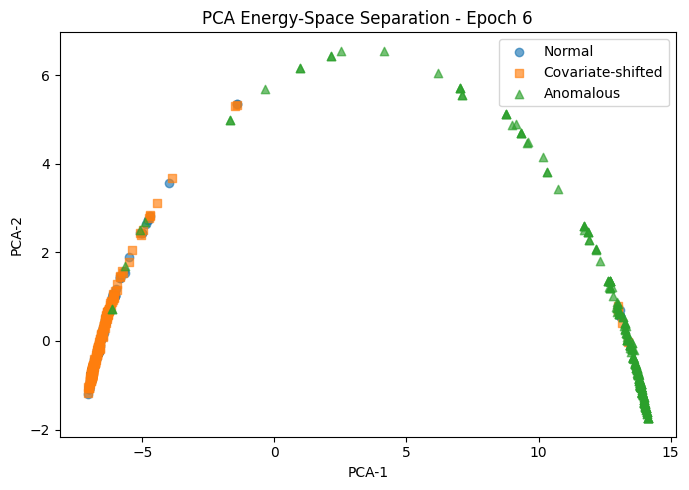

Validation Eval -> tau=-0.801522, ValF1=0.9767, ValAUROC=0.9977, ValAUPRC=0.9962, EnergyStd=0.66954303, EnergyRange=[-0.951978, 0.711393]
No improvement for 2/10 epochs. Best epoch so far: 4, best val_auprc=1.0000
Test Monitor -> Acc=0.9710, Prec=0.9231, Rec=1.0000, F1=0.9600, AUROC=0.9917, AUPRC=0.9840
Confusion Matrix:
 [[43  2]
 [ 0 24]]
Epoch 6 - Test Energy Loss: 0.0259

Epoch 7/15 [One-Phase Energy Training] lambda_in=0.5, lambda_cov=0.25, lambda_anomaly=0.25


Training Epoch 7: 100%|██████████| 9/9 [00:00<00:00, 25.90it/s]


Epoch 7 - Total Loss: 0.0338
   => L_in: 0.0188, L_cov: 0.0052, L_anom: 0.0922
   => Mean E_in: -0.8448, Mean E_cov: -0.8513, Mean E_anom: 0.6776

PCA explained variance at epoch 7: PC1=0.9740, PC2=0.0196, Total=0.9936

Energy statistics at epoch 7:
Normal: mean=-0.762031, std=0.175800, min=-0.838851, max=0.978190, n=278
Noisy/Cov: mean=-0.760158, std=0.175219, min=-0.840009, max=0.978838, n=278
Anomaly: mean=0.896671, std=0.317839, min=-0.791529, max=0.991042, n=274


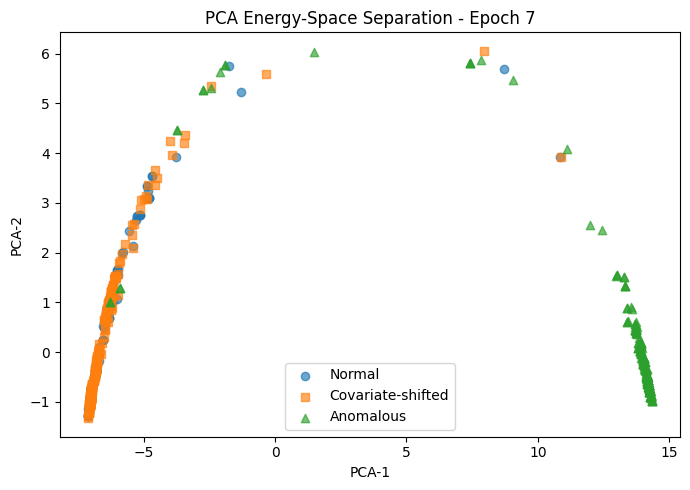

Validation Eval -> tau=-0.586082, ValF1=1.0000, ValAUROC=1.0000, ValAUPRC=1.0000, EnergyStd=0.83773065, EnergyRange=[-0.843793, 0.987799]
No improvement for 3/10 epochs. Best epoch so far: 4, best val_auprc=1.0000
Test Monitor -> Acc=0.9710, Prec=0.9231, Rec=1.0000, F1=0.9600, AUROC=0.9907, AUPRC=0.9812
Confusion Matrix:
 [[43  2]
 [ 0 24]]
Epoch 7 - Test Energy Loss: 0.0241

Epoch 8/15 [One-Phase Energy Training] lambda_in=0.5, lambda_cov=0.25, lambda_anomaly=0.25


Training Epoch 8: 100%|██████████| 9/9 [00:00<00:00, 25.55it/s]


Epoch 8 - Total Loss: 0.0309
   => L_in: 0.0300, L_cov: 0.0203, L_anom: 0.0431
   => Mean E_in: -0.6884, Mean E_cov: -0.6879, Mean E_anom: 0.7679

PCA explained variance at epoch 8: PC1=0.9755, PC2=0.0174, Total=0.9929

Energy statistics at epoch 8:
Normal: mean=-0.653053, std=0.219401, min=-0.739182, max=0.617282, n=279
Noisy/Cov: mean=-0.651835, std=0.222393, min=-0.739443, max=0.617610, n=279
Anomaly: mean=0.558527, std=0.258398, min=-0.669290, max=0.640657, n=273


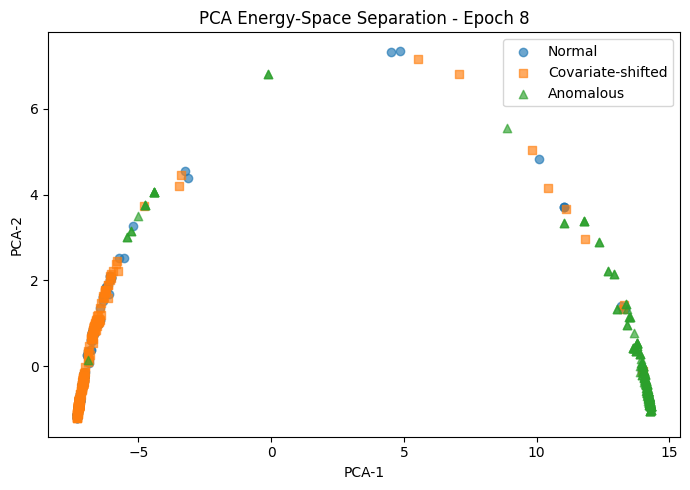

Validation Eval -> tau=-0.109842, ValF1=1.0000, ValAUROC=1.0000, ValAUPRC=1.0000, EnergyStd=0.63130492, EnergyRange=[-0.738609, 0.636387]
No improvement for 4/10 epochs. Best epoch so far: 4, best val_auprc=1.0000
Test Monitor -> Acc=0.9710, Prec=0.9231, Rec=1.0000, F1=0.9600, AUROC=0.9898, AUPRC=0.9795
Confusion Matrix:
 [[43  2]
 [ 0 24]]
Epoch 8 - Test Energy Loss: 0.0186

Epoch 9/15 [One-Phase Energy Training] lambda_in=0.5, lambda_cov=0.25, lambda_anomaly=0.25


Training Epoch 9: 100%|██████████| 9/9 [00:00<00:00, 12.39it/s]


Epoch 9 - Total Loss: 0.0302
   => L_in: 0.0365, L_cov: 0.0190, L_anom: 0.0289
   => Mean E_in: -0.6857, Mean E_cov: -0.6804, Mean E_anom: 0.5685

PCA explained variance at epoch 9: PC1=0.9519, PC2=0.0398, Total=0.9917

Energy statistics at epoch 9:
Normal: mean=-0.839807, std=0.436403, min=-1.030657, max=0.648859, n=276
Noisy/Cov: mean=-0.835410, std=0.441129, min=-1.031978, max=0.648787, n=276
Anomaly: mean=0.635336, std=0.219780, min=-0.980254, max=0.677442, n=276


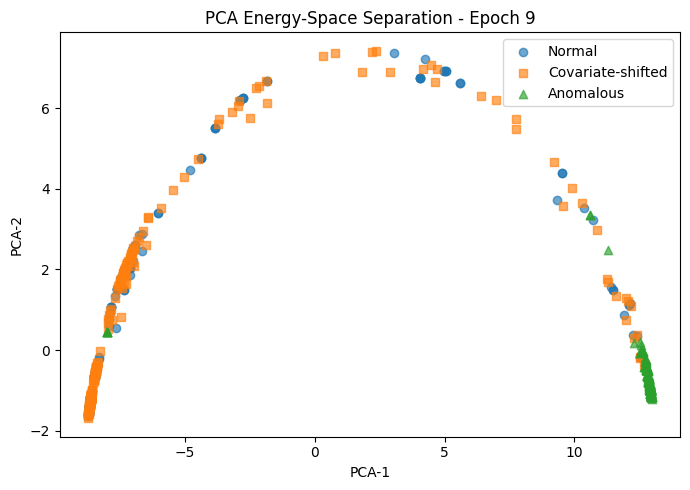

Validation Eval -> tau=0.614746, ValF1=1.0000, ValAUROC=1.0000, ValAUPRC=1.0000, EnergyStd=0.80447161, EnergyRange=[-1.029477, 0.674692]
No improvement for 5/10 epochs. Best epoch so far: 4, best val_auprc=1.0000
Test Monitor -> Acc=0.9710, Prec=0.9231, Rec=1.0000, F1=0.9600, AUROC=0.9917, AUPRC=0.9835
Confusion Matrix:
 [[43  2]
 [ 0 24]]
Epoch 9 - Test Energy Loss: 0.0353

Epoch 10/15 [One-Phase Energy Training] lambda_in=0.5, lambda_cov=0.25, lambda_anomaly=0.25


Training Epoch 10: 100%|██████████| 9/9 [00:00<00:00, 25.00it/s]


Epoch 10 - Total Loss: 0.0341
   => L_in: 0.0404, L_cov: 0.0242, L_anom: 0.0315
   => Mean E_in: -1.0362, Mean E_cov: -1.0315, Mean E_anom: 0.5928

PCA explained variance at epoch 10: PC1=0.9730, PC2=0.0190, Total=0.9919

Energy statistics at epoch 10:
Normal: mean=-1.155325, std=0.341890, min=-1.272007, max=0.529877, n=254
Noisy/Cov: mean=-1.153587, std=0.346428, min=-1.271857, max=0.529907, n=254
Anomaly: mean=0.498181, std=0.185237, min=-0.968500, max=0.573869, n=298


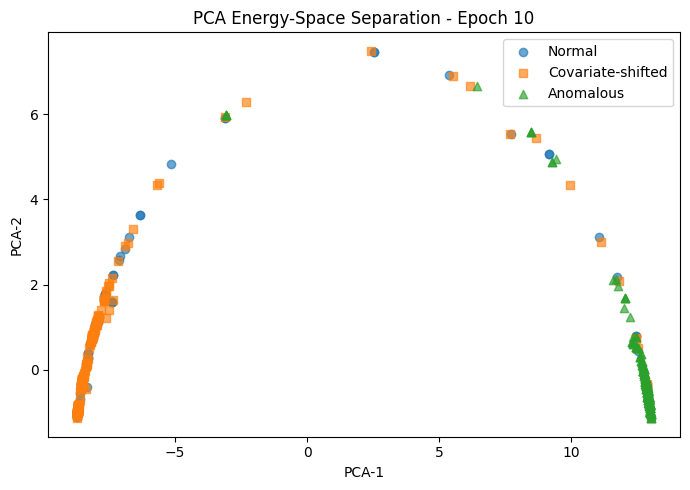

Validation Eval -> tau=0.001277, ValF1=1.0000, ValAUROC=1.0000, ValAUPRC=1.0000, EnergyStd=0.84374666, EnergyRange=[-1.267402, 0.575423]
No improvement for 6/10 epochs. Best epoch so far: 4, best val_auprc=1.0000
Test Monitor -> Acc=0.9710, Prec=0.9231, Rec=1.0000, F1=0.9600, AUROC=0.9907, AUPRC=0.9812
Confusion Matrix:
 [[43  2]
 [ 0 24]]
Epoch 10 - Test Energy Loss: 0.0192

Epoch 11/15 [One-Phase Energy Training] lambda_in=0.5, lambda_cov=0.25, lambda_anomaly=0.25


Training Epoch 11: 100%|██████████| 9/9 [00:00<00:00, 25.52it/s]


Epoch 11 - Total Loss: 0.0341
   => L_in: 0.0121, L_cov: 0.0067, L_anom: 0.1056
   => Mean E_in: -1.1390, Mean E_cov: -1.1403, Mean E_anom: 0.5514

PCA explained variance at epoch 11: PC1=0.9682, PC2=0.0242, Total=0.9924

Energy statistics at epoch 11:
Normal: mean=-1.006837, std=0.252894, min=-1.070584, max=0.927690, n=276
Noisy/Cov: mean=-1.006254, std=0.252073, min=-1.070700, max=0.927090, n=276
Anomaly: mean=0.804351, std=0.398653, min=-1.033755, max=0.973105, n=276


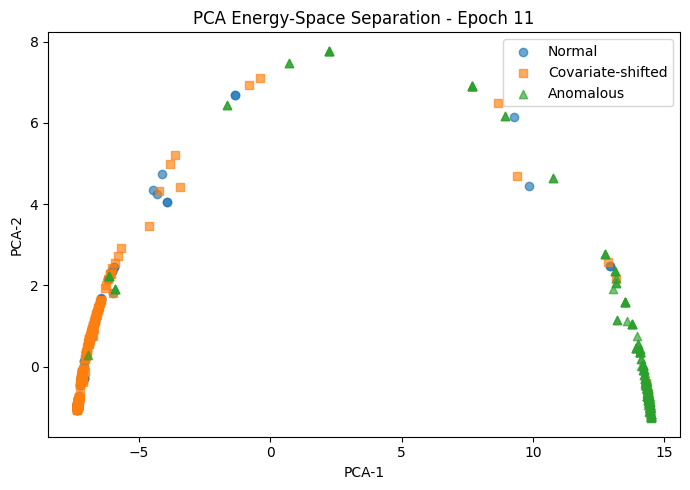

Validation Eval -> tau=-0.443575, ValF1=1.0000, ValAUROC=1.0000, ValAUPRC=1.0000, EnergyStd=0.94116843, EnergyRange=[-1.070429, 0.974556]
No improvement for 7/10 epochs. Best epoch so far: 4, best val_auprc=1.0000
Test Monitor -> Acc=0.9710, Prec=0.9231, Rec=1.0000, F1=0.9600, AUROC=0.9898, AUPRC=0.9787
Confusion Matrix:
 [[43  2]
 [ 0 24]]
Epoch 11 - Test Energy Loss: 0.0226

Epoch 12/15 [One-Phase Energy Training] lambda_in=0.5, lambda_cov=0.25, lambda_anomaly=0.25


Training Epoch 12: 100%|██████████| 9/9 [00:00<00:00, 22.46it/s]


Epoch 12 - Total Loss: 0.0286
   => L_in: 0.0285, L_cov: 0.0168, L_anom: 0.0404
   => Mean E_in: -0.8254, Mean E_cov: -0.8223, Mean E_anom: 0.8374

PCA explained variance at epoch 12: PC1=0.9739, PC2=0.0191, Total=0.9930

Energy statistics at epoch 12:
Normal: mean=-0.692283, std=0.126085, min=-0.721700, max=0.776627, n=269
Noisy/Cov: mean=-0.692026, std=0.125744, min=-0.722358, max=0.774499, n=269
Anomaly: mean=0.740387, std=0.312854, min=-0.696136, max=0.918116, n=283


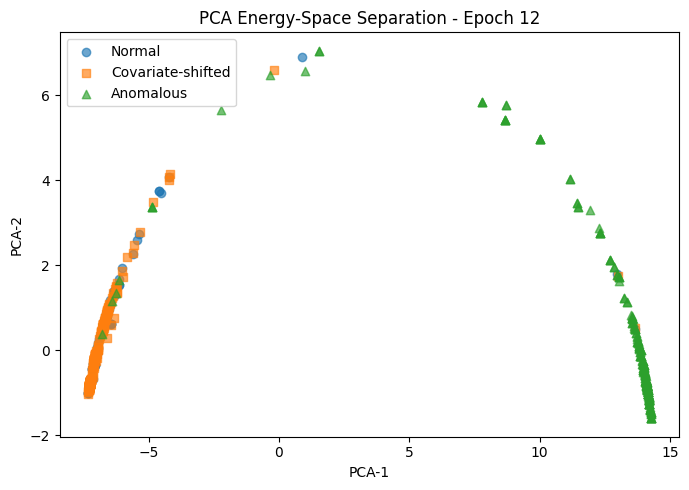

Validation Eval -> tau=-0.590825, ValF1=1.0000, ValAUROC=1.0000, ValAUPRC=1.0000, EnergyStd=0.72912264, EnergyRange=[-0.722889, 0.919663]
No improvement for 8/10 epochs. Best epoch so far: 4, best val_auprc=1.0000
Test Monitor -> Acc=0.9710, Prec=0.9231, Rec=1.0000, F1=0.9600, AUROC=0.9870, AUPRC=0.9704
Confusion Matrix:
 [[43  2]
 [ 0 24]]
Epoch 12 - Test Energy Loss: 0.0215

Epoch 13/15 [One-Phase Energy Training] lambda_in=0.5, lambda_cov=0.25, lambda_anomaly=0.25


Training Epoch 13: 100%|██████████| 9/9 [00:00<00:00, 18.21it/s]


Epoch 13 - Total Loss: 0.0352
   => L_in: 0.0253, L_cov: 0.0147, L_anom: 0.0754
   => Mean E_in: -0.6134, Mean E_cov: -0.6058, Mean E_anom: 0.6242

PCA explained variance at epoch 13: PC1=0.9739, PC2=0.0188, Total=0.9927

Energy statistics at epoch 13:
Normal: mean=-0.750014, std=0.101588, min=-0.795954, max=0.545951, n=268
Noisy/Cov: mean=-0.749266, std=0.103047, min=-0.795648, max=0.546588, n=268
Anomaly: mean=0.550285, std=0.299710, min=-0.727227, max=0.724865, n=284


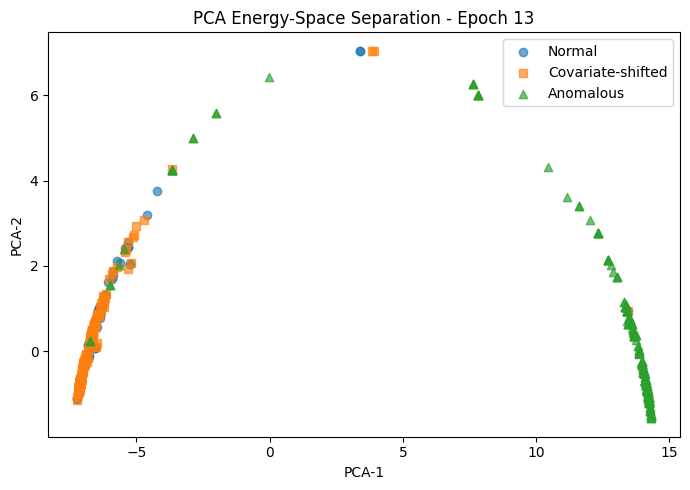

Validation Eval -> tau=-0.523696, ValF1=1.0000, ValAUROC=1.0000, ValAUPRC=1.0000, EnergyStd=0.66511905, EnergyRange=[-0.790471, 0.726335]
No improvement for 9/10 epochs. Best epoch so far: 4, best val_auprc=1.0000
Test Monitor -> Acc=0.9710, Prec=0.9231, Rec=1.0000, F1=0.9600, AUROC=0.9880, AUPRC=0.9733
Confusion Matrix:
 [[43  2]
 [ 0 24]]
Epoch 13 - Test Energy Loss: 0.0178

Epoch 14/15 [One-Phase Energy Training] lambda_in=0.5, lambda_cov=0.25, lambda_anomaly=0.25


Training Epoch 14: 100%|██████████| 9/9 [00:00<00:00, 14.44it/s]


Epoch 14 - Total Loss: 0.0299
   => L_in: 0.0279, L_cov: 0.0174, L_anom: 0.0462
   => Mean E_in: -0.8565, Mean E_cov: -0.8611, Mean E_anom: 0.6106

PCA explained variance at epoch 14: PC1=0.9719, PC2=0.0213, Total=0.9931

Energy statistics at epoch 14:
Normal: mean=-0.983697, std=0.208071, min=-1.067646, max=0.663057, n=275
Noisy/Cov: mean=-0.983010, std=0.208936, min=-1.066812, max=0.665399, n=275
Anomaly: mean=0.613285, std=0.219878, min=-0.961106, max=0.715375, n=277


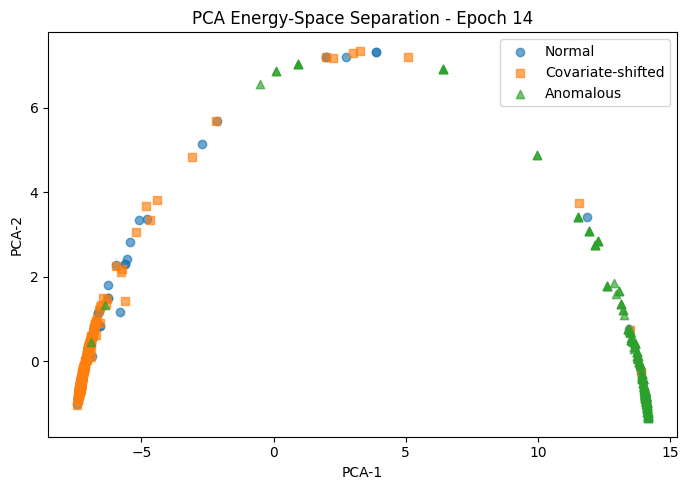

Validation Eval -> tau=-0.541390, ValF1=1.0000, ValAUROC=1.0000, ValAUPRC=1.0000, EnergyStd=0.78960258, EnergyRange=[-1.058390, 0.715457]
No improvement for 10/10 epochs. Best epoch so far: 4, best val_auprc=1.0000
Test Monitor -> Acc=0.9710, Prec=0.9231, Rec=1.0000, F1=0.9600, AUROC=0.9898, AUPRC=0.9787
Confusion Matrix:
 [[43  2]
 [ 0 24]]
Epoch 14 - Test Energy Loss: 0.0181

Early stopping triggered at epoch 14. Best epoch was 4 with val_auprc=1.0000.

GrEAt training time: 29.84 seconds

Restored best model from epoch 4 with val_auprc=1.0000
Best validation-selected energy threshold: -0.005751

Final test results using restored best model:
Acc:   0.9710
Prec:  0.9231
Rec:   1.0000
F1:    0.9600
AUROC: 0.9889
AUPRC: 0.9761
Final Confusion Matrix:
 [[43  2]
 [ 0 24]]
Final test energy stats -> std=0.75691712, min=-0.779765, max=0.980447


In [20]:
# ---------------------------------------------------------------------------
# 8) Train in One Phase: L_in + L_cov + L_anom
# ---------------------------------------------------------------------------
import time
model = make_great_model().to(device)

optimizer = AdamW(model.parameters(), lr=5e-4)

num_epochs = 15
noise_std = 0.01

lambda_in =best_config["lambda_in"]
lambda_cov = best_config["lambda_cov"]
lambda_anomaly = best_config["lambda_anomaly"]

margin_in =best_config["margin_in"]
margin_cov = best_config["margin_cov"]
margin_anomaly = best_config["margin_anomaly"]

epoch_total_losses = []
epoch_in_losses = []
epoch_cov_losses = []
epoch_anom_losses = []
epoch_test_losses = []
epoch_energy_f1 = []

epoch_val_f1 = []
epoch_val_auroc = []
epoch_val_auprc = []
epoch_test_auroc = []
epoch_test_auprc = []

# ---------------------------------------------------------------------------
# Early stopping setup
# ---------------------------------------------------------------------------
patience = 10
min_delta = 1e-4

best_val_metric = -np.inf
best_epoch = -1
best_energy_threshold = None
best_model_state = None
epochs_without_improvement = 0

# Use validation AUPRC for early stopping because anomaly detection is imbalanced.
# Switch this to "val_f1" for threshold-dependent stopping.
early_stop_metric_name = "val_auprc"

# Track training time
great_train_start_time = time.time()

for epoch in range(num_epochs):
    model.train()

    total_loss = 0.0
    in_loss_sum = 0.0
    cov_loss_sum = 0.0
    anom_loss_sum = 0.0

    in_e_vals = []
    cov_e_vals = []
    anomaly_e_vals = []

    print(
        f"\nEpoch {epoch + 1}/{num_epochs} [One-Phase Energy Training] "
        f"lambda_in={lambda_in}, "
        f"lambda_cov={lambda_cov}, "
        f"lambda_anomaly={lambda_anomaly}"
    )

    batch_count = 0

    for batch in tqdm(train_loader, desc=f"Training Epoch {epoch + 1}"):
        batch_count += 1

        numeric = batch["numeric"].to(device)
        categorical = batch["categorical"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()

        energy_scores = model(numeric, categorical)

        normal_mask = labels == 0
        anomaly_mask = labels == 1

        # Generate benign covariate-shifted normal samples.
        if normal_mask.sum() > 0:
            numeric_cov = make_covariate_shifted_numeric(
                numeric[normal_mask],
                noise_std=noise_std
            )
            categorical_cov = categorical[normal_mask]
            energy_cov_scores = model(numeric_cov, categorical_cov)
        else:
            energy_cov_scores = None

        total_batch_loss, L_in_val, L_cov_val, L_anom_val = energy_only_loss(
            energy_scores=energy_scores,
            labels=labels,
            energy_cov_scores=energy_cov_scores,
            margin_in=margin_in,
            margin_cov=margin_cov,
            margin_anomaly=margin_anomaly,
            lambda_in=lambda_in,
            lambda_cov=lambda_cov,
            lambda_anomaly=lambda_anomaly,
            return_components=True
        )

        total_batch_loss.backward()

        # For stabilizing FT-Transformer training.
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        total_loss += total_batch_loss.item()
        in_loss_sum += L_in_val
        cov_loss_sum += L_cov_val
        anom_loss_sum += L_anom_val

        if normal_mask.sum() > 0:
            in_e_vals.append(energy_scores[normal_mask].detach().mean().item())

        if energy_cov_scores is not None and energy_cov_scores.numel() > 0:
            cov_e_vals.append(energy_cov_scores.detach().mean().item())

        if anomaly_mask.sum() > 0:
            anomaly_e_vals.append(energy_scores[anomaly_mask].detach().mean().item())

    # -----------------------------------------------------------------------
    # Epoch-level training summaries
    # -----------------------------------------------------------------------
    avg_total_loss = total_loss / max(batch_count, 1)
    avg_in_loss = in_loss_sum / max(batch_count, 1)
    avg_cov_loss = cov_loss_sum / max(batch_count, 1)
    avg_anom_loss = anom_loss_sum / max(batch_count, 1)

    avg_e_in = np.mean(in_e_vals) if len(in_e_vals) > 0 else 0.0
    avg_e_cov = np.mean(cov_e_vals) if len(cov_e_vals) > 0 else 0.0
    avg_e_anom = np.mean(anomaly_e_vals) if len(anomaly_e_vals) > 0 else 0.0

    print(f"Epoch {epoch + 1} - Total Loss: {avg_total_loss:.4f}")
    print(
        f"   => L_in: {avg_in_loss:.4f}, "
        f"L_cov: {avg_cov_loss:.4f}, "
        f"L_anom: {avg_anom_loss:.4f}"
    )
    print(
        f"   => Mean E_in: {avg_e_in:.4f}, "
        f"Mean E_cov: {avg_e_cov:.4f}, "
        f"Mean E_anom: {avg_e_anom:.4f}"
    )

    # -----------------------------------------------------------------------
    # Visualization.
    # For speed, you may change this to: if (epoch + 1) % 5 == 0:
    # -----------------------------------------------------------------------
    visualize_in_2D(
        model,
        train_loader,
        epoch=epoch + 1,
        margin_in=margin_in,
        margin_cov=margin_cov,
        margin_anomaly=margin_anomaly,
        noise_std=noise_std,
        max_points=5000,
        device=device
    )

    # -----------------------------------------------------------------------
    # Validation-based threshold selection
    # -----------------------------------------------------------------------
    energy_threshold, val_energy_f1 = find_best_energy_threshold(
        model,
        val_loader
    )

    val_acc, val_prec, val_rec, val_f1, val_auroc, val_auprc, \
    val_labels, val_preds, val_energy = evaluate_model_energy(
        model,
        val_loader,
        energy_threshold
    )

    val_energy_std = float(np.std(val_energy))
    val_energy_min = float(np.min(val_energy))
    val_energy_max = float(np.max(val_energy))

    print(
        f"Validation Eval -> tau={energy_threshold:.6f}, "
        f"ValF1={val_f1:.4f}, "
        f"ValAUROC={val_auroc:.4f}, "
        f"ValAUPRC={val_auprc:.4f}, "
        f"EnergyStd={val_energy_std:.8f}, "
        f"EnergyRange=[{val_energy_min:.6f}, {val_energy_max:.6f}]"
    )

    # Choose metric for early stopping.
    if early_stop_metric_name == "val_auprc":
        current_val_metric = val_auprc
    elif early_stop_metric_name == "val_f1":
        current_val_metric = val_f1
    else:
        raise ValueError("early_stop_metric_name must be either 'val_auprc' or 'val_f1'")

    # Save best checkpoint.
    if current_val_metric > best_val_metric + min_delta:
        best_val_metric = current_val_metric
        best_epoch = epoch + 1
        best_energy_threshold = energy_threshold
        best_model_state = copy.deepcopy(model.state_dict())
        epochs_without_improvement = 0

        print(
            f"New best model saved at epoch {best_epoch}: "
            f"{early_stop_metric_name}={best_val_metric:.4f}, "
            f"threshold={best_energy_threshold:.6f}"
        )
    else:
        epochs_without_improvement += 1
        print(
            f"No improvement for {epochs_without_improvement}/{patience} epochs. "
            f"Best epoch so far: {best_epoch}, "
            f"best {early_stop_metric_name}={best_val_metric:.4f}"
        )

    # -----------------------------------------------------------------------
    # Test evaluation for monitoring only.
    # Do NOT use test metrics for model selection.
    # -----------------------------------------------------------------------
    accuracy, precision, recall, f1, auroc, auprc, all_labels, all_preds, all_energy = evaluate_model_energy(
        model,
        test_loader,
        energy_threshold
    )

    print(
        f"Test Monitor -> Acc={accuracy:.4f}, Prec={precision:.4f}, "
        f"Rec={recall:.4f}, F1={f1:.4f}, "
        f"AUROC={auroc:.4f}, AUPRC={auprc:.4f}"
    )

    cm = confusion_matrix(all_labels, all_preds)
    print("Confusion Matrix:\n", cm)

    # -----------------------------------------------------------------------
    # Test energy loss for tracking only.
    # -----------------------------------------------------------------------
    model.eval()
    test_loss_sum = 0.0
    test_batches = 0

    with torch.no_grad():
        for b_test in test_loader:
            test_batches += 1

            numeric_t = b_test["numeric"].to(device)
            categorical_t = b_test["categorical"].to(device)
            labels_t = b_test["labels"].to(device)

            energy_t = model(numeric_t, categorical_t)
            normal_mask_t = labels_t == 0

            if normal_mask_t.sum() > 0:
                numeric_cov_t = make_covariate_shifted_numeric(
                    numeric_t[normal_mask_t],
                    noise_std=noise_std
                )
                categorical_cov_t = categorical_t[normal_mask_t]
                energy_cov_t = model(numeric_cov_t, categorical_cov_t)
            else:
                energy_cov_t = None

            test_loss_val = energy_only_loss(
                energy_scores=energy_t,
                labels=labels_t,
                energy_cov_scores=energy_cov_t,
                margin_in=margin_in,
                margin_cov=margin_cov,
                margin_anomaly=margin_anomaly,
                lambda_in=lambda_in,
                lambda_cov=lambda_cov,
                lambda_anomaly=lambda_anomaly,
                return_components=False
            )

            test_loss_sum += test_loss_val.item()

    test_loss_avg = test_loss_sum / max(test_batches, 1)
    print(f"Epoch {epoch + 1} - Test Energy Loss: {test_loss_avg:.4f}")

    # -----------------------------------------------------------------------
    # Save history before possible early-stopping break.
    # -----------------------------------------------------------------------
    epoch_total_losses.append(avg_total_loss)
    epoch_in_losses.append(avg_in_loss)
    epoch_cov_losses.append(avg_cov_loss)
    epoch_anom_losses.append(avg_anom_loss)
    epoch_test_losses.append(test_loss_avg)
    epoch_energy_f1.append(f1)

    epoch_val_f1.append(val_f1)
    epoch_val_auroc.append(val_auroc)
    epoch_val_auprc.append(val_auprc)
    epoch_test_auroc.append(auroc)
    epoch_test_auprc.append(auprc)

    # -----------------------------------------------------------------------
    # Early stopping check. The break must be inside this if block.
    # -----------------------------------------------------------------------
    if epochs_without_improvement >= patience:
        print(
            f"\nEarly stopping triggered at epoch {epoch + 1}. "
            f"Best epoch was {best_epoch} with "
            f"{early_stop_metric_name}={best_val_metric:.4f}."
        )
        break


# Stop the timer after the training/early-stopping loop completes.
great_train_time_sec = time.time() - great_train_start_time
print(f"\nGrEAt training time: {great_train_time_sec:.2f} seconds")

# ---------------------------------------------------------------------------
# Restore best validation checkpoint
# ---------------------------------------------------------------------------
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print(
        f"\nRestored best model from epoch {best_epoch} "
        f"with {early_stop_metric_name}={best_val_metric:.4f}"
    )
    print(f"Best validation-selected energy threshold: {best_energy_threshold:.6f}")
else:
    print("Warning: No best model was saved. Using final epoch model.")

    # Fallback threshold if something unexpected happened.
    best_energy_threshold, _ = find_best_energy_threshold(model, val_loader)


# ---------------------------------------------------------------------------
# Final test evaluation using restored best model
# ---------------------------------------------------------------------------
accuracy, precision, recall, f1, auroc, auprc, all_labels, all_preds, all_energy = evaluate_model_energy(
    model,
    test_loader,
    best_energy_threshold
)

print("\nFinal test results using restored best model:")
print(f"Acc:   {accuracy:.4f}")
print(f"Prec:  {precision:.4f}")
print(f"Rec:   {recall:.4f}")
print(f"F1:    {f1:.4f}")
print(f"AUROC: {auroc:.4f}")
print(f"AUPRC: {auprc:.4f}")

cm = confusion_matrix(all_labels, all_preds)
print("Final Confusion Matrix:\n", cm)

final_energy_std = float(np.std(all_energy))
final_energy_min = float(np.min(all_energy))
final_energy_max = float(np.max(all_energy))

print(
    f"Final test energy stats -> "
    f"std={final_energy_std:.8f}, "
    f"min={final_energy_min:.6f}, "
    f"max={final_energy_max:.6f}"
)


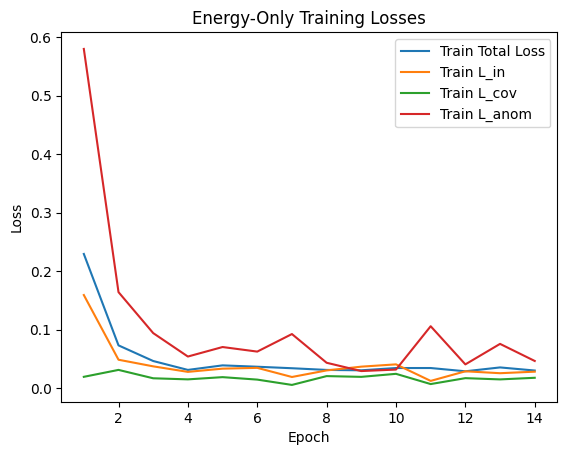

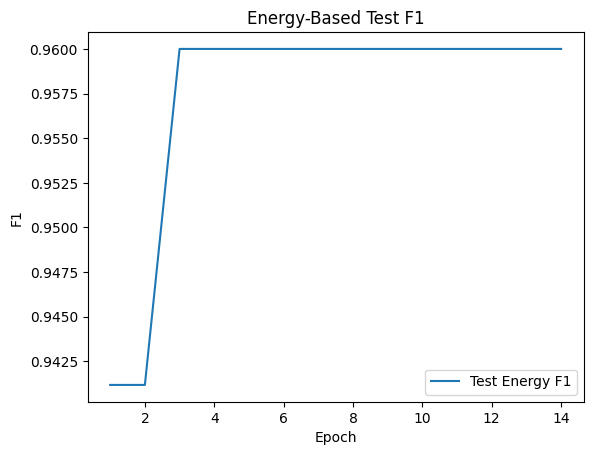

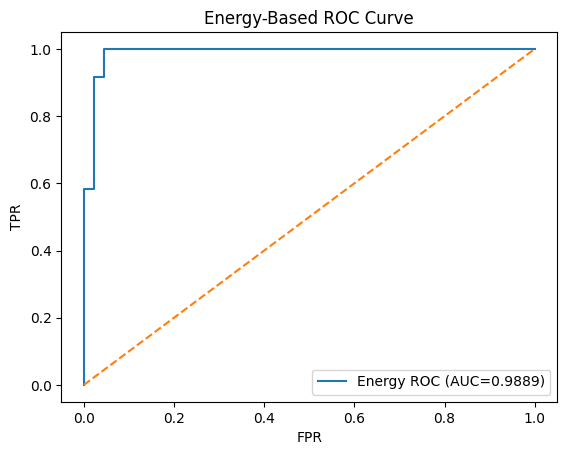

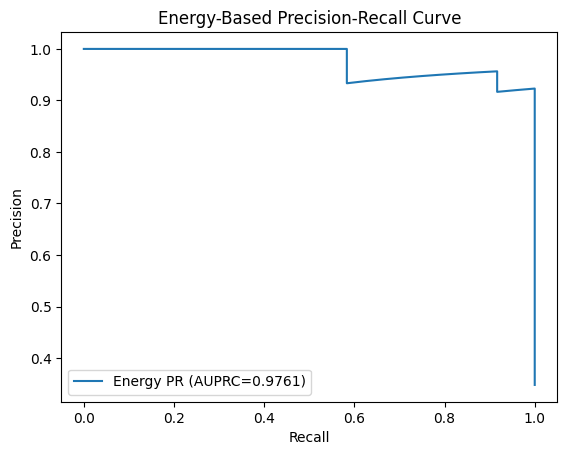

Final AUROC: 0.9889
Final AUPRC: 0.9761
Final energy-threshold test metrics:
accuracy, precision, recall, f1
(0.9710144927536232, 0.9230769230769231, 1.0, 0.96)
Final energy threshold: -0.005750894546508789


In [21]:
# ---------------------------------------------------------------------------
# 9) Plot Losses and ROC
# ---------------------------------------------------------------------------
plt.figure()

epochs_ran = range(1, len(epoch_total_losses) + 1)
plt.plot(epochs_ran, epoch_total_losses, label="Train Total Loss")
plt.plot(epochs_ran, epoch_in_losses, label="Train L_in")
plt.plot(epochs_ran, epoch_cov_losses, label="Train L_cov")
plt.plot(epochs_ran, epoch_anom_losses, label="Train L_anom")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Energy-Only Training Losses")
plt.legend()
plt.show()

plt.figure()
plt.plot(epochs_ran, epoch_energy_f1, label="Test Energy F1")
plt.xlabel("Epoch")
plt.ylabel("F1")
plt.title("Energy-Based Test F1")
plt.legend()
plt.show()

# Final ROC using energy scores as anomaly scores.
# Larger energy means more anomalous.
fpr, tpr, thresholds = roc_curve(all_labels, all_energy)
auc_value = roc_auc_score(all_labels, all_energy)

plt.figure()
plt.plot(fpr, tpr, label=f"Energy ROC (AUC={auc_value:.4f})")
plt.plot([0, 1], [0, 1], "--")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("Energy-Based ROC Curve")
plt.legend()
plt.show()



precision_curve, recall_curve, pr_thresholds = precision_recall_curve(
    all_labels,
    all_energy
)

auprc_value = average_precision_score(all_labels, all_energy)

plt.figure()
plt.plot(recall_curve, precision_curve, label=f"Energy PR (AUPRC={auprc_value:.4f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Energy-Based Precision-Recall Curve")
plt.legend()
plt.show()

print(f"Final AUROC: {auc_value:.4f}")
print(f"Final AUPRC: {auprc_value:.4f}")

print("Final energy-threshold test metrics:")
print("accuracy, precision, recall, f1")
print((accuracy, precision, recall, f1))
print("Final energy threshold:", best_energy_threshold)


In [22]:
# ---------------------------------------------------------------------------
# 10) Systematic Mutants: A1/A2 => anomaly; A3 => stability
# ---------------------------------------------------------------------------
def anomaly_injection_a1(
    X,
    mutation_fraction=0.05,
    min_mutations=2,
    num_features=1,
    intensity="strong",
    target_col="Class"
):
    intensity_levels = {
        "weak": [0.25, 0.5, 0.75],
        "moderate": [1, 1.5, 2],
        "strong": [8, 9, 10]
    }

    if intensity not in intensity_levels:
        raise ValueError("Invalid intensity for A1")

    all_num = X.select_dtypes(include=["number"]).columns
    numeric_columns = [c for c in all_num if c != target_col]

    if len(numeric_columns) < num_features:
        raise ValueError("Not enough numeric columns for A1")

    selected_features = random.sample(list(numeric_columns), num_features)

    X = X.copy()
    mutated_indices_set = set()

    for feature in selected_features:
        std_dev = X[feature].std()
        mutation_factors = [m * std_dev for m in intensity_levels[intensity]]
        mutation_factor = np.random.choice(mutation_factors)

        num_mutations = max(min_mutations, int(mutation_fraction * len(X)))
        num_mutations = min(num_mutations, len(X))

        mutated_rows = np.random.choice(X.index, size=num_mutations, replace=False)
        mutated_indices_set.update(mutated_rows)

        small_value = std_dev * 0.025

        X.loc[mutated_rows, feature] = np.where(
            X.loc[mutated_rows, feature] == 0,
            small_value / 10,
            X.loc[mutated_rows, feature]
        )

        X.loc[mutated_rows, feature] += (
            mutation_factor * np.sign(X.loc[mutated_rows, feature])
        )

    mutated_indices = sorted(list(mutated_indices_set))
    return X, mutated_indices, selected_features


def compute_high_mi_feature_pairs(
    reference_df,
    numeric_cols,
    target_col="Class",
    top_k=20,
    random_state=42
):
    """
    Computes high-dependency numeric feature pairs using only normal records.

    Primary criterion:
        mutual information between numeric features.

    Fallbacks:
        1) absolute Pearson correlation,
        2) any valid numeric feature pair.

    Returns:
        List of tuples: [(feature_j, feature_k, dependency_score), ...]
    """
    normal_df = reference_df[reference_df[target_col] == 0].copy()

    features = [c for c in numeric_cols if c != target_col]
    features = [c for c in features if c in normal_df.columns and normal_df[c].nunique() > 1]

    if len(features) < 2:
        raise ValueError(
            "A2 mutation requires at least two non-constant numeric features. "
            f"Found {len(features)} usable numeric features."
        )

    # ------------------------------------------------------------------
    # 1) Try mutual-information feature pairs
    # ------------------------------------------------------------------
    pairs = []

    for target_feature in features:
        other_features = [c for c in features if c != target_feature]

        if len(other_features) == 0:
            continue

        X_other = normal_df[other_features].values
        y_target = normal_df[target_feature].values

        try:
            mi_scores = mutual_info_regression(
                X_other,
                y_target,
                random_state=random_state
            )

            for other_feature, mi_score in zip(other_features, mi_scores):
                if np.isfinite(mi_score) and mi_score > 0:
                    pair = tuple(sorted([target_feature, other_feature]))
                    pairs.append((pair[0], pair[1], float(mi_score)))

        except Exception:
            continue

    # Remove duplicate undirected pairs by keeping max MI score
    pair_to_score = {}
    for f1, f2, score in pairs:
        key = tuple(sorted([f1, f2]))
        pair_to_score[key] = max(pair_to_score.get(key, 0.0), score)

    unique_pairs = [
        (f1, f2, score)
        for (f1, f2), score in pair_to_score.items()
    ]

    unique_pairs = sorted(unique_pairs, key=lambda x: x[2], reverse=True)

    if len(unique_pairs) > 0:
        return unique_pairs[:top_k]

    # ------------------------------------------------------------------
    # 2) Fallback: use absolute Pearson correlation
    # ------------------------------------------------------------------
    print(
        "Warning: No positive mutual-information feature pairs found. "
        "Falling back to absolute correlation pairs for A2 mutation."
    )

    corr_pairs = []
    corr_mat = normal_df[features].corr(method="pearson").abs()

    for i, f1 in enumerate(features):
        for f2 in features[i + 1:]:
            score = corr_mat.loc[f1, f2]
            if np.isfinite(score) and score > 0:
                corr_pairs.append((f1, f2, float(score)))

    corr_pairs = sorted(corr_pairs, key=lambda x: x[2], reverse=True)

    if len(corr_pairs) > 0:
        return corr_pairs[:top_k]

    # ------------------------------------------------------------------
    # 3) Final fallback: use any valid numeric feature pair
    # ------------------------------------------------------------------
    print(
        "Warning: No correlated feature pairs found. "
        "Falling back to arbitrary numeric feature pairs for A2 mutation."
    )

    fallback_pairs = []
    for i, f1 in enumerate(features):
        for f2 in features[i + 1:]:
            fallback_pairs.append((f1, f2, 0.0))

    return fallback_pairs[:top_k]


def anomaly_injection_a2_mi(
    X,
    reference_df,
    numeric_cols,
    target_col="Class",
    mutation_fraction=0.05,
    min_mutations=2,
    top_k_pairs=20,
    q_low=0.05,
    q_high=0.95,
    random_state=42
):
    """
    Type-2 anomaly generation using high-mutual-information feature pairs.

    For a selected high-MI pair (j, k):
      if x_j > median(x_j), set x_k to Q_low(x_k)
      else set x_k to Q_high(x_k)

    This preserves marginal plausibility while violating learned feature dependence.
    """
    rng = np.random.default_rng(random_state)

    X = X.copy()

    high_mi_pairs = compute_high_mi_feature_pairs(
        reference_df=reference_df,
        numeric_cols=numeric_cols,
        target_col=target_col,
        top_k=top_k_pairs,
        random_state=random_state
    )

    if len(high_mi_pairs) == 0:
        raise ValueError("No high-MI feature pairs found for A2 mutation.")

    normal_ref = reference_df[reference_df[target_col] == 0].copy()

    num_mutations = max(min_mutations, int(mutation_fraction * len(X)))
    num_mutations = min(num_mutations, len(X))

    mutated_rows = rng.choice(X.index.to_numpy(), size=num_mutations, replace=False)

    mutated_pairs = []

    for row_idx in mutated_rows:
        f_j, f_k, mi_score = high_mi_pairs[rng.integers(0, len(high_mi_pairs))]

        median_j = normal_ref[f_j].median()
        q_low_k = normal_ref[f_k].quantile(q_low)
        q_high_k = normal_ref[f_k].quantile(q_high)

        if X.loc[row_idx, f_j] > median_j:
            X.loc[row_idx, f_k] = q_low_k
        else:
            X.loc[row_idx, f_k] = q_high_k

        mutated_pairs.append((row_idx, f_j, f_k, mi_score))

    mutated_indices = sorted(list(mutated_rows))

    return X, mutated_indices, mutated_pairs, high_mi_pairs





def anomaly_injection_a3(
    X,
    mutation_fraction=0.05,
    min_mutations=2,
    num_features=1,
    intensity="moderate"
):
    intensity_levels = {
        "weak": 0.01,
        "moderate": 0.05,
        "strong": 1.0
    }
    if intensity not in intensity_levels:
        raise ValueError("Invalid intensity for A3")

    noise_level = intensity_levels[intensity]
    all_num = X.select_dtypes(include=["number"]).columns
    numeric_columns = [c for c in all_num if c != target_col]
    if len(numeric_columns) < num_features:
        raise ValueError("Not enough numeric columns for A3")

    selected_features = random.sample(list(numeric_columns), num_features)
    X = X.copy()
    mutated_indices_set = set()

    for feature in selected_features:
        std_dev = X[feature].std()
        num_mutations = max(min_mutations, int(mutation_fraction * len(X)))
        num_mutations = min(num_mutations, len(X))

        mutation_rows = np.random.choice(X.index, size=num_mutations, replace=False)
        mutated_indices_set.update(mutation_rows)

        noise = np.random.normal(loc=0, scale=noise_level * std_dev, size=num_mutations)
        X.loc[mutation_rows, feature] = np.clip(X.loc[mutation_rows, feature] + noise, 0.0, 1.0)

    mutated_indices = sorted(list(mutated_indices_set))
    return X, mutated_indices, selected_features


def get_energy_predictions_for_df(model, df_data, energy_threshold):
    df_temp = df_data.reset_index(drop=True).copy()

    ds_temp = AnomalyTabularDataset(df_temp, numeric_cols, categorical_cols, target_col)
    ld_temp = DataLoader(ds_temp, batch_size=batch_size, shuffle=False, collate_fn=tabular_collate_fn)

    all_preds = []
    all_scores = []

    model.eval()
    with torch.no_grad():
        for b_test in ld_temp:
            numeric_t = b_test["numeric"].to(device)
            categorical_t = b_test["categorical"].to(device)
            energy_scores = model(numeric_t, categorical_t)
            preds_t = (energy_scores >= energy_threshold).long()
            all_preds.extend(preds_t.cpu().tolist())
            all_scores.extend(energy_scores.cpu().tolist())

    return np.array(all_preds), np.array(all_scores)


def evaluate_mutation_a1_a2(df_mutated, mutated_indices, model, energy_threshold):
    ds_mut = AnomalyTabularDataset(df_mutated, numeric_cols, categorical_cols, target_col)
    ld_mut = DataLoader(ds_mut, batch_size=batch_size, shuffle=False, collate_fn=tabular_collate_fn)

    acc, prec, rec, f1, auroc, auprc, _, mut_preds, mut_energy = evaluate_model_energy(
        model,
        ld_mut,
        energy_threshold
    )
    predicted_anomaly = 0
    for row_idx in mutated_indices:
        if mut_preds[row_idx] == 1:
            predicted_anomaly += 1

    total_mut = len(mutated_indices)
    mutation_score = 100.0 * predicted_anomaly / total_mut if total_mut > 0 else 0.0

    return acc, prec, rec, f1, auroc, auprc, mutation_score

def evaluate_mutation_a3_stability(df_mutated, mutated_indices, orig_preds, model, energy_threshold):
    ds_mut = AnomalyTabularDataset(df_mutated, numeric_cols, categorical_cols, target_col)
    ld_mut = DataLoader(ds_mut, batch_size=batch_size, shuffle=False, collate_fn=tabular_collate_fn)

    acc, prec, rec, f1, auroc, auprc, _, mut_preds, mut_energy = evaluate_model_energy(
        model,
        ld_mut,
        energy_threshold
    )
    changed = 0
    for row_idx in mutated_indices:
        if orig_preds[row_idx] != mut_preds[row_idx]:
            changed += 1

    total = len(mutated_indices)
    stability_score = 100.0 * (total - changed) / total if total > 0 else 100.0

    return acc, prec, rec, f1, auroc, auprc, stability_score


## Mutation evaluation



# 11) Baseline Comparison Suite

This section appends a unified baseline suite to the GrEAt notebook. Run the GrEAt preprocessing cells first so the following variables exist:

`train_df`, `val_df`, `test_df`, `numeric_cols`, `categorical_cols`, `target_col`, `SEED`, and `device`.

The code evaluates:

- supervised tabular baselines: Logistic Regression, Random Forest, HistGradientBoosting, MLPClassifier, and optional XGBoost/LightGBM/CatBoost when installed;
- classical one-class/OOD baselines: Isolation Forest, OCSVM, LOF, and optional EllipticEnvelope;
- neural OOD scores from a PyTorch MLP classifier: MSP, MaxLogit, and Energy;
- feature-space OOD baselines: kNN and Mahalanobis;
- optional hooks for DeepOD-style anomaly baselines.

All scores follow the same convention: **larger score = more anomalous**. Thresholds are selected on the validation split by maximizing F1.


In [23]:

# ---------------------------------------------------------------------------
# 11.1) Shared Baseline Utilities
# ---------------------------------------------------------------------------
import os
import time
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
)

# Compatibility with older/newer scikit-learn versions.
def _make_onehot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def split_xy(df, target_col):
    X = df.drop(columns=[target_col])
    y = df[target_col].astype(int).values
    return X, y


def make_preprocessor(numeric_cols, categorical_cols):
    transformers = []
    if len(numeric_cols) > 0:
        transformers.append(("num", StandardScaler(), numeric_cols))
    if len(categorical_cols) > 0:
        transformers.append(("cat", _make_onehot_encoder(), categorical_cols))

    return ColumnTransformer(
        transformers=transformers,
        remainder="drop"
    )


def best_threshold_by_f1(y_val, scores, num_thresholds=300):
    """Choose threshold on validation data. Larger score means more anomalous."""
    y_val = np.asarray(y_val).astype(int)
    scores = np.asarray(scores, dtype=float)

    finite_mask = np.isfinite(scores)
    if finite_mask.sum() == 0:
        raise ValueError("All validation scores are non-finite.")

    y_val = y_val[finite_mask]
    scores = scores[finite_mask]

    if np.min(scores) == np.max(scores):
        t = float(np.min(scores))
        return t, f1_score(y_val, (scores >= t).astype(int), zero_division=0)

    thresholds = np.linspace(np.min(scores), np.max(scores), num_thresholds)
    best_t, best_f1 = thresholds[0], -1.0

    for t in thresholds:
        preds = (scores >= t).astype(int)
        f1 = f1_score(y_val, preds, zero_division=0)
        if f1 > best_f1:
            best_t, best_f1 = float(t), float(f1)

    return best_t, best_f1


def evaluate_scores(y_true, scores, threshold):
    """Evaluate anomaly scores. Larger score means more anomalous."""
    y_true = np.asarray(y_true).astype(int)
    scores = np.asarray(scores, dtype=float)
    preds = (scores >= threshold).astype(int)

    out = {
        "Acc": accuracy_score(y_true, preds),
        "Precision": precision_score(y_true, preds, zero_division=0),
        "Recall": recall_score(y_true, preds, zero_division=0),
        "F1": f1_score(y_true, preds, zero_division=0),
    }

    if len(np.unique(y_true)) == 2 and len(np.unique(scores)) > 1:
        out["AUROC"] = roc_auc_score(y_true, scores)
        out["AUPRC"] = average_precision_score(y_true, scores)
    else:
        out["AUROC"] = np.nan
        out["AUPRC"] = np.nan

    return out


def _add_result_metadata(metrics, model_name, group_name, threshold, train_time_sec):
    metrics = dict(metrics)
    metrics["Model"] = model_name
    metrics["Group"] = group_name
    metrics["Threshold"] = threshold
    metrics["Train_Time_sec"] = train_time_sec
    return metrics


print("Baseline utilities loaded.")
print("Expected split sizes:", len(train_df), len(val_df), len(test_df))
print("Numeric columns:", len(numeric_cols), "Categorical columns:", len(categorical_cols))


Baseline utilities loaded.
Expected split sizes: 552 62 69
Numeric columns: 9 Categorical columns: 0


In [24]:
# ---------------------------------------------------------------------------
# 11.2) Supervised Tabular Baselines
# ---------------------------------------------------------------------------
def run_supervised_baselines(train_df, val_df, test_df, numeric_cols, categorical_cols, target_col):
    X_train, y_train = split_xy(train_df, target_col)
    X_val, y_val = split_xy(val_df, target_col)
    X_test, y_test = split_xy(test_df, target_col)

    preprocessor = make_preprocessor(numeric_cols, categorical_cols)

    models = {}

    from sklearn.linear_model import LogisticRegression
    from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
    from sklearn.neural_network import MLPClassifier

    models["LogReg"] = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=SEED)
    models["RandomForest"] = RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=SEED,
        n_jobs=-1
    )
    models["HistGradientBoosting"] = HistGradientBoostingClassifier(random_state=SEED)
    models["MLPClassifier"] = MLPClassifier(
        hidden_layer_sizes=(128, 64),
        max_iter=300,
        random_state=SEED
    )

    try:
        from xgboost import XGBClassifier
        pos_weight = max(1.0, (y_train == 0).sum() / max(1, (y_train == 1).sum()))
        models["XGBoost"] = XGBClassifier(
            n_estimators=500,
            max_depth=4,
            learning_rate=0.03,
            subsample=0.9,
            colsample_bytree=0.9,
            eval_metric="logloss",
            scale_pos_weight=pos_weight,
            random_state=SEED,
            n_jobs=-1
        )
    except Exception as e:
        print("Skipping XGBoost:", e)

    try:
        from lightgbm import LGBMClassifier
        models["LightGBM"] = LGBMClassifier(
            n_estimators=500,
            learning_rate=0.03,
            class_weight="balanced",
            random_state=SEED,
            verbose=-1
        )
    except Exception as e:
        print("Skipping LightGBM:", e)

    try:
        from catboost import CatBoostClassifier
        models["CatBoost"] = CatBoostClassifier(
            iterations=500,
            learning_rate=0.03,
            depth=5,
            loss_function="Logloss",
            verbose=False,
            random_seed=SEED,
            auto_class_weights="Balanced"
        )
    except Exception as e:
        print("Skipping CatBoost:", e)

    results = []
    artifacts = {
        "X_val_raw": X_val,
        "y_val": y_val,
        "X_test_raw": X_test,
        "y_test": y_test,
        "models": {}
    }

    for name, clf in models.items():
        print(f"\nTraining supervised baseline: {name}")
        start = time.time()

        pipe = Pipeline([
            ("prep", preprocessor),
            ("clf", clf)
        ])

        pipe.fit(X_train, y_train)
        train_time = time.time() - start

        if hasattr(pipe.named_steps["clf"], "predict_proba"):
            val_scores = pipe.predict_proba(X_val)[:, 1]
            test_scores = pipe.predict_proba(X_test)[:, 1]
        else:
            val_scores = pipe.decision_function(X_val)
            test_scores = pipe.decision_function(X_test)

        threshold, _ = best_threshold_by_f1(y_val, val_scores)
        metrics = evaluate_scores(y_test, test_scores, threshold)
        results.append(_add_result_metadata(metrics, name, "Supervised", threshold, train_time))

        artifacts["models"][name] = {
            "pipeline": pipe,
            "threshold": threshold,
            "train_time_sec": train_time,
            "val_scores": val_scores,
            "test_scores": test_scores,
        }

    result_df = pd.DataFrame(results).sort_values("F1", ascending=False).reset_index(drop=True)
    return result_df, artifacts


supervised_results, supervised_artifacts = run_supervised_baselines(
    train_df, val_df, test_df,
    numeric_cols, categorical_cols, target_col
)


Skipping CatBoost: No module named 'catboost'

Training supervised baseline: LogReg

Training supervised baseline: RandomForest

Training supervised baseline: HistGradientBoosting

Training supervised baseline: MLPClassifier

Training supervised baseline: XGBoost

Training supervised baseline: LightGBM


In [25]:
# ---------------------------------------------------------------------------
# 11.3) Classical Unsupervised / One-Class OOD Baselines
# ---------------------------------------------------------------------------
def run_unsupervised_baselines(train_df, val_df, test_df, numeric_cols, categorical_cols, target_col):
    from sklearn.ensemble import IsolationForest
    from sklearn.svm import OneClassSVM
    from sklearn.neighbors import LocalOutlierFactor
    from sklearn.covariance import EllipticEnvelope

    X_train_raw, y_train = split_xy(train_df, target_col)
    X_val_raw, y_val = split_xy(val_df, target_col)
    X_test_raw, y_test = split_xy(test_df, target_col)

    preprocessor = make_preprocessor(numeric_cols, categorical_cols)
    X_train = preprocessor.fit_transform(X_train_raw)
    X_val = preprocessor.transform(X_val_raw)
    X_test = preprocessor.transform(X_test_raw)

    # Standard one-class protocol: fit using normal training samples only.
    X_train_normal = X_train[y_train == 0]
    contamination = float(max(0.001, min(0.49, y_train.mean())))

    models = {
        "IsolationForest": IsolationForest(
            n_estimators=300,
            contamination=contamination,
            random_state=SEED,
            n_jobs=-1
        ),
        "OCSVM": OneClassSVM(
            kernel="rbf",
            gamma="scale",
            nu=max(0.01, min(0.2, contamination))
        ),
        "LOF": LocalOutlierFactor(
            n_neighbors=min(20, max(2, len(X_train_normal) - 1)),
            novelty=True,
            contamination=contamination
        ),
    }

    # EllipticEnvelope often fails when one-hot dimension exceeds sample count.
    if X_train.shape[1] < X_train_normal.shape[0]:
        models["EllipticEnvelope"] = EllipticEnvelope(
            contamination=contamination,
            random_state=SEED
        )

    results = []
    artifacts = {
        "preprocessor": preprocessor,
        "X_train": X_train,
        "y_train": y_train,
        "X_val": X_val,
        "y_val": y_val,
        "X_test": X_test,
        "y_test": y_test,
        "models": {},
    }

    for name, model_obj in models.items():
        print(f"\nTraining one-class baseline: {name}")
        start = time.time()
        try:
            model_obj.fit(X_train_normal)
            train_time = time.time() - start

            # sklearn decision_function: larger = more normal.
            # Convert to anomaly score: larger = more anomalous.
            val_scores = -model_obj.decision_function(X_val)
            test_scores = -model_obj.decision_function(X_test)

            threshold, _ = best_threshold_by_f1(y_val, val_scores)
            metrics = evaluate_scores(y_test, test_scores, threshold)
            results.append(_add_result_metadata(metrics, name, "Classical OOD", threshold, train_time))

            artifacts["models"][name] = {
                "model": model_obj,
                "threshold": threshold,
                "train_time_sec": train_time,
                "val_scores": val_scores,
                "test_scores": test_scores,
            }
        except Exception as e:
            print(f"Skipping {name} because it failed: {e}")

    result_df = pd.DataFrame(results).sort_values("F1", ascending=False).reset_index(drop=True)
    return result_df, artifacts


classical_ood_results, classical_ood_artifacts = run_unsupervised_baselines(
    train_df, val_df, test_df,
    numeric_cols, categorical_cols, target_col
)



Training one-class baseline: IsolationForest

Training one-class baseline: OCSVM

Training one-class baseline: LOF

Training one-class baseline: EllipticEnvelope


In [26]:

# ---------------------------------------------------------------------------
# 11.4) Neural OOD Baselines: MSP, MaxLogit, Energy from a PyTorch MLP
# ---------------------------------------------------------------------------
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.utils.class_weight import compute_class_weight


class MLPBinaryClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, dropout=0.2):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU()
        )
        self.head = nn.Linear(hidden_dim, 2)

    def forward(self, x, return_features=False):
        h = self.encoder(x)
        logits = self.head(h)
        if return_features:
            return logits, h
        return logits


def torch_prepare_arrays(train_df, val_df, test_df, numeric_cols, categorical_cols, target_col):
    X_train_raw, y_train = split_xy(train_df, target_col)
    X_val_raw, y_val = split_xy(val_df, target_col)
    X_test_raw, y_test = split_xy(test_df, target_col)

    preprocessor = make_preprocessor(numeric_cols, categorical_cols)

    X_train = preprocessor.fit_transform(X_train_raw).astype(np.float32)
    X_val = preprocessor.transform(X_val_raw).astype(np.float32)
    X_test = preprocessor.transform(X_test_raw).astype(np.float32)

    return X_train, y_train, X_val, y_val, X_test, y_test, preprocessor


def train_mlp_classifier(
    X_train,
    y_train,
    X_val,
    y_val,
    epochs=50,
    batch_size=128,
    lr=1e-3,
    device=device
):
    model = MLPBinaryClassifier(X_train.shape[1]).to(device)

    class_weights = compute_class_weight(
        class_weight="balanced",
        classes=np.array([0, 1]),
        y=y_train
    )
    class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss(weight=class_weights)

    train_ds = TensorDataset(
        torch.tensor(X_train, dtype=torch.float32),
        torch.tensor(y_train, dtype=torch.long)
    )
    train_loader_local = DataLoader(train_ds, batch_size=batch_size, shuffle=True)

    best_state = None
    best_val_f1 = -1.0

    for epoch in range(epochs):
        model.train()
        for xb, yb in train_loader_local:
            xb, yb = xb.to(device), yb.to(device)

            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            logits = model(torch.tensor(X_val, dtype=torch.float32).to(device))
            probs = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()

        _, val_f1 = best_threshold_by_f1(y_val, probs)

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    if best_state is not None:
        model.load_state_dict(best_state)

    return model


def get_classifier_ood_scores(model, X, temperature=1.0, device=device):
    model.eval()
    x = torch.tensor(X, dtype=torch.float32).to(device)

    with torch.no_grad():
        logits, features = model(x, return_features=True)
        probs = torch.softmax(logits / temperature, dim=1)

        # Larger = more anomalous.
        msp_score = 1.0 - probs.max(dim=1).values
        maxlogit_score = -logits.max(dim=1).values
        energy_score = -temperature * torch.logsumexp(logits / temperature, dim=1)

    return {
        "MSP": msp_score.cpu().numpy(),
        "MaxLogit": maxlogit_score.cpu().numpy(),
        "EnergyClassifier": energy_score.cpu().numpy(),
        "features": features.cpu().numpy(),
        "logits": logits.cpu().numpy(),
    }


def run_neural_ood_scores(train_df, val_df, test_df, numeric_cols, categorical_cols, target_col):
    X_train, y_train, X_val, y_val, X_test, y_test, prep = torch_prepare_arrays(
        train_df, val_df, test_df, numeric_cols, categorical_cols, target_col
    )

    print("\nTraining PyTorch MLP classifier for OOD scores")
    start = time.time()
    clf_model = train_mlp_classifier(X_train, y_train, X_val, y_val)
    train_time = time.time() - start

    train_scores = get_classifier_ood_scores(clf_model, X_train)
    val_scores = get_classifier_ood_scores(clf_model, X_val)
    test_scores = get_classifier_ood_scores(clf_model, X_test)

    results = []
    for score_name in ["MSP", "MaxLogit"]:
        threshold, _ = best_threshold_by_f1(y_val, val_scores[score_name])
        metrics = evaluate_scores(y_test, test_scores[score_name], threshold)
        results.append(_add_result_metadata(metrics, score_name, "Neural OOD", threshold, train_time))

    artifacts = {
        "model": clf_model,
        "preprocessor": prep,
        "X_train": X_train,
        "y_train": y_train,
        "X_val": X_val,
        "y_val": y_val,
        "X_test": X_test,
        "y_test": y_test,
        "train_scores": train_scores,
        "val_scores": val_scores,
        "test_scores": test_scores,
    }

    return pd.DataFrame(results).sort_values("F1", ascending=False).reset_index(drop=True), artifacts


neural_ood_results, neural_ood_artifacts = run_neural_ood_scores(
    train_df, val_df, test_df,
    numeric_cols, categorical_cols, target_col
)



Training PyTorch MLP classifier for OOD scores


In [27]:

# ---------------------------------------------------------------------------
# 11.5) Feature-Space OOD Baselines: kNN and Mahalanobis
# ---------------------------------------------------------------------------
from sklearn.neighbors import NearestNeighbors
from sklearn.covariance import EmpiricalCovariance, LedoitWolf


def knn_ood_scores(train_features, query_features, k=10):
    k = min(k, max(1, len(train_features)))
    nn_model = NearestNeighbors(n_neighbors=k)
    nn_model.fit(train_features)
    distances, _ = nn_model.kneighbors(query_features)
    return distances[:, -1]


def mahalanobis_ood_scores(train_features, train_labels, query_features):
    normal_features = train_features[train_labels == 0]
    try:
        cov = EmpiricalCovariance().fit(normal_features)
    except Exception:
        cov = LedoitWolf().fit(normal_features)
    return cov.mahalanobis(query_features)


def run_feature_space_ood(neural_ood_artifacts):
    y_train = neural_ood_artifacts["y_train"]
    y_val = neural_ood_artifacts["y_val"]
    y_test = neural_ood_artifacts["y_test"]

    train_feat = neural_ood_artifacts["train_scores"]["features"]
    val_feat = neural_ood_artifacts["val_scores"]["features"]
    test_feat = neural_ood_artifacts["test_scores"]["features"]

    feature_ood = {}

    feature_ood["kNN"] = {
        "val": knn_ood_scores(train_feat[y_train == 0], val_feat, k=10),
        "test": knn_ood_scores(train_feat[y_train == 0], test_feat, k=10),
    }

    feature_ood["Mahalanobis"] = {
        "val": mahalanobis_ood_scores(train_feat, y_train, val_feat),
        "test": mahalanobis_ood_scores(train_feat, y_train, test_feat),
    }

    results = []
    for name, d in feature_ood.items():
        threshold, _ = best_threshold_by_f1(y_val, d["val"])
        metrics = evaluate_scores(y_test, d["test"], threshold)
        results.append(_add_result_metadata(metrics, name, "Feature OOD", threshold, 0.0))

    return pd.DataFrame(results).sort_values("F1", ascending=False).reset_index(drop=True)


feature_ood_results = run_feature_space_ood(neural_ood_artifacts)


In [28]:
# ---------------------------------------------------------------------------
# 11.5b) Energy-Based Baselines
# ---------------------------------------------------------------------------
# This cell adds explicit energy-model baselines to compare against GrEAt:
#   1) EnergyClassifier: free-energy score from the supervised PyTorch MLP logits.
#   2) EnergyOE: energy score from an MLP trained with a simple outlier-exposure energy margin.
#   3) DeepSVDDEnergy: one-class energy/distance score learned on normal samples only.
#
# All scores follow the convention: larger score = more anomalous.

import torch.nn.functional as F


def _torch_tensor(X):
    return torch.tensor(X, dtype=torch.float32).to(device)


def _make_synthetic_oe_samples(X, n_samples=None, random_state=SEED):
    """Create simple synthetic outliers in preprocessed feature space for OE energy training."""
    rng = np.random.default_rng(random_state)
    X = np.asarray(X, dtype=np.float32)
    if n_samples is None:
        n_samples = len(X)

    idx = rng.choice(len(X), size=n_samples, replace=True)
    X_oe = X[idx].copy()

    n_features = X_oe.shape[1]
    n_mut = max(1, int(0.10 * n_features))
    col_std = np.nanstd(X, axis=0).astype(np.float32)
    col_std[col_std < 1e-6] = 1.0

    for i in range(n_samples):
        cols = rng.choice(n_features, size=n_mut, replace=False)
        signs = rng.choice([-1.0, 1.0], size=n_mut).astype(np.float32)
        strength = rng.choice([4.0, 6.0, 8.0], size=n_mut).astype(np.float32)
        X_oe[i, cols] = X_oe[i, cols] + signs * strength * col_std[cols]

    return X_oe.astype(np.float32)


class DeepSVDDNet(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, latent_dim=32, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, latent_dim)
        )

    def forward(self, x):
        return self.net(x)


def _energy_from_logits(logits, temperature=1.0):
    # Larger value should indicate more anomalous. This is the standard free energy.
    return -temperature * torch.logsumexp(logits / temperature, dim=1)


def train_energy_oe_classifier(
    X_train,
    y_train,
    X_val,
    y_val,
    epochs=50,
    batch_size=128,
    lr=1e-3,
    lambda_energy=0.1,
    margin_in=-1.0,
    margin_out=1.0,
    temperature=1.0,
):
    model_e = MLPBinaryClassifier(X_train.shape[1]).to(device)

    class_weights = compute_class_weight(
        class_weight="balanced",
        classes=np.array([0, 1]),
        y=y_train
    )
    class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

    X_oe = _make_synthetic_oe_samples(X_train, n_samples=len(X_train), random_state=SEED)

    train_ds = TensorDataset(
        torch.tensor(X_train, dtype=torch.float32),
        torch.tensor(y_train, dtype=torch.long),
        torch.tensor(X_oe, dtype=torch.float32)
    )
    train_loader_e = DataLoader(train_ds, batch_size=batch_size, shuffle=True)

    optimizer = torch.optim.AdamW(model_e.parameters(), lr=lr, weight_decay=1e-4)
    ce_loss = nn.CrossEntropyLoss(weight=class_weights)

    best_state = None
    best_val_f1 = -1.0

    for epoch in range(epochs):
        model_e.train()
        for xb, yb, xoe in train_loader_e:
            xb = xb.to(device)
            yb = yb.to(device)
            xoe = xoe.to(device)

            optimizer.zero_grad()
            logits_id = model_e(xb)
            logits_oe = model_e(xoe)

            e_id = _energy_from_logits(logits_id, temperature=temperature)
            e_oe = _energy_from_logits(logits_oe, temperature=temperature)

            loss_cls = ce_loss(logits_id, yb)
            loss_energy = F.relu(e_id - margin_in).mean() + F.relu(margin_out - e_oe).mean()
            loss = loss_cls + lambda_energy * loss_energy
            loss.backward()
            optimizer.step()

        model_e.eval()
        with torch.no_grad():
            val_logits = model_e(_torch_tensor(X_val))
            val_scores = _energy_from_logits(val_logits, temperature=temperature).cpu().numpy()
        _, val_f1 = best_threshold_by_f1(y_val, val_scores)

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_state = {k: v.detach().cpu().clone() for k, v in model_e.state_dict().items()}

    if best_state is not None:
        model_e.load_state_dict(best_state)

    return model_e


def get_energy_oe_scores(model_e, X, temperature=1.0):
    model_e.eval()
    with torch.no_grad():
        logits = model_e(_torch_tensor(X))
        scores = _energy_from_logits(logits, temperature=temperature).cpu().numpy()
    return scores


def train_deepsvdd_energy(X_train, y_train, X_val, y_val, epochs=100, batch_size=128, lr=1e-3):
    svdd = DeepSVDDNet(X_train.shape[1]).to(device)
    X_normal = X_train[y_train == 0]
    if len(X_normal) == 0:
        X_normal = X_train

    with torch.no_grad():
        init_loader = DataLoader(torch.tensor(X_normal, dtype=torch.float32), batch_size=batch_size, shuffle=False)
        feats = []
        for xb in init_loader:
            feats.append(svdd(xb.to(device)).detach().cpu())
        center = torch.cat(feats, dim=0).mean(dim=0).to(device)
        center[(center.abs() < 1e-6)] = 1e-6

    loader = DataLoader(torch.tensor(X_normal, dtype=torch.float32), batch_size=batch_size, shuffle=True)
    optimizer = torch.optim.AdamW(svdd.parameters(), lr=lr, weight_decay=1e-4)

    best_state = None
    best_val_f1 = -1.0

    for epoch in range(epochs):
        svdd.train()
        for xb in loader:
            xb = xb.to(device)
            z = svdd(xb)
            dist = torch.sum((z - center) ** 2, dim=1)
            loss = dist.mean()
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        val_scores = get_deepsvdd_energy_scores(svdd, center, X_val)
        _, val_f1 = best_threshold_by_f1(y_val, val_scores)
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_state = {k: v.detach().cpu().clone() for k, v in svdd.state_dict().items()}

    if best_state is not None:
        svdd.load_state_dict(best_state)

    return svdd, center.detach().cpu()


def get_deepsvdd_energy_scores(svdd, center, X):
    svdd.eval()
    center_t = center.to(device) if hasattr(center, "to") else torch.tensor(center, dtype=torch.float32).to(device)
    with torch.no_grad():
        z = svdd(_torch_tensor(X))
        scores = torch.sum((z - center_t) ** 2, dim=1).cpu().numpy()
    return scores


def run_energy_baselines(train_df, val_df, test_df, numeric_cols, categorical_cols, target_col):
    # Reuse the exact preprocessing from neural_ood_artifacts when available.
    if "neural_ood_artifacts" in globals():
        prep = neural_ood_artifacts["preprocessor"]
        X_train = neural_ood_artifacts["X_train"]
        y_train = neural_ood_artifacts["y_train"]
        X_val = neural_ood_artifacts["X_val"]
        y_val = neural_ood_artifacts["y_val"]
        X_test = neural_ood_artifacts["X_test"]
        y_test = neural_ood_artifacts["y_test"]
    else:
        X_train, y_train, X_val, y_val, X_test, y_test, prep = torch_prepare_arrays(
            train_df, val_df, test_df, numeric_cols, categorical_cols, target_col
        )

    results = []
    artifacts = {
        "preprocessor": prep,
        "X_train": X_train,
        "y_train": y_train,
        "X_val": X_val,
        "y_val": y_val,
        "X_test": X_test,
        "y_test": y_test,
        "models": {}
    }

    # 1) Standard supervised-classifier energy score.
    if "neural_ood_artifacts" in globals():
        name = "EnergyClassifier"
        model_ec = neural_ood_artifacts["model"]
        val_scores = neural_ood_artifacts["val_scores"]["EnergyClassifier"]
        test_scores = neural_ood_artifacts["test_scores"]["EnergyClassifier"]
        threshold, _ = best_threshold_by_f1(y_val, val_scores)
        metrics = evaluate_scores(y_test, test_scores, threshold)
        train_time = baseline_results.loc[baseline_results["Model"].eq("MSP"), "Train_Time_sec"].iloc[0] if "baseline_results" in globals() and "MSP" in set(baseline_results.get("Model", [])) else np.nan
        results.append(_add_result_metadata(metrics, name, "Energy Model", threshold, train_time))
        artifacts["models"][name] = {
            "type": "energy_classifier",
            "model": model_ec,
            "threshold": threshold,
            "train_time_sec": train_time,
            "temperature": 1.0,
        }

    # 2) Energy + outlier exposure margin.
    name = "EnergyOE"
    print(f"\nTraining energy baseline: {name}")
    start = time.time()
    model_oe = train_energy_oe_classifier(X_train, y_train, X_val, y_val, epochs=50)
    train_time = time.time() - start
    val_scores = get_energy_oe_scores(model_oe, X_val)
    test_scores = get_energy_oe_scores(model_oe, X_test)
    threshold, _ = best_threshold_by_f1(y_val, val_scores)
    metrics = evaluate_scores(y_test, test_scores, threshold)
    results.append(_add_result_metadata(metrics, name, "Energy Model", threshold, train_time))
    artifacts["models"][name] = {
        "type": "energy_oe",
        "model": model_oe,
        "threshold": threshold,
        "train_time_sec": train_time,
        "temperature": 1.0,
    }

    # 3) DeepSVDD as an energy/distance model.
    name = "DeepSVDDEnergy"
    print(f"\nTraining energy baseline: {name}")
    start = time.time()
    svdd, center = train_deepsvdd_energy(X_train, y_train, X_val, y_val, epochs=100)
    train_time = time.time() - start
    val_scores = get_deepsvdd_energy_scores(svdd, center, X_val)
    test_scores = get_deepsvdd_energy_scores(svdd, center, X_test)
    threshold, _ = best_threshold_by_f1(y_val, val_scores)
    metrics = evaluate_scores(y_test, test_scores, threshold)
    results.append(_add_result_metadata(metrics, name, "Energy Model", threshold, train_time))
    artifacts["models"][name] = {
        "type": "deepsvdd_energy",
        "model": svdd,
        "center": center,
        "threshold": threshold,
        "train_time_sec": train_time,
    }

    return pd.DataFrame(results).sort_values("F1", ascending=False).reset_index(drop=True), artifacts


energy_results, energy_artifacts = run_energy_baselines(
    train_df, val_df, test_df,
    numeric_cols, categorical_cols, target_col
)



Training energy baseline: EnergyOE

Training energy baseline: DeepSVDDEnergy


In [29]:

# ---------------------------------------------------------------------------
# 11.6) DeepOD-Style Baselines
# ---------------------------------------------------------------------------
# This cell is intentionally guarded because DeepOD may not be installed in your runtime.
# If needed, install first in a separate cell or terminal:
#     pip install deepod
#
# The DeepOD API can vary across versions. Treat this as a template/hook for adding
# DevNet, FeaWAD, PReNet, or other deep tabular AD methods under the same evaluation protocol.

RUN_OPTIONAL_DEEPOD = True

def run_optional_deepod_baselines(train_df, val_df, test_df, numeric_cols, categorical_cols, target_col):
    if not RUN_OPTIONAL_DEEPOD:
        print("RUN_OPTIONAL_DEEPOD=False, skipping DeepOD baselines.")
        return pd.DataFrame()

    try:
        # Example imports. Adjust if your installed DeepOD version exposes different paths.
        from deepod.models.tabular import DevNet, FeaWAD, PReNet
    except Exception as e:
        print("DeepOD is not available or API differs:", e)
        return pd.DataFrame()

    X_train_raw, y_train = split_xy(train_df, target_col)
    X_val_raw, y_val = split_xy(val_df, target_col)
    X_test_raw, y_test = split_xy(test_df, target_col)

    preprocessor = make_preprocessor(numeric_cols, categorical_cols)
    X_train = preprocessor.fit_transform(X_train_raw).astype(np.float32)
    X_val = preprocessor.transform(X_val_raw).astype(np.float32)
    X_test = preprocessor.transform(X_test_raw).astype(np.float32)

    models = {
        "DevNet": DevNet,
        "FeaWAD": FeaWAD,
        "PReNet": PReNet,
    }

    results = []
    for name, cls in models.items():
        print(f"\nTraining optional DeepOD baseline: {name}")
        try:
            start = time.time()
            model = cls(epochs=50, batch_size=128, random_state=SEED)
            model.fit(X_train, y_train)
            train_time = time.time() - start

            # Most PyOD/DeepOD-style APIs expose decision_function with larger = more anomalous.
            val_scores = model.decision_function(X_val)
            test_scores = model.decision_function(X_test)

            threshold, _ = best_threshold_by_f1(y_val, val_scores)
            metrics = evaluate_scores(y_test, test_scores, threshold)
            results.append(_add_result_metadata(metrics, name, "DeepOD Optional", threshold, train_time))
        except Exception as e:
            print(f"Skipping {name} because it failed: {e}")

    return pd.DataFrame(results).sort_values("F1", ascending=False).reset_index(drop=True)


optional_deepod_results = run_optional_deepod_baselines(
    train_df, val_df, test_df,
    numeric_cols, categorical_cols, target_col
)


DeepOD is not available or API differs: No module named 'deepod'


In [30]:

# ---------------------------------------------------------------------------
# 11.7) Aggregate and Save Baseline Results
# ---------------------------------------------------------------------------
all_result_frames = [
    supervised_results,
    classical_ood_results,
    neural_ood_results,
    feature_ood_results,
]

if "energy_results" in globals() and energy_results is not None and len(energy_results) > 0:
    all_result_frames.append(energy_results)

if "optional_deepod_results" in globals() and optional_deepod_results is not None and len(optional_deepod_results) > 0:
    all_result_frames.append(optional_deepod_results)

baseline_results = pd.concat(all_result_frames, ignore_index=True)

# Clean column order.
preferred_cols = [
    "Group", "Model", "Acc", "Precision", "Recall", "F1",
    "AUROC", "AUPRC", "Threshold", "Train_Time_sec"
]
baseline_results = baseline_results[[c for c in preferred_cols if c in baseline_results.columns]]
baseline_results = baseline_results.sort_values(["F1", "AUPRC"], ascending=False).reset_index(drop=True)

#out_csv = "great_baseline_results.csv"
#baseline_results.to_csv(out_csv, index=False)
#print(f"Saved baseline results to: {os.path.abspath(out_csv)}")

# Intermediate baseline table is intentionally not displayed.
# It is used by the final aggregate table in Section 11.9.


In [31]:
# ---------------------------------------------------------------------------
# 11.8) Mutation Evaluation for GrEAt + All Baseline Models
# ---------------------------------------------------------------------------
# This cell evaluates every trained model on the same A1/A2/A3 mutation sets:
#   A1: feature-level invalid/out-of-range anomaly; mutated rows should be anomalous.
#   A2: high-MI semantic inconsistency; mutated rows should be anomalous.
#   A3: benign covariate noise; mutated rows should NOT be newly flagged as anomalous.
#
# Output:
#   great_all_models_mutation_results.csv
#
# Important: Run cells 11.2-11.5 first so supervised_artifacts,
# classical_ood_artifacts, and neural_ood_artifacts exist.

RUN_ALL_MODEL_MUTATION_EVAL = True


def _make_or_reuse_mutation_sets():
    """Create A1/A2/A3 mutation DataFrames if the original mutation cell has not been run."""
    global df_a1, df_a2, df_a3, mut_idxs_a1, mut_idxs_a2, mut_idxs_a3
    global feats_a1, mutated_pairs_a2, high_mi_pairs, feats_a3

    if "df_a1" not in globals() or "mut_idxs_a1" not in globals():
        df_a1, mut_idxs_a1, feats_a1 = anomaly_injection_a1(
            X=test_df.copy(),
            mutation_fraction=0.1,
            min_mutations=2,
            num_features=1,
            intensity="strong",
            target_col=target_col
        )

    if "df_a2" not in globals() or "mut_idxs_a2" not in globals():
        df_a2, mut_idxs_a2, mutated_pairs_a2, high_mi_pairs = anomaly_injection_a2_mi(
            X=test_df.copy(),
            reference_df=train_df,
            numeric_cols=numeric_cols,
            target_col=target_col,
            mutation_fraction=0.1,
            min_mutations=2,
            top_k_pairs=20,
            q_low=0.05,
            q_high=0.95,
            random_state=SEED
        )

    if "df_a3" not in globals() or "mut_idxs_a3" not in globals():
        df_a3, mut_idxs_a3, feats_a3 = anomaly_injection_a3(
            X=test_df.copy(),
            mutation_fraction=0.1,
            min_mutations=2,
            num_features=1,
            intensity="moderate"
        )

    return {
        "A1": {"df": df_a1, "mutated_indices": mut_idxs_a1, "target_behavior": "detect_as_anomaly"},
        "A2": {"df": df_a2, "mutated_indices": mut_idxs_a2, "target_behavior": "detect_as_anomaly"},
        "A3": {"df": df_a3, "mutated_indices": mut_idxs_a3, "target_behavior": "remain_stable"},
    }


def _labels_for_mutation_df(df_mut, mutated_indices, mutation_name):
    """
    Return labels aligned to df_mut.index.
    For A1/A2, mutated rows are synthetic anomalies.
    For A3, labels remain the original test labels because A3 is benign noise.
    """
    y_eval = []
    mutated_set = set(mutated_indices)

    for idx in df_mut.index:
        original_label = int(test_df.loc[idx, target_col]) if idx in test_df.index else int(df_mut.loc[idx, target_col])
        if mutation_name in ["A1", "A2"] and idx in mutated_set:
            y_eval.append(1)
        else:
            y_eval.append(original_label)

    return np.asarray(y_eval, dtype=int)


def _mutation_metrics_from_scores(y_true, scores, threshold, df_mut, mutated_indices, mutation_name, model_name, group_name):
    scores = np.asarray(scores, dtype=float)
    preds = (scores >= threshold).astype(int)
    metrics = evaluate_scores(y_true, scores, threshold)

    index_to_pos = {idx: pos for pos, idx in enumerate(df_mut.index)}
    mutated_positions = [index_to_pos[idx] for idx in mutated_indices if idx in index_to_pos]

    if len(mutated_positions) > 0:
        mutated_alarm_rate = float(np.mean(preds[mutated_positions] == 1))
    else:
        mutated_alarm_rate = np.nan

    # For A1/A2, this is the desired detection rate.
    # For A3, lower is better because benign noise should not be newly flagged.
    if mutation_name in ["A1", "A2"]:
        mutation_score = 100.0 * mutated_alarm_rate
        stability_score = np.nan
    else:
        mutation_score = np.nan
        stability_score = 100.0 * (1.0 - mutated_alarm_rate) if np.isfinite(mutated_alarm_rate) else np.nan

    metrics.update({
        "Group": group_name,
        "Model": model_name,
        "Mutation": mutation_name,
        "Threshold": threshold,
        "Mutated_Rows": len(mutated_positions),
        "Mutated_Alarm_Rate": mutated_alarm_rate,
        "Mutation_Score_%": mutation_score,
        "Stability_Score_%": stability_score,
    })

    return metrics


def _score_supervised_pipeline(pipe, df_eval):
    X_eval = df_eval.drop(columns=[target_col])
    clf = pipe.named_steps["clf"]
    if hasattr(clf, "predict_proba"):
        return pipe.predict_proba(X_eval)[:, 1]
    return pipe.decision_function(X_eval)


def _score_classical_ood(model_obj, preprocessor, df_eval):
    X_eval = preprocessor.transform(df_eval.drop(columns=[target_col]))
    return -model_obj.decision_function(X_eval)


def _score_neural_ood(df_eval, score_name):
    prep = neural_ood_artifacts["preprocessor"]
    clf_model = neural_ood_artifacts["model"]
    X_eval = prep.transform(df_eval.drop(columns=[target_col])).astype(np.float32)
    return get_classifier_ood_scores(clf_model, X_eval)[score_name]


def _score_feature_ood(df_eval, score_name):
    """Feature-space OOD using the trained neural MLP embeddings."""
    prep = neural_ood_artifacts["preprocessor"]
    clf_model = neural_ood_artifacts["model"]

    X_eval = prep.transform(df_eval.drop(columns=[target_col])).astype(np.float32)
    eval_features = get_classifier_ood_scores(clf_model, X_eval)["features"]

    train_features = neural_ood_artifacts["train_scores"]["features"]
    y_train_local = neural_ood_artifacts["y_train"]

    if score_name == "kNN":
        return knn_ood_scores(train_features[y_train_local == 0], eval_features, k=10)
    elif score_name == "Mahalanobis":
        return mahalanobis_ood_scores(train_features, y_train_local, eval_features)
    else:
        raise ValueError(f"Unknown feature OOD score: {score_name}")


def _feature_ood_threshold(score_name):
    train_features = neural_ood_artifacts["train_scores"]["features"]
    val_features = neural_ood_artifacts["val_scores"]["features"]
    y_train_local = neural_ood_artifacts["y_train"]
    y_val_local = neural_ood_artifacts["y_val"]

    if score_name == "kNN":
        val_scores = knn_ood_scores(train_features[y_train_local == 0], val_features, k=10)
    elif score_name == "Mahalanobis":
        val_scores = mahalanobis_ood_scores(train_features, y_train_local, val_features)
    else:
        raise ValueError(f"Unknown feature OOD score: {score_name}")

    threshold, _ = best_threshold_by_f1(y_val_local, val_scores)
    return threshold



def _score_energy_baseline(df_eval, art):
    prep = energy_artifacts["preprocessor"]
    X_eval_raw = df_eval.drop(columns=[target_col])
    X_eval = prep.transform(X_eval_raw).astype(np.float32)

    if art["type"] == "energy_classifier":
        return get_classifier_ood_scores(art["model"], X_eval, temperature=art.get("temperature", 1.0))["EnergyClassifier"]
    elif art["type"] == "energy_oe":
        return get_energy_oe_scores(art["model"], X_eval, temperature=art.get("temperature", 1.0))
    elif art["type"] == "deepsvdd_energy":
        return get_deepsvdd_energy_scores(art["model"], art["center"], X_eval)
    else:
        raise ValueError(f"Unknown energy baseline type: {art.get('type')}")

def _score_great_energy(df_eval):
    _, energy_scores = get_energy_predictions_for_df(model, df_eval, best_energy_threshold)
    return np.asarray(energy_scores, dtype=float)


def evaluate_all_models_on_mutations():
    mutation_sets = _make_or_reuse_mutation_sets()
    rows = []

    for mutation_name, info in mutation_sets.items():
        df_mut = info["df"]
        mutated_indices = info["mutated_indices"]
        y_eval = _labels_for_mutation_df(df_mut, mutated_indices, mutation_name)

        print(f"\nEvaluating mutation set {mutation_name}: n={len(df_mut)}, mutated_rows={len(mutated_indices)}")

        # 1) GrEAt energy model.
        if "model" in globals() and "best_energy_threshold" in globals():
            try:
                scores = _score_great_energy(df_mut)
                rows.append(_mutation_metrics_from_scores(
                    y_eval, scores, best_energy_threshold, df_mut, mutated_indices,
                    mutation_name, "GrEAt", "Energy Model"
                ))
            except Exception as e:
                print(f"Skipping GrEAt on {mutation_name}: {e}")

        # 2) Supervised baselines.
        if "supervised_artifacts" in globals():
            for name, art in supervised_artifacts.get("models", {}).items():
                try:
                    scores = _score_supervised_pipeline(art["pipeline"], df_mut)
                    rows.append(_mutation_metrics_from_scores(
                        y_eval, scores, art["threshold"], df_mut, mutated_indices,
                        mutation_name, name, "Supervised"
                    ))
                except Exception as e:
                    print(f"Skipping supervised model {name} on {mutation_name}: {e}")

        # 3) Classical one-class / OOD baselines.
        if "classical_ood_artifacts" in globals():
            prep = classical_ood_artifacts["preprocessor"]
            for name, art in classical_ood_artifacts.get("models", {}).items():
                try:
                    scores = _score_classical_ood(art["model"], prep, df_mut)
                    rows.append(_mutation_metrics_from_scores(
                        y_eval, scores, art["threshold"], df_mut, mutated_indices,
                        mutation_name, name, "Classical OOD"
                    ))
                except Exception as e:
                    print(f"Skipping classical OOD model {name} on {mutation_name}: {e}")

        # 4) Neural OOD scores from the trained PyTorch MLP.
        if "neural_ood_artifacts" in globals():
            for score_name in ["MSP", "MaxLogit"]:
                try:
                    scores = _score_neural_ood(df_mut, score_name)
                    val_scores = neural_ood_artifacts["val_scores"][score_name]
                    threshold, _ = best_threshold_by_f1(neural_ood_artifacts["y_val"], val_scores)
                    rows.append(_mutation_metrics_from_scores(
                        y_eval, scores, threshold, df_mut, mutated_indices,
                        mutation_name, score_name, "Neural OOD"
                    ))
                except Exception as e:
                    print(f"Skipping neural OOD score {score_name} on {mutation_name}: {e}")

            # 5) Feature-space OOD scores based on neural embeddings.
            for score_name in ["kNN", "Mahalanobis"]:
                try:
                    scores = _score_feature_ood(df_mut, score_name)
                    threshold = _feature_ood_threshold(score_name)
                    rows.append(_mutation_metrics_from_scores(
                        y_eval, scores, threshold, df_mut, mutated_indices,
                        mutation_name, score_name, "Feature OOD"
                    ))
                except Exception as e:
                    print(f"Skipping feature OOD score {score_name} on {mutation_name}: {e}")

        # 6) Explicit energy-model baselines.
        if "energy_artifacts" in globals():
            for name, art in energy_artifacts.get("models", {}).items():
                try:
                    scores = _score_energy_baseline(df_mut, art)
                    rows.append(_mutation_metrics_from_scores(
                        y_eval, scores, art["threshold"], df_mut, mutated_indices,
                        mutation_name, name, "Energy Model"
                    ))
                except Exception as e:
                    print(f"Skipping energy baseline {name} on {mutation_name}: {e}")

    mutation_results = pd.DataFrame(rows)

    if len(mutation_results) == 0:
        print("No mutation results were produced. Make sure the baseline artifact cells were run.")
        return mutation_results

    preferred_cols = [
        "Mutation", "Group", "Model", "Acc", "Precision", "Recall", "F1", "AUROC", "AUPRC",
        "Threshold", "Mutated_Rows", "Mutated_Alarm_Rate", "Mutation_Score_%", "Stability_Score_%"
    ]
    mutation_results = mutation_results[[c for c in preferred_cols if c in mutation_results.columns]]
    mutation_results = mutation_results.sort_values(["Mutation", "F1", "AUPRC"], ascending=[True, False, False]).reset_index(drop=True)

    #out_csv = "great_all_models_mutation_results.csv"
    #mutation_results.to_csv(out_csv, index=False)
    return mutation_results


if RUN_ALL_MODEL_MUTATION_EVAL:
    all_models_mutation_results = evaluate_all_models_on_mutations()
else:
    print("RUN_ALL_MODEL_MUTATION_EVAL=False, skipping all-model mutation evaluation.")

# Intermediate mutation table is intentionally not displayed.
# It is consumed by the final aggregate table in Section 11.9.



Evaluating mutation set A1: n=69, mutated_rows=6

Evaluating mutation set A2: n=69, mutated_rows=6

Evaluating mutation set A3: n=69, mutated_rows=6


## 11.9) Final Aggregate Table: baselines once, GrEAt three runs

This is the first of the three paper-ready result tables. It reports all baseline models from a single run and the proposed GrEAt model as `avg+-std` over three runs. Intermediate baseline and mutation tables are saved to CSV for traceability but are not displayed to avoid duplicate reporting.

In [32]:

# ---------------------------------------------------------------------------
# 11.9) Final Aggregate Table: Baselines 1 Run + GrEAt 3 Runs avg+-std
# ---------------------------------------------------------------------------
# What this cell does:
#   1) Keeps all baseline models from cells 11.2-11.8 as ONE-RUN results.
#   2) Retrains only the proposed GrEAt model for three independent seeds.
#   3) Reports GrEAt as mean+-std for Known, A1, A2, A3, and Training Time.
#   4) Produces one final paper-ready table containing all models.
#
# Output files:
#   great_mixed_1run_baselines_3run_great_detailed.csv
#   great_mixed_1run_baselines_3run_great_final.csv
#   great_mixed_1run_baselines_3run_great_final.xlsx

import os
import time
import copy
import numpy as np
import pandas as pd

# -----------------------------
# Configuration
# -----------------------------
GREAT_RUN_SEEDS = [42, 43, 44]
GREAT_NUM_EPOCHS = globals().get("GREAT_NUM_EPOCHS", globals().get("num_epochs", 15))
GREAT_PATIENCE = globals().get("GREAT_PATIENCE", 10)
GREAT_MIN_DELTA = globals().get("GREAT_MIN_DELTA", 1e-4)
GREAT_NOISE_STD = globals().get("GREAT_NOISE_STD", globals().get("noise_std", 0.01))
GREAT_LR = globals().get("GREAT_LR", 5e-4)
GREAT_EARLY_STOP_METRIC = globals().get("GREAT_EARLY_STOP_METRIC", "val_auprc")
ROUND_DIGITS = 4


def _dataset_name_for_table():
    if "dataset_name" in globals():
        return str(dataset_name)
    if "DATASET_NAME" in globals():
        return str(DATASET_NAME)
    if "file_path" in globals():
        return os.path.splitext(os.path.basename(str(file_path)))[0]
    return "Dataset"


def set_all_seeds(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def make_splits_and_loaders_for_seed(seed, split_seed=42):
    """Create train/val/test splits and loaders for one independent GrEAt run."""
    train_df_run, test_df_run = train_test_split(
        df,
        test_size=0.1,
        random_state=split_seed,
        stratify=df[target_col]
    )

    train_df_run, val_df_run = train_test_split(
        train_df_run,
        test_size=0.1,
        random_state=split_seed,
        stratify=train_df_run[target_col]
    )

    train_df_run = train_df_run.reset_index(drop=True)
    val_df_run = val_df_run.reset_index(drop=True)
    test_df_run = test_df_run.reset_index(drop=True)

    train_dataset_run = AnomalyTabularDataset(train_df_run, numeric_cols, categorical_cols, target_col)
    val_dataset_run = AnomalyTabularDataset(val_df_run, numeric_cols, categorical_cols, target_col)
    test_dataset_run = AnomalyTabularDataset(test_df_run, numeric_cols, categorical_cols, target_col)

    train_labels_np_run = train_dataset_run.labels.numpy()
    class_counts_run = np.bincount(train_labels_np_run, minlength=2)
    class_weights_run = 1.0 / np.maximum(class_counts_run, 1)
    sample_weights_run = class_weights_run[train_labels_np_run]
    sample_weights_run = torch.tensor(sample_weights_run, dtype=torch.double)

    generator = torch.Generator()
    generator.manual_seed(seed)

    train_sampler_run = WeightedRandomSampler(
        weights=sample_weights_run,
        num_samples=len(sample_weights_run),
        replacement=True,
        generator=generator
    )

    train_loader_run = DataLoader(
        train_dataset_run,
        batch_size=batch_size,
        sampler=train_sampler_run,
        shuffle=False,
        collate_fn=tabular_collate_fn
    )
    val_loader_run = DataLoader(
        val_dataset_run,
        batch_size=batch_size,
        shuffle=False,
        collate_fn=tabular_collate_fn
    )
    test_loader_run = DataLoader(
        test_dataset_run,
        batch_size=batch_size,
        shuffle=False,
        collate_fn=tabular_collate_fn
    )

    return train_df_run, val_df_run, test_df_run, train_loader_run, val_loader_run, test_loader_run


def _safe_binary_metrics(y_true, scores, threshold):
    """Return thresholded and ranking metrics. Larger score means more anomalous."""
    y_true = np.asarray(y_true, dtype=int)
    scores = np.asarray(scores, dtype=float)
    preds = (scores >= threshold).astype(int)

    metrics = {
        "Acc": accuracy_score(y_true, preds),
        "Precision": precision_score(y_true, preds, zero_division=0),
        "Recall": recall_score(y_true, preds, zero_division=0),
        "F1": f1_score(y_true, preds, zero_division=0),
    }

    if len(np.unique(y_true)) == 2:
        metrics["AUROC"] = roc_auc_score(y_true, scores)
        metrics["AUPRC"] = average_precision_score(y_true, scores)
    else:
        metrics["AUROC"] = np.nan
        metrics["AUPRC"] = np.nan

    return metrics


def get_great_scores_for_df(model_run, df_data, loader_batch_size=None):
    """Compute GrEAt energy scores for a dataframe."""
    if loader_batch_size is None:
        loader_batch_size = batch_size

    ds_temp = AnomalyTabularDataset(
        df_data.reset_index(drop=True),
        numeric_cols,
        categorical_cols,
        target_col
    )
    ld_temp = DataLoader(
        ds_temp,
        batch_size=loader_batch_size,
        shuffle=False,
        collate_fn=tabular_collate_fn
    )

    all_scores = []
    model_run.eval()
    with torch.no_grad():
        for b_test in ld_temp:
            numeric_t = b_test["numeric"].to(device)
            categorical_t = b_test["categorical"].to(device)
            energy_scores = model_run(numeric_t, categorical_t)
            all_scores.extend(energy_scores.detach().cpu().numpy().tolist())

    return np.asarray(all_scores, dtype=float)


def train_great_single_run(seed, verbose=True):
    """Train GrEAt once and return the restored best model plus known-test metrics."""
    set_all_seeds(seed)

    train_df_run, val_df_run, test_df_run, train_loader_run, val_loader_run, test_loader_run = make_splits_and_loaders_for_seed(seed)

    model_run = make_great_model().to(device)

    optimizer_run = AdamW(model_run.parameters(), lr=GREAT_LR)

    lambda_in_run = best_config.get("lambda_in", globals().get("lambda_in", 0.4))
    lambda_cov_run = best_config.get("lambda_cov", globals().get("lambda_cov", 0.2))
    lambda_anomaly_run = best_config.get("lambda_anomaly", globals().get("lambda_anomaly", 0.4))
    margin_in_run = best_config.get("margin_in", globals().get("margin_in", -0.5))
    margin_cov_run = best_config.get("margin_cov", globals().get("margin_cov", -0.1))
    margin_anomaly_run = best_config.get("margin_anomaly", globals().get("margin_anomaly", 0.1))

    best_val_metric = -np.inf
    best_epoch = -1
    best_energy_threshold = None
    best_model_state = None
    epochs_without_improvement = 0
    epoch_history = []
    train_start = time.time()

    for epoch in range(GREAT_NUM_EPOCHS):
        model_run.train()
        total_loss = 0.0
        batch_count = 0

        for batch in train_loader_run:
            batch_count += 1
            numeric = batch["numeric"].to(device)
            categorical = batch["categorical"].to(device)
            labels = batch["labels"].to(device)

            optimizer_run.zero_grad()
            energy_scores = model_run(numeric, categorical)

            normal_mask = labels == 0
            if normal_mask.sum() > 0:
                numeric_cov = make_covariate_shifted_numeric(
                    numeric[normal_mask],
                    noise_std=GREAT_NOISE_STD
                )
                categorical_cov = categorical[normal_mask]
                energy_cov_scores = model_run(numeric_cov, categorical_cov)
            else:
                energy_cov_scores = None

            total_batch_loss = energy_only_loss(
                energy_scores=energy_scores,
                labels=labels,
                energy_cov_scores=energy_cov_scores,
                margin_in=margin_in_run,
                margin_cov=margin_cov_run,
                margin_anomaly=margin_anomaly_run,
                lambda_in=lambda_in_run,
                lambda_cov=lambda_cov_run,
                lambda_anomaly=lambda_anomaly_run,
                return_components=False
            )

            total_batch_loss.backward()
            torch.nn.utils.clip_grad_norm_(model_run.parameters(), max_norm=1.0)
            optimizer_run.step()
            total_loss += float(total_batch_loss.item())

        energy_threshold, _ = find_best_energy_threshold(model_run, val_loader_run)
        val_acc, val_prec, val_rec, val_f1, val_auroc, val_auprc, *_ = evaluate_model_energy(
            model_run,
            val_loader_run,
            energy_threshold
        )

        current_val_metric = val_auprc if GREAT_EARLY_STOP_METRIC == "val_auprc" else val_f1
        avg_loss = total_loss / max(batch_count, 1)
        epoch_history.append({
            "Seed": seed,
            "Epoch": epoch + 1,
            "Train_Loss": avg_loss,
            "Val_F1": val_f1,
            "Val_AUROC": val_auroc,
            "Val_AUPRC": val_auprc,
            "Threshold": energy_threshold,
        })

        if verbose:
            print(
                f"Seed {seed} | Epoch {epoch + 1:02d}/{GREAT_NUM_EPOCHS} | "
                f"loss={avg_loss:.4f} | val_f1={val_f1:.4f} | "
                f"val_auprc={val_auprc:.4f} | tau={energy_threshold:.6f}"
            )

        if current_val_metric > best_val_metric + GREAT_MIN_DELTA:
            best_val_metric = current_val_metric
            best_epoch = epoch + 1
            best_energy_threshold = energy_threshold
            best_model_state = copy.deepcopy(model_run.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= GREAT_PATIENCE:
            if verbose:
                print(f"Seed {seed}: early stopping at epoch {epoch + 1}. Best epoch: {best_epoch}.")
            break

    train_time_sec = time.time() - train_start

    if best_model_state is not None:
        model_run.load_state_dict(best_model_state)
    else:
        best_energy_threshold, _ = find_best_energy_threshold(model_run, val_loader_run)

    test_acc, test_prec, test_rec, test_f1, test_auroc, test_auprc, *_ = evaluate_model_energy(
        model_run,
        test_loader_run,
        best_energy_threshold
    )

    known_metrics = {
        "Acc": test_acc,
        "Precision": test_prec,
        "Recall": test_rec,
        "F1": test_f1,
        "AUROC": test_auroc,
        "AUPRC": test_auprc,
    }

    return {
        "Seed": seed,
        "Model": model_run,
        "Threshold": best_energy_threshold,
        "Best_Epoch": best_epoch,
        "Best_Val_Metric": best_val_metric,
        "Train_Time_sec": train_time_sec,
        "Known": known_metrics,
        "train_df": train_df_run,
        "val_df": val_df_run,
        "test_df": test_df_run,
        "train_loader": train_loader_run,
        "val_loader": val_loader_run,
        "test_loader": test_loader_run,
        "history": pd.DataFrame(epoch_history),
    }


def _mutation_labels_for_eval(df_mut, mutated_indices, mutation_name):
    y_eval = df_mut[target_col].astype(int).values.copy()
    if mutation_name in ["A1", "A2"]:
        mutated_set = set(mutated_indices)
        for pos, idx in enumerate(df_mut.index):
            if idx in mutated_set:
                y_eval[pos] = 1
    return y_eval


def evaluate_great_run_on_mutations(run_output):
    seed = run_output["Seed"]
    model_run = run_output["Model"]
    threshold = run_output["Threshold"]
    train_df_run = run_output["train_df"]
    test_df_run = run_output["test_df"]

    set_all_seeds(seed)

    df_a1_run, mut_idxs_a1_run, _ = anomaly_injection_a1(
        X=test_df_run.copy(),
        mutation_fraction=0.1,
        min_mutations=2,
        num_features=1,
        intensity="strong",
        target_col=target_col
    )

    df_a2_run, mut_idxs_a2_run, _, _ = anomaly_injection_a2_mi(
        X=test_df_run.copy(),
        reference_df=train_df_run,
        numeric_cols=numeric_cols,
        target_col=target_col,
        mutation_fraction=0.1,
        min_mutations=2,
        top_k_pairs=20,
        q_low=0.05,
        q_high=0.95,
        random_state=seed
    )

    df_a3_run, mut_idxs_a3_run, _ = anomaly_injection_a3(
        X=test_df_run.copy(),
        mutation_fraction=0.1,
        min_mutations=2,
        num_features=2,
        intensity="weak"
    )

    mutation_payloads = {
        "A1": (df_a1_run, mut_idxs_a1_run),
        "A2": (df_a2_run, mut_idxs_a2_run),
        "A3": (df_a3_run, mut_idxs_a3_run),
    }

    results = {}
    for mutation_name, (df_mut, mutated_indices) in mutation_payloads.items():
        y_eval = _mutation_labels_for_eval(df_mut, mutated_indices, mutation_name)
        scores = get_great_scores_for_df(model_run, df_mut)
        results[mutation_name] = _safe_binary_metrics(y_eval, scores, threshold)

    return results


def run_great_three_runs_and_collect(seeds=None, verbose=True):
    if seeds is None:
        seeds = GREAT_RUN_SEEDS

    run_rows = []
    run_outputs = []

    for seed in seeds:
        print("\n" + "=" * 80)
        print(f"Starting GrEAt run with seed {seed}")
        print("=" * 80)

        run_output = train_great_single_run(seed=seed, verbose=verbose)
        mutation_results = evaluate_great_run_on_mutations(run_output)
        run_outputs.append(run_output)

        row = {
            "Dataset name": _dataset_name_for_table(),
            "Model Group": "Proposed",
            "Model Name": "GrEAt",
            "Runs": 1,
            "Seed": seed,
            "Best Epoch": run_output["Best_Epoch"],
            "Training Time": run_output["Train_Time_sec"],
        }

        for setting_name in ["Known", "A1", "A2", "A3"]:
            metrics = run_output["Known"] if setting_name == "Known" else mutation_results[setting_name]
            for metric_name in ["Acc", "F1", "AUROC", "AUPRC"]:
                row[f"{setting_name} {metric_name}"] = metrics.get(metric_name, np.nan)

        run_rows.append(row)

        print(f"\nSeed {seed} summary:")
        for setting_name in ["Known", "A1", "A2", "A3"]:
            print(
                f"  {setting_name}: "
                f"Acc={row[f'{setting_name} Acc']:.4f}, "
                f"F1={row[f'{setting_name} F1']:.4f}, "
                f"AUROC={row[f'{setting_name} AUROC']:.4f}, "
                f"AUPRC={row[f'{setting_name} AUPRC']:.4f}"
            )
        print(f"  Training Time={row['Training Time']:.2f} sec")

    detailed = pd.DataFrame(run_rows)
    return detailed, run_outputs


def _format_mean_std(series, digits=4):
    values = pd.to_numeric(series, errors="coerce").dropna().astype(float)
    if len(values) == 0:
        return ""
    mean = values.mean()
    std = values.std(ddof=1) if len(values) > 1 else 0.0
    return f"{mean:.{digits}f}+-{std:.{digits}f}"


def _format_single_value(value, digits=4):
    if pd.isna(value):
        return ""
    try:
        return f"{float(value):.{digits}f}"
    except Exception:
        return str(value)


def build_great_avgstd_row(detailed, digits=4):
    metric_cols = []
    for setting_name in ["Known", "A1", "A2", "A3"]:
        for metric_name in ["Acc", "F1", "AUROC", "AUPRC"]:
            metric_cols.append(f"{setting_name} {metric_name}")
    metric_cols.append("Training Time")

    row = {
        "Dataset name": detailed["Dataset name"].iloc[0] if len(detailed) else _dataset_name_for_table(),
        "Model Group": "Proposed",
        "Model Name": "GrEAt",
        "Runs": len(detailed),
    }

    for col in metric_cols:
        row[col] = _format_mean_std(detailed[col], digits=digits) if col in detailed.columns else ""

    return row


def build_baseline_single_run_rows(digits=4):
    """Build table rows for all non-GrEAt models using the already-run single-run results."""
    rows = []
    dataset = _dataset_name_for_table()

    if "baseline_results" not in globals() or baseline_results is None or len(baseline_results) == 0:
        raise RuntimeError("baseline_results is missing. Run cells 11.2-11.7 first.")

    known = baseline_results.copy()
    known = known.rename(columns={"Group": "Model Group", "Model": "Model Name"})
    known = known[~known["Model Name"].astype(str).str.lower().eq("great")]

    # Mutation results for all baseline models, excluding the single-run GrEAt row.
    if "all_models_mutation_results" in globals() and all_models_mutation_results is not None and len(all_models_mutation_results) > 0:
        mut = all_models_mutation_results.copy()
        mut = mut.rename(columns={"Group": "Model Group", "Model": "Model Name"})
        mut = mut[~mut["Model Name"].astype(str).str.lower().eq("great")]
    else:
        print("Warning: all_models_mutation_results is missing. Baseline A1/A2/A3 columns will be blank. Run cell 11.8 to fill them.")
        mut = pd.DataFrame(columns=["Model Group", "Model Name", "Mutation", "Acc", "F1", "AUROC", "AUPRC"])

    for _, r in known.iterrows():
        group = r.get("Model Group", "")
        name = r.get("Model Name", "")
        row = {
            "Dataset name": dataset,
            "Model Group": group,
            "Model Name": name,
            "Runs": 1,
            "Known Acc": _format_single_value(r.get("Acc", np.nan), digits),
            "Known F1": _format_single_value(r.get("F1", np.nan), digits),
            "Known AUROC": _format_single_value(r.get("AUROC", np.nan), digits),
            "Known AUPRC": _format_single_value(r.get("AUPRC", np.nan), digits),
            "Training Time": _format_single_value(r.get("Train_Time_sec", np.nan), digits),
        }

        for mutation_name in ["A1", "A2", "A3"]:
            mr = mut[
                (mut["Model Group"].astype(str) == str(group)) &
                (mut["Model Name"].astype(str) == str(name)) &
                (mut["Mutation"].astype(str) == mutation_name)
            ]
            if len(mr) > 0:
                mr0 = mr.iloc[0]
                for metric_name in ["Acc", "F1", "AUROC", "AUPRC"]:
                    row[f"{mutation_name} {metric_name}"] = _format_single_value(mr0.get(metric_name, np.nan), digits)
            else:
                for metric_name in ["Acc", "F1", "AUROC", "AUPRC"]:
                    row[f"{mutation_name} {metric_name}"] = ""

        rows.append(row)

    return rows


ordered_cols = [
    "Dataset name", "Model Group", "Model Name", "Runs",
    "Known Acc", "Known F1", "Known AUROC", "Known AUPRC",
    "A1 Acc", "A1 F1", "A1 AUROC", "A1 AUPRC",
    "A2 Acc", "A2 F1", "A2 AUROC", "A2 AUPRC",
    "A3 Acc", "A3 F1", "A3 AUROC", "A3 AUPRC",
    "Training Time"
]

# Build baseline rows from the already-run one-time baseline evaluations.
baseline_single_run_rows = build_baseline_single_run_rows(digits=ROUND_DIGITS)

# Train and evaluate only GrEAt for three independent runs.
great_three_run_detailed, great_three_run_outputs = run_great_three_runs_and_collect(
    seeds=GREAT_RUN_SEEDS,
    verbose=True
)
great_avgstd_row = build_great_avgstd_row(great_three_run_detailed, digits=ROUND_DIGITS)

# Combine: GrEAt first, then all one-run baselines.
final_rows = [great_avgstd_row] + baseline_single_run_rows
final_mixed_results = pd.DataFrame(final_rows)
for col in ordered_cols:
    if col not in final_mixed_results.columns:
        final_mixed_results[col] = ""
final_mixed_results = final_mixed_results[ordered_cols]

# Save run-level GrEAt details and final mixed table.
#detailed_csv = "great_mixed_1run_baselines_3run_great_detailed.csv"
final_csv = "great_mixed_1run_baselines_3run_great_final.csv"
#final_xlsx = "great_mixed_1run_baselines_3run_great_final.xlsx"

#great_three_run_detailed.to_csv(detailed_csv, index=False)
final_mixed_results.to_csv(final_csv, index=False)

try:
    from openpyxl import Workbook
    from openpyxl.styles import Alignment, Font, PatternFill, Border, Side
    from openpyxl.utils import get_column_letter

    wb = Workbook()
    ws = wb.active
    ws.title = "Final Results"

    groups = [
        ("", ["Dataset name", "Model Group", "Model Name", "Runs"]),
        ("Known", ["Acc", "F1", "AUROC", "AUPRC"]),
        ("A1", ["Acc", "F1", "AUROC", "AUPRC"]),
        ("A2", ["Acc", "F1", "AUROC", "AUPRC"]),
        ("A3", ["Acc", "F1", "AUROC", "AUPRC"]),
        ("", ["Training Time"]),
    ]

    col_idx = 1
    for group_name, subcols in groups:
        start_col = col_idx
        for sub in subcols:
            ws.cell(row=2, column=col_idx, value=sub)
            col_idx += 1
        end_col = col_idx - 1
        if group_name:
            ws.merge_cells(start_row=1, start_column=start_col, end_row=1, end_column=end_col)
            ws.cell(row=1, column=start_col, value=group_name)
        else:
            for c in range(start_col, end_col + 1):
                ws.merge_cells(start_row=1, start_column=c, end_row=2, end_column=c)
                ws.cell(row=1, column=c, value=ws.cell(row=2, column=c).value)
                ws.cell(row=2, column=c, value=None)

    for r_idx, row in enumerate(final_mixed_results.itertuples(index=False), start=3):
        for c_idx, value in enumerate(row, start=1):
            ws.cell(row=r_idx, column=c_idx, value=value)

    header_fill = PatternFill(fill_type="solid", fgColor="D9EAF7")
    thin = Side(style="thin", color="CCCCCC")
    border = Border(left=thin, right=thin, top=thin, bottom=thin)
    for row in ws.iter_rows():
        for cell in row:
            cell.alignment = Alignment(horizontal="center", vertical="center")
            cell.border = border
            if cell.row in [1, 2]:
                cell.font = Font(bold=True)
                cell.fill = header_fill

    ws.freeze_panes = "E3"
    for col in range(1, ws.max_column + 1):
        letter = get_column_letter(col)
        max_len = max(len(str(ws.cell(row=r, column=col).value or "")) for r in range(1, ws.max_row + 1))
        ws.column_dimensions[letter].width = min(max(max_len + 2, 12), 24)

    #wb.save(final_xlsx)
    #print(f"Saved final Excel table to: {os.path.abspath(final_xlsx)}")
except Exception as e:
    print(f"Could not save final Excel file: {e}")

# Preserve the last trained GrEAt model and split under original names for later use.
if len(great_three_run_outputs) > 0:
    model = great_three_run_outputs[-1]["Model"]
    best_energy_threshold = great_three_run_outputs[-1]["Threshold"]
    great_train_time_sec = great_three_run_outputs[-1]["Train_Time_sec"]
    train_df = great_three_run_outputs[-1]["train_df"]
    val_df = great_three_run_outputs[-1]["val_df"]
    test_df = great_three_run_outputs[-1]["test_df"]
    train_loader = great_three_run_outputs[-1]["train_loader"]
    val_loader = great_three_run_outputs[-1]["val_loader"]
    test_loader = great_three_run_outputs[-1]["test_loader"]

#print(f"Saved GrEAt run-level details to: {os.path.abspath(detailed_csv)}")
print(f"Saved final mixed table CSV to: {os.path.abspath(final_csv)}")

print("\nTABLE 1: Final aggregate results. Baselines are one run; GrEAt is avg+-std over three runs.")
display(final_mixed_results)



Starting GrEAt run with seed 42
Seed 42 | Epoch 01/15 | loss=0.2531 | val_f1=0.9767 | val_auprc=0.9768 | tau=-0.587053
Seed 42 | Epoch 02/15 | loss=0.0562 | val_f1=0.9767 | val_auprc=0.9879 | tau=0.161065
Seed 42 | Epoch 03/15 | loss=0.0336 | val_f1=1.0000 | val_auprc=1.0000 | tau=-0.180953
Seed 42 | Epoch 04/15 | loss=0.0717 | val_f1=0.9767 | val_auprc=0.9916 | tau=-0.694818
Seed 42 | Epoch 05/15 | loss=0.0484 | val_f1=0.9778 | val_auprc=0.9980 | tau=0.359408
Seed 42 | Epoch 06/15 | loss=0.0691 | val_f1=1.0000 | val_auprc=1.0000 | tau=-1.674775
Seed 42 | Epoch 07/15 | loss=0.0456 | val_f1=1.0000 | val_auprc=1.0000 | tau=0.015440
Seed 42 | Epoch 08/15 | loss=0.0339 | val_f1=1.0000 | val_auprc=1.0000 | tau=0.002678
Seed 42 | Epoch 09/15 | loss=0.0299 | val_f1=1.0000 | val_auprc=1.0000 | tau=-1.024647
Seed 42 | Epoch 10/15 | loss=0.0375 | val_f1=1.0000 | val_auprc=1.0000 | tau=-0.694890
Seed 42 | Epoch 11/15 | loss=0.0273 | val_f1=1.0000 | val_auprc=1.0000 | tau=-0.732056
Seed 42 | Epoc

,Dataset name,Model Group,Model Name,Runs,Known Acc,Known F1,Known AUROC,Known AUPRC,A1 Acc,A1 F1,...,A1 AUPRC,A2 Acc,A2 F1,A2 AUROC,A2 AUPRC,A3 Acc,A3 F1,A3 AUROC,A3 AUPRC,Training Time
0,breast-cancer,Proposed,GrEAt,3,0.9710+-0.0000,0.9600+-0.0000,0.9892+-0.0014,0.9761+-0.0037,0.9324+-0.0084,0.9147+-0.0097,...,0.9587+-0.0104,0.9179+-0.0221,0.8949+-0.0257,0.9556+-0.0068,0.9441+-0.0075,0.9710+-0.0000,0.9600+-0.0000,0.9892+-0.0014,0.9761+-0.0037,7.9748+-0.7950
1,breast-cancer,Classical OOD,OCSVM,1,0.9710,0.9600,0.9981,0.9966,0.9710,0.9655,...,0.9975,0.9130,0.8889,0.9617,0.9575,0.9710,0.9600,0.9981,0.9966,0.0042
2,breast-cancer,Supervised,XGBoost,1,0.9710,0.9600,0.9963,0.9929,0.9275,0.9091,...,0.9855,0.9130,0.8889,0.9695,0.9625,0.9710,0.9600,0.9954,0.9914,0.1226
3,breast-cancer,Feature OOD,kNN,1,0.9710,0.9600,0.9963,0.9929,0.9710,0.9655,...,0.9962,0.9130,0.8889,0.9608,0.9562,0.9710,0.9600,0.9963,0.9929,0.0000
4,breast-cancer,Supervised,MLPClassifier,1,0.9710,0.9600,0.9954,0.9916,0.9710,0.9655,...,0.9963,0.9130,0.8889,0.9713,0.9622,0.9710,0.9600,0.9954,0.9916,5.6131
5,breast-cancer,Feature OOD,Mahalanobis,1,0.9710,0.9600,0.9944,0.9894,0.9710,0.9655,...,0.9936,0.9130,0.8889,0.9547,0.9512,0.9710,0.9600,0.9944,0.9894,0.0000
6,breast-cancer,Classical OOD,IsolationForest,1,0.9710,0.9600,0.9944,0.9888,0.9130,0.8889,...,0.9790,0.9130,0.8889,0.9617,0.9547,0.9710,0.9600,0.9944,0.9888,0.6343
7,breast-cancer,Supervised,RandomForest,1,0.9710,0.9600,0.9926,0.9858,0.9710,0.9655,...,0.9791,0.9130,0.8889,0.9573,0.9478,0.9710,0.9600,0.9926,0.9858,0.8166
8,breast-cancer,Supervised,LogReg,1,0.9710,0.9600,0.9926,0.9843,0.9710,0.9655,...,0.9833,0.9130,0.8889,0.9591,0.9486,0.9710,0.9600,0.9926,0.9843,0.0231
9,breast-cancer,Energy Model,DeepSVDDEnergy,1,0.9710,0.9600,0.9917,0.9819,0.9710,0.9655,...,0.9903,0.9130,0.8889,0.9512,0.9457,0.9710,0.9600,0.9917,0.9819,55.0095


### Ablation Studies: manuscript-ready text

(1) An encoder-backbone ablation: The GrEAt energy objective, margins, covariate perturbation process, validation-based thresholding, and mutation-evaluation protocol are held fixed, while the encoder is replaced with: (i) pretrained ALBERT, (ii) randomly initialized ALBERT with the same architecture, (iii) FT-Transformer, (iv) TabTransformer, and (v) an MLP encoder. This ablation is run once using a fixed seed. The comparison isolates whether the gains come from pretrained language-model weights or from the GrEAt energy-based training formulation.

(2) Objective-component ablation: To evaluate the necessity of each term in the proposed objective, we added a second ablation that keeps the GrEAt-ALBERT architecture fixed and removes one loss component at a time: w/o L_in, w/o L_cov, and w/o L_anom. When a term is removed, the remaining objective weights are renormalized to sum to one to avoid confounding the comparison with loss-scale changes. This directly tests whether clean in-distribution compactness, benign covariate-shift robustness, and anomaly-separation each contribute to the final energy landscape.


## 12) Encoder Ablation Study

This ablation keeps the **same GrEAt energy objective**, margins, thresholding protocol, train/validation/test splits, and mutation protocol, while changing only the encoder backbone.

The default variants are:

1. **GrEAt-ALBERT-pretrained**: the proposed model using `AlbertModel.from_pretrained("albert-base-v2")`.
2. **GrEAt-ALBERT-random**: the same ALBERT architecture and capacity, but randomly initialized. This isolates whether gains come from pretrained language weights.
3. **GrEAt-FTTransformer**: a purpose-built tabular transformer using feature tokenization for numerical and categorical variables.
4. **GrEAt-TabTransformer**: a tabular transformer-style categorical-context encoder with numerical feature fusion.
5. **GrEAt-MLPEncoder**: a non-transformer energy encoder sanity check.

In [33]:
# ---------------------------------------------------------------------------
# 12.1) Encoder Ablation Study: same GrEAt energy objective, different encoders
# ---------------------------------------------------------------------------
# This cell creates an ablation table designed for the reviewer concern:
#   - Is the result due to ALBERT pretrained LM weights?
#   - Is ALBERT better than a randomly initialized equivalent-capacity transformer?
#   - Is ALBERT better than tabular-specific transformer encoders?
#
# Output files:
#   great_encoder_ablation_1run_detailed.csv
#   great_encoder_ablation_1run_table.csv
#   great_encoder_ablation_1run_table.xlsx
#
# Notes:
#   * All scores follow larger = more anomalous.
#   * All variants use the same energy_only_loss and validation-threshold selection.
#   * This ablation is intentionally single-run only, as requested, using ABLATION_SEEDS = [42].

import os
import time
import copy
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from torch.utils.data import DataLoader, WeightedRandomSampler
from transformers import AlbertModel, AlbertConfig
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score

# -----------------------------
# Ablation configuration
# -----------------------------
RUN_ENCODER_ABLATION = True
ABLATION_SEEDS = [42]  # single-run ablation; do not use three seeds here
ABLATION_NUM_EPOCHS = globals().get("ABLATION_NUM_EPOCHS", globals().get("num_epochs", 15))
ABLATION_PATIENCE = globals().get("ABLATION_PATIENCE", 5)
ABLATION_MIN_DELTA = globals().get("ABLATION_MIN_DELTA", 1e-4)
ABLATION_LR = globals().get("ABLATION_LR", 5e-4)
ABLATION_NOISE_STD = globals().get("ABLATION_NOISE_STD", globals().get("noise_std", 0.01))
ABLATION_EARLY_STOP_METRIC = globals().get("ABLATION_EARLY_STOP_METRIC", "val_auprc")
ABLATION_ROUND_DIGITS = 4

# You can remove variants here if runtime is too high.
ENCODER_ABLATION_VARIANTS = globals().get("ENCODER_ABLATION_VARIANTS", [
    "ALBERT_pretrained",
    "ALBERT_random",
    "FTTransformer",
    "TabTransformer",
    "MLPEncoder",
])


def ablation_set_all_seeds(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def ablation_dataset_name():
    if "dataset_name" in globals():
        return str(dataset_name)
    if "DATASET_NAME" in globals():
        return str(DATASET_NAME)
    if "file_path" in globals():
        return os.path.splitext(os.path.basename(str(file_path)))[0]
    return "Dataset"


def ablation_make_splits_and_loaders(seed):
    """Create train/val/test splits and loaders for one ablation run."""
    train_df_run, test_df_run = train_test_split(
        df,
        test_size=0.1,
        random_state=seed,
        stratify=df[target_col]
    )
    train_df_run, val_df_run = train_test_split(
        train_df_run,
        test_size=0.1,
        random_state=seed,
        stratify=train_df_run[target_col]
    )

    train_df_run = train_df_run.reset_index(drop=True)
    val_df_run = val_df_run.reset_index(drop=True)
    test_df_run = test_df_run.reset_index(drop=True)

    train_dataset_run = AnomalyTabularDataset(train_df_run, numeric_cols, categorical_cols, target_col)
    val_dataset_run = AnomalyTabularDataset(val_df_run, numeric_cols, categorical_cols, target_col)
    test_dataset_run = AnomalyTabularDataset(test_df_run, numeric_cols, categorical_cols, target_col)

    train_labels_np = train_dataset_run.labels.numpy()
    class_counts = np.bincount(train_labels_np, minlength=2)
    class_weights = 1.0 / np.maximum(class_counts, 1)
    sample_weights = torch.tensor(class_weights[train_labels_np], dtype=torch.double)

    generator = torch.Generator()
    generator.manual_seed(seed)

    train_sampler_run = WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(sample_weights),
        replacement=True,
        generator=generator
    )

    train_loader_run = DataLoader(
        train_dataset_run,
        batch_size=batch_size,
        sampler=train_sampler_run,
        shuffle=False,
        collate_fn=tabular_collate_fn
    )
    val_loader_run = DataLoader(
        val_dataset_run,
        batch_size=batch_size,
        shuffle=False,
        collate_fn=tabular_collate_fn
    )
    test_loader_run = DataLoader(
        test_dataset_run,
        batch_size=batch_size,
        shuffle=False,
        collate_fn=tabular_collate_fn
    )

    return train_df_run, val_df_run, test_df_run, train_loader_run, val_loader_run, test_loader_run


class TabularFeatureTokenizer(nn.Module):
    """Feature tokenizer used by FT-Transformer-style and generic tabular transformer encoders."""
    def __init__(self, numeric_dim, categorical_cols, cat_dims, d_token=128, use_cls=True):
        super().__init__()
        self.numeric_dim = numeric_dim
        self.categorical_cols = list(categorical_cols)
        self.d_token = d_token
        self.use_cls = use_cls

        if numeric_dim > 0:
            self.num_weight = nn.Parameter(torch.randn(numeric_dim, d_token) * 0.02)
            self.num_bias = nn.Parameter(torch.zeros(numeric_dim, d_token))
        else:
            self.num_weight = None
            self.num_bias = None

        self.cat_embeddings = nn.ModuleList([
            nn.Embedding(cat_dims[col], d_token)
            for col in self.categorical_cols
        ])

        if use_cls:
            self.cls_token = nn.Parameter(torch.zeros(1, 1, d_token))
        else:
            self.cls_token = None

    def forward(self, numeric, categorical):
        tokens = []
        batch_size = numeric.size(0)

        if self.numeric_dim > 0:
            # numeric: [B, N] -> [B, N, d_token]
            num_tokens = numeric.unsqueeze(-1) * self.num_weight.unsqueeze(0) + self.num_bias.unsqueeze(0)
            tokens.append(num_tokens)

        if categorical is not None and categorical.size(1) > 0 and len(self.cat_embeddings) > 0:
            cat_tokens = []
            for i, emb in enumerate(self.cat_embeddings):
                cat_tokens.append(emb(categorical[:, i]).unsqueeze(1))
            tokens.append(torch.cat(cat_tokens, dim=1))

        if len(tokens) == 0:
            raise ValueError("At least one numeric or categorical feature is required.")

        x = torch.cat(tokens, dim=1)
        if self.cls_token is not None:
            cls = self.cls_token.expand(batch_size, 1, -1)
            x = torch.cat([cls, x], dim=1)
        return x


class GreatFTTransformerEncoder(nn.Module):
    """Purpose-built FT-Transformer-style GrEAt encoder with energy head."""
    def __init__(self, numeric_dim, categorical_cols, cat_dims, d_token=128, n_layers=3, n_heads=8, dropout=0.1):
        super().__init__()
        self.tokenizer = TabularFeatureTokenizer(numeric_dim, categorical_cols, cat_dims, d_token=d_token, use_cls=True)
        layer = nn.TransformerEncoderLayer(
            d_model=d_token,
            nhead=n_heads,
            dim_feedforward=4 * d_token,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True
        )
        self.encoder = nn.TransformerEncoder(layer, num_layers=n_layers)
        self.norm = nn.LayerNorm(d_token)
        self.energy_head = nn.Sequential(
            nn.Linear(d_token, d_token),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_token, 1)
        )

    def forward(self, numeric, categorical, return_cls_emb=False):
        tokens = self.tokenizer(numeric, categorical)
        h = self.encoder(tokens)
        cls = self.norm(h[:, 0, :])
        energy = self.energy_head(cls).squeeze(-1)
        if return_cls_emb:
            return energy, cls
        return energy


class GreatTabTransformerEncoder(nn.Module):
    """TabTransformer-style encoder: contextualize categorical tokens and fuse numeric features."""
    def __init__(self, numeric_dim, categorical_cols, cat_dims, d_token=128, n_layers=3, n_heads=8, dropout=0.1):
        super().__init__()
        self.numeric_dim = numeric_dim
        self.categorical_cols = list(categorical_cols)
        self.d_token = d_token
        self.has_cats = len(self.categorical_cols) > 0

        self.cat_embeddings = nn.ModuleList([
            nn.Embedding(cat_dims[col], d_token)
            for col in self.categorical_cols
        ])

        if self.has_cats:
            layer = nn.TransformerEncoderLayer(
                d_model=d_token,
                nhead=n_heads,
                dim_feedforward=4 * d_token,
                dropout=dropout,
                activation="gelu",
                batch_first=True,
                norm_first=True
            )
            self.cat_transformer = nn.TransformerEncoder(layer, num_layers=n_layers)
            cat_out_dim = d_token
        else:
            self.cat_transformer = None
            cat_out_dim = 0

        self.numeric_mlp = nn.Sequential(
            nn.Linear(numeric_dim, d_token),
            nn.LayerNorm(d_token),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_token, d_token),
            nn.GELU()
        ) if numeric_dim > 0 else None

        fuse_dim = cat_out_dim + (d_token if numeric_dim > 0 else 0)
        self.fusion = nn.Sequential(
            nn.Linear(fuse_dim, d_token),
            nn.LayerNorm(d_token),
            nn.GELU(),
            nn.Dropout(dropout)
        )
        self.energy_head = nn.Sequential(
            nn.Linear(d_token, d_token),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_token, 1)
        )

    def forward(self, numeric, categorical, return_cls_emb=False):
        reps = []
        if self.has_cats and categorical is not None and categorical.size(1) > 0:
            cat_tokens = []
            for i, emb in enumerate(self.cat_embeddings):
                cat_tokens.append(emb(categorical[:, i]).unsqueeze(1))
            cat_tokens = torch.cat(cat_tokens, dim=1)
            cat_ctx = self.cat_transformer(cat_tokens)
            cat_rep = cat_ctx.mean(dim=1)
            reps.append(cat_rep)

        if self.numeric_mlp is not None:
            reps.append(self.numeric_mlp(numeric))

        if len(reps) == 0:
            raise ValueError("TabTransformer received no usable features.")

        fused = self.fusion(torch.cat(reps, dim=1))
        energy = self.energy_head(fused).squeeze(-1)
        if return_cls_emb:
            return energy, fused
        return energy


class GreatMLPEncoder(nn.Module):
    """Non-transformer GrEAt encoder sanity check using dense one-hot-like learned categorical embeddings."""
    def __init__(self, numeric_dim, categorical_cols, cat_dims, d_hidden=256, d_cat=32, dropout=0.1):
        super().__init__()
        self.numeric_dim = numeric_dim
        self.categorical_cols = list(categorical_cols)
        self.cat_embeddings = nn.ModuleList([
            nn.Embedding(cat_dims[col], d_cat)
            for col in self.categorical_cols
        ])
        in_dim = numeric_dim + len(self.categorical_cols) * d_cat
        self.encoder = nn.Sequential(
            nn.Linear(in_dim, d_hidden),
            nn.LayerNorm(d_hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_hidden, d_hidden),
            nn.LayerNorm(d_hidden),
            nn.GELU(),
            nn.Dropout(dropout)
        )
        self.energy_head = nn.Linear(d_hidden, 1)

    def forward(self, numeric, categorical, return_cls_emb=False):
        reps = [numeric]
        if categorical is not None and categorical.size(1) > 0 and len(self.cat_embeddings) > 0:
            cat_reps = []
            for i, emb in enumerate(self.cat_embeddings):
                cat_reps.append(emb(categorical[:, i]))
            reps.append(torch.cat(cat_reps, dim=1))
        x = torch.cat(reps, dim=1)
        h = self.encoder(x)
        energy = self.energy_head(h).squeeze(-1)
        if return_cls_emb:
            return energy, h
        return energy


def make_encoder_ablation_model(variant):
    """Factory for ablation models. All return scalar energy scores."""
    variant = str(variant)
    if variant == "ALBERT_pretrained":
        albert = AlbertModel.from_pretrained("albert-base-v2")
        return EnergyBasedTabTransformer(
            albert,
            numeric_dim=len(numeric_cols),
            categorical_cols=categorical_cols,
            cat_dims=cat_dims
        )

    if variant == "ALBERT_random":
        # Same ALBERT-base-v2 architecture/capacity, but no pretrained LM weights.
        config = AlbertConfig.from_pretrained("albert-base-v2")
        albert = AlbertModel(config)
        return EnergyBasedTabTransformer(
            albert,
            numeric_dim=len(numeric_cols),
            categorical_cols=categorical_cols,
            cat_dims=cat_dims
        )

    if variant == "FTTransformer":
        return GreatFTTransformerEncoder(
            numeric_dim=len(numeric_cols),
            categorical_cols=categorical_cols,
            cat_dims=cat_dims,
            d_token=128,
            n_layers=3,
            n_heads=8,
            dropout=0.1
        )

    if variant == "TabTransformer":
        return GreatTabTransformerEncoder(
            numeric_dim=len(numeric_cols),
            categorical_cols=categorical_cols,
            cat_dims=cat_dims,
            d_token=128,
            n_layers=3,
            n_heads=8,
            dropout=0.1
        )

    if variant == "MLPEncoder":
        return GreatMLPEncoder(
            numeric_dim=len(numeric_cols),
            categorical_cols=categorical_cols,
            cat_dims=cat_dims,
            d_hidden=256,
            d_cat=32,
            dropout=0.1
        )

    raise ValueError(f"Unknown encoder ablation variant: {variant}")


def count_trainable_parameters(model):
    return int(sum(p.numel() for p in model.parameters() if p.requires_grad))


def ablation_safe_metrics(y_true, scores, threshold):
    y_true = np.asarray(y_true, dtype=int)
    scores = np.asarray(scores, dtype=float)
    preds = (scores >= threshold).astype(int)
    out = {
        "Acc": accuracy_score(y_true, preds),
        "Precision": precision_score(y_true, preds, zero_division=0),
        "Recall": recall_score(y_true, preds, zero_division=0),
        "F1": f1_score(y_true, preds, zero_division=0),
    }
    if len(np.unique(y_true)) == 2:
        out["AUROC"] = roc_auc_score(y_true, scores)
        out["AUPRC"] = average_precision_score(y_true, scores)
    else:
        out["AUROC"] = np.nan
        out["AUPRC"] = np.nan
    return out


def ablation_get_scores_for_loader(model_run, loader):
    model_run.eval()
    scores, labels = [], []
    with torch.no_grad():
        for batch in loader:
            numeric = batch["numeric"].to(device)
            categorical = batch["categorical"].to(device)
            y = batch["labels"].detach().cpu().numpy().astype(int)
            e = model_run(numeric, categorical).detach().cpu().numpy().astype(float)
            scores.extend(e.tolist())
            labels.extend(y.tolist())
    return np.asarray(scores, dtype=float), np.asarray(labels, dtype=int)


def ablation_find_best_threshold(model_run, val_loader_run):
    scores, labels = ablation_get_scores_for_loader(model_run, val_loader_run)
    if len(scores) == 0:
        return 0.0, 0.0
    thresholds = np.linspace(np.min(scores), np.max(scores), 300)
    best_t, best_f1 = thresholds[0], -1.0
    for t in thresholds:
        f1 = f1_score(labels, (scores >= t).astype(int), zero_division=0)
        if f1 > best_f1:
            best_t, best_f1 = float(t), float(f1)
    return best_t, best_f1


def ablation_evaluate_loader(model_run, loader, threshold):
    scores, labels = ablation_get_scores_for_loader(model_run, loader)
    return ablation_safe_metrics(labels, scores, threshold)


def ablation_get_scores_for_df(model_run, df_data):
    ds = AnomalyTabularDataset(df_data.reset_index(drop=True), numeric_cols, categorical_cols, target_col)
    ld = DataLoader(ds, batch_size=batch_size, shuffle=False, collate_fn=tabular_collate_fn)
    scores, _ = ablation_get_scores_for_loader(model_run, ld)
    return scores


def train_encoder_ablation_single_run(variant, seed, verbose=True):
    ablation_set_all_seeds(seed)
    train_df_run, val_df_run, test_df_run, train_loader_run, val_loader_run, test_loader_run = ablation_make_splits_and_loaders(seed)

    model_run = make_encoder_ablation_model(variant).to(device)
    param_count = count_trainable_parameters(model_run)
    optimizer_run = AdamW(model_run.parameters(), lr=ABLATION_LR)

    lambda_in_run = best_config.get("lambda_in", globals().get("lambda_in", 0.4))
    lambda_cov_run = best_config.get("lambda_cov", globals().get("lambda_cov", 0.2))
    lambda_anomaly_run = best_config.get("lambda_anomaly", globals().get("lambda_anomaly", 0.4))
    margin_in_run = best_config.get("margin_in", globals().get("margin_in", -0.5))
    margin_cov_run = best_config.get("margin_cov", globals().get("margin_cov", -0.1))
    margin_anomaly_run = best_config.get("margin_anomaly", globals().get("margin_anomaly", 0.1))

    best_val_metric = -np.inf
    best_model_state = None
    best_threshold = None
    best_epoch = -1
    no_improve = 0
    train_start = time.time()

    for epoch in range(ABLATION_NUM_EPOCHS):
        model_run.train()
        total_loss = 0.0
        batch_count = 0
        for batch in train_loader_run:
            batch_count += 1
            numeric = batch["numeric"].to(device)
            categorical = batch["categorical"].to(device)
            labels = batch["labels"].to(device)

            optimizer_run.zero_grad()
            energy_scores = model_run(numeric, categorical)

            normal_mask = labels == 0
            if normal_mask.sum() > 0:
                numeric_cov = make_covariate_shifted_numeric(numeric[normal_mask], noise_std=ABLATION_NOISE_STD)
                categorical_cov = categorical[normal_mask]
                energy_cov_scores = model_run(numeric_cov, categorical_cov)
            else:
                energy_cov_scores = None

            loss = energy_only_loss(
                energy_scores=energy_scores,
                labels=labels,
                energy_cov_scores=energy_cov_scores,
                margin_in=margin_in_run,
                margin_cov=margin_cov_run,
                margin_anomaly=margin_anomaly_run,
                lambda_in=lambda_in_run,
                lambda_cov=lambda_cov_run,
                lambda_anomaly=lambda_anomaly_run,
                return_components=False
            )
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model_run.parameters(), max_norm=1.0)
            optimizer_run.step()
            total_loss += float(loss.item())

        threshold, _ = ablation_find_best_threshold(model_run, val_loader_run)
        val_metrics = ablation_evaluate_loader(model_run, val_loader_run, threshold)
        current_val_metric = val_metrics["AUPRC"] if ABLATION_EARLY_STOP_METRIC == "val_auprc" else val_metrics["F1"]

        if verbose:
            print(
                f"{variant} | seed={seed} | epoch={epoch + 1:02d}/{ABLATION_NUM_EPOCHS} | "
                f"loss={total_loss / max(batch_count, 1):.4f} | val_f1={val_metrics['F1']:.4f} | "
                f"val_auprc={val_metrics['AUPRC']:.4f} | tau={threshold:.6f}"
            )

        if current_val_metric > best_val_metric + ABLATION_MIN_DELTA:
            best_val_metric = float(current_val_metric)
            best_model_state = copy.deepcopy(model_run.state_dict())
            best_threshold = float(threshold)
            best_epoch = epoch + 1
            no_improve = 0
        else:
            no_improve += 1

        if no_improve >= ABLATION_PATIENCE:
            if verbose:
                print(f"{variant} | seed={seed}: early stopping at epoch {epoch + 1}; best epoch={best_epoch}")
            break

    train_time = time.time() - train_start
    if best_model_state is not None:
        model_run.load_state_dict(best_model_state)
    else:
        best_threshold, _ = ablation_find_best_threshold(model_run, val_loader_run)

    known_metrics = ablation_evaluate_loader(model_run, test_loader_run, best_threshold)

    return {
        "Variant": variant,
        "Seed": seed,
        "Model": model_run,
        "Threshold": best_threshold,
        "Best_Epoch": best_epoch,
        "Train_Time_sec": train_time,
        "Param_Count": param_count,
        "Known": known_metrics,
        "train_df": train_df_run,
        "val_df": val_df_run,
        "test_df": test_df_run,
        "train_loader": train_loader_run,
        "val_loader": val_loader_run,
        "test_loader": test_loader_run,
    }


def ablation_mutation_labels(df_mut, mutated_indices, mutation_name):
    y_eval = df_mut[target_col].astype(int).values.copy()
    if mutation_name in ["A1", "A2"]:
        mutated_set = set(mutated_indices)
        for pos, idx in enumerate(df_mut.index):
            if idx in mutated_set:
                y_eval[pos] = 1
    return y_eval


def evaluate_encoder_ablation_mutations(run_output):
    seed = run_output["Seed"]
    model_run = run_output["Model"]
    threshold = run_output["Threshold"]
    train_df_run = run_output["train_df"]
    test_df_run = run_output["test_df"]

    ablation_set_all_seeds(seed)

    df_a1_run, mut_idxs_a1_run, _ = anomaly_injection_a1(
        X=test_df_run.copy(),
        mutation_fraction=0.1,
        min_mutations=2,
        num_features=1,
        intensity="strong",
        target_col=target_col
    )
    df_a2_run, mut_idxs_a2_run, _, _ = anomaly_injection_a2_mi(
        X=test_df_run.copy(),
        reference_df=train_df_run,
        numeric_cols=numeric_cols,
        target_col=target_col,
        mutation_fraction=0.1,
        min_mutations=2,
        top_k_pairs=20,
        q_low=0.05,
        q_high=0.95,
        random_state=seed
    )
    df_a3_run, mut_idxs_a3_run, _ = anomaly_injection_a3(
        X=test_df_run.copy(),
        mutation_fraction=0.1,
        min_mutations=2,
        num_features=2,
        intensity="weak"
    )

    payloads = {
        "A1": (df_a1_run, mut_idxs_a1_run),
        "A2": (df_a2_run, mut_idxs_a2_run),
        "A3": (df_a3_run, mut_idxs_a3_run),
    }

    out = {}
    for name, (df_mut, idxs) in payloads.items():
        y_eval = ablation_mutation_labels(df_mut, idxs, name)
        scores = ablation_get_scores_for_df(model_run, df_mut)
        out[name] = ablation_safe_metrics(y_eval, scores, threshold)
    return out


def run_encoder_ablation_study(variants=None, seeds=None, verbose=True):
    if variants is None:
        variants = ENCODER_ABLATION_VARIANTS
    if seeds is None:
        seeds = ABLATION_SEEDS

    rows = []
    run_outputs = []
    for variant in variants:
        print("\n" + "#" * 90)
        print(f"Encoder ablation variant: {variant}")
        print("#" * 90)
        for seed in seeds:
            run_output = train_encoder_ablation_single_run(variant, seed, verbose=verbose)
            mut = evaluate_encoder_ablation_mutations(run_output)
            run_outputs.append(run_output)

            row = {
                "Dataset name": ablation_dataset_name(),
                "Ablation Group": "Encoder Backbone",
                "Model Name": f"GrEAt-{variant}",
                "Encoder": variant,
                "Seed": seed,
                "Runs": 1,
                "Best Epoch": run_output["Best_Epoch"],
                "Param Count": run_output["Param_Count"],
                "Training Time": run_output["Train_Time_sec"],
            }
            for setting in ["Known", "A1", "A2", "A3"]:
                metrics = run_output["Known"] if setting == "Known" else mut[setting]
                for metric in ["Acc", "F1", "AUROC", "AUPRC"]:
                    row[f"{setting} {metric}"] = metrics.get(metric, np.nan)

            rows.append(row)
            print(
                f"Done {variant} seed={seed}: "
                f"Known F1={row['Known F1']:.4f}, A1 F1={row['A1 F1']:.4f}, "
                f"A2 F1={row['A2 F1']:.4f}, A3 F1={row['A3 F1']:.4f}, "
                f"time={row['Training Time']:.2f}s"
            )

    return pd.DataFrame(rows), run_outputs


def ablation_fmt_mean_std(series, digits=4):
    values = pd.to_numeric(series, errors="coerce").dropna().astype(float)
    if len(values) == 0:
        return ""
    mean = values.mean()
    std = values.std(ddof=1) if len(values) > 1 else 0.0
    return f"{mean:.{digits}f}+-{std:.{digits}f}"


def build_encoder_ablation_avgstd_table(detailed_df, digits=4):
    metric_cols = []
    for setting in ["Known", "A1", "A2", "A3"]:
        for metric in ["Acc", "F1", "AUROC", "AUPRC"]:
            metric_cols.append(f"{setting} {metric}")
    metric_cols += ["Param Count", "Training Time"]

    rows = []
    for model_name, g in detailed_df.groupby("Model Name", sort=False):
        row = {
            "Dataset name": g["Dataset name"].iloc[0],
            "Ablation Group": g["Ablation Group"].iloc[0],
            "Model Name": model_name,
            "Encoder": g["Encoder"].iloc[0],
            "Runs": len(g),
        }
        for col in metric_cols:
            row[col] = ablation_fmt_mean_std(g[col], digits=digits) if col in g.columns else ""
        rows.append(row)
    return pd.DataFrame(rows)


def save_encoder_ablation_excel(avgstd_df, filename="great_encoder_ablation_avgstd.xlsx"):
    try:
        from openpyxl import Workbook
        from openpyxl.styles import Alignment, Font, PatternFill, Border, Side
        from openpyxl.utils import get_column_letter

        ordered_cols = [
            "Dataset name", "Ablation Group", "Model Name", "Encoder", "Runs",
            "Known Acc", "Known F1", "Known AUROC", "Known AUPRC",
            "A1 Acc", "A1 F1", "A1 AUROC", "A1 AUPRC",
            "A2 Acc", "A2 F1", "A2 AUROC", "A2 AUPRC",
            "A3 Acc", "A3 F1", "A3 AUROC", "A3 AUPRC",
            "Param Count", "Training Time"
        ]
        for col in ordered_cols:
            if col not in avgstd_df.columns:
                avgstd_df[col] = ""
        avgstd_df = avgstd_df[ordered_cols]

        wb = Workbook()
        ws = wb.active
        ws.title = "Encoder Ablation"

        groups = [
            ("", ["Dataset name", "Ablation Group", "Model Name", "Encoder", "Runs"]),
            ("Known", ["Acc", "F1", "AUROC", "AUPRC"]),
            ("A1", ["Acc", "F1", "AUROC", "AUPRC"]),
            ("A2", ["Acc", "F1", "AUROC", "AUPRC"]),
            ("A3", ["Acc", "F1", "AUROC", "AUPRC"]),
            ("", ["Param Count", "Training Time"]),
        ]

        col_idx = 1
        for group_name, subcols in groups:
            start = col_idx
            for sub in subcols:
                ws.cell(row=2, column=col_idx, value=sub)
                col_idx += 1
            end = col_idx - 1
            if group_name:
                ws.merge_cells(start_row=1, start_column=start, end_row=1, end_column=end)
                ws.cell(row=1, column=start, value=group_name)
            else:
                for c in range(start, end + 1):
                    ws.merge_cells(start_row=1, start_column=c, end_row=2, end_column=c)
                    ws.cell(row=1, column=c, value=ws.cell(row=2, column=c).value)
                    ws.cell(row=2, column=c, value=None)

        for r_idx, row in enumerate(avgstd_df.itertuples(index=False), start=3):
            for c_idx, value in enumerate(row, start=1):
                ws.cell(row=r_idx, column=c_idx, value=value)

        header_fill = PatternFill(fill_type="solid", fgColor="D9EAF7")
        thin = Side(style="thin", color="CCCCCC")
        border = Border(left=thin, right=thin, top=thin, bottom=thin)
        for row in ws.iter_rows():
            for cell in row:
                cell.alignment = Alignment(horizontal="center", vertical="center")
                cell.border = border
                if cell.row in [1, 2]:
                    cell.font = Font(bold=True)
                    cell.fill = header_fill

        ws.freeze_panes = "F3"
        for col in range(1, ws.max_column + 1):
            letter = get_column_letter(col)
            max_len = max(len(str(ws.cell(row=r, column=col).value or "")) for r in range(1, ws.max_row + 1))
            ws.column_dimensions[letter].width = min(max(max_len + 2, 12), 28)

        wb.save(filename)
        print(f"Saved encoder ablation Excel table to: {os.path.abspath(filename)}")
    except Exception as e:
        print(f"Could not save encoder ablation Excel file: {e}")


if RUN_ENCODER_ABLATION:
    encoder_ablation_detailed, encoder_ablation_outputs = run_encoder_ablation_study(
        variants=ENCODER_ABLATION_VARIANTS,
        seeds=ABLATION_SEEDS,
        verbose=True
    )
    encoder_ablation_avgstd = build_encoder_ablation_avgstd_table(
        encoder_ablation_detailed,
        digits=ABLATION_ROUND_DIGITS
    )

    #encoder_ablation_detailed.to_csv("great_encoder_ablation_1run_detailed.csv", index=False)
    encoder_ablation_avgstd.to_csv("great_encoder_ablation_1run_table.csv", index=False)
    #save_encoder_ablation_excel(encoder_ablation_avgstd, "great_encoder_ablation_1run_table.xlsx")

    #print("Saved encoder ablation details to:", os.path.abspath("great_encoder_ablation_1run_detailed.csv"))
    print("Saved encoder ablation avg+-std table to:", os.path.abspath("great_encoder_ablation_1run_table.csv"))

    print("\nTABLE 2: Encoder ablation study, single run.")
    display(encoder_ablation_avgstd)
else:
    print("RUN_ENCODER_ABLATION=False, so the encoder ablation study was not executed.")



##########################################################################################
Encoder ablation variant: ALBERT_pretrained
##########################################################################################


config.json:   0%|          | 0.00/684 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/47.4M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/25 [00:00<?, ?it/s]

[transformers] AlbertModel LOAD REPORT from: albert-base-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
predictions.bias             | UNEXPECTED |  | 
predictions.dense.weight     | UNEXPECTED |  | 
predictions.LayerNorm.bias   | UNEXPECTED |  | 
predictions.LayerNorm.weight | UNEXPECTED |  | 
predictions.dense.bias       | UNEXPECTED |  | 
predictions.decoder.bias     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


ALBERT_pretrained | seed=42 | epoch=01/15 | loss=0.4441 | val_f1=1.0000 | val_auprc=1.0000 | tau=-1.041951
ALBERT_pretrained | seed=42 | epoch=02/15 | loss=0.2945 | val_f1=0.9778 | val_auprc=0.9980 | tau=-0.744172
ALBERT_pretrained | seed=42 | epoch=03/15 | loss=0.3893 | val_f1=0.7692 | val_auprc=0.8488 | tau=-1.211955
ALBERT_pretrained | seed=42 | epoch=04/15 | loss=0.2944 | val_f1=0.5333 | val_auprc=0.5454 | tau=-0.645159
ALBERT_pretrained | seed=42 | epoch=05/15 | loss=0.2785 | val_f1=0.5238 | val_auprc=0.3042 | tau=-0.557199
ALBERT_pretrained | seed=42 | epoch=06/15 | loss=0.2652 | val_f1=0.9545 | val_auprc=0.9865 | tau=-0.457768
ALBERT_pretrained | seed=42: early stopping at epoch 6; best epoch=1
Done ALBERT_pretrained seed=42: Known F1=0.9600, A1 F1=0.8679, A2 F1=0.8889, A3 F1=0.9600, time=7.91s

##########################################################################################
Encoder ablation variant: ALBERT_random
#######################################################

,Dataset name,Ablation Group,Model Name,Encoder,Runs,Known Acc,Known F1,Known AUROC,Known AUPRC,A1 Acc,...,A2 Acc,A2 F1,A2 AUROC,A2 AUPRC,A3 Acc,A3 F1,A3 AUROC,A3 AUPRC,Param Count,Training Time
0,breast-cancer,Encoder Backbone,GrEAt-ALBERT_pretrained,ALBERT_pretrained,1,0.9710+-0.0000,0.9600+-0.0000,0.9981+-0.0000,0.9966+-0.0000,0.8986+-0.0000,...,0.9130+-0.0000,0.8889+-0.0000,0.9477+-0.0000,0.9475+-0.0000,0.9710+-0.0000,0.9600+-0.0000,0.9981+-0.0000,0.9966+-0.0000,11980673.0000+-0.0000,7.9097+-0.0000
1,breast-cancer,Encoder Backbone,GrEAt-ALBERT_random,ALBERT_random,1,0.9565+-0.0000,0.9388+-0.0000,0.9889+-0.0000,0.9766+-0.0000,0.9565+-0.0000,...,0.8986+-0.0000,0.8679+-0.0000,0.9294+-0.0000,0.9248+-0.0000,0.9565+-0.0000,0.9388+-0.0000,0.9875+-0.0000,0.9723+-0.0000,11980673.0000+-0.0000,14.4414+-0.0000
2,breast-cancer,Encoder Backbone,GrEAt-FTTransformer,FTTransformer,1,0.9710+-0.0000,0.9600+-0.0000,0.9880+-0.0000,0.9720+-0.0000,0.9275+-0.0000,...,0.9130+-0.0000,0.8889+-0.0000,0.9495+-0.0000,0.9368+-0.0000,0.9710+-0.0000,0.9600+-0.0000,0.9880+-0.0000,0.9720+-0.0000,614145.0000+-0.0000,5.4433+-0.0000
3,breast-cancer,Encoder Backbone,GrEAt-TabTransformer,TabTransformer,1,0.9710+-0.0000,0.9600+-0.0000,0.9889+-0.0000,0.9735+-0.0000,0.9710+-0.0000,...,0.9130+-0.0000,0.8889+-0.0000,0.9608+-0.0000,0.9404+-0.0000,0.9710+-0.0000,0.9600+-0.0000,0.9889+-0.0000,0.9735+-0.0000,51457.0000+-0.0000,4.2388+-0.0000
4,breast-cancer,Encoder Backbone,GrEAt-MLPEncoder,MLPEncoder,1,0.9710+-0.0000,0.9600+-0.0000,0.9861+-0.0000,0.9630+-0.0000,0.9710+-0.0000,...,0.9130+-0.0000,0.8889+-0.0000,0.9547+-0.0000,0.9299+-0.0000,0.9710+-0.0000,0.9600+-0.0000,0.9861+-0.0000,0.9630+-0.0000,69633.0000+-0.0000,3.3749+-0.0000


## 13) Objective-Component Ablation Study

This ablation keeps the proposed GrEAt encoder fixed and changes only the objective function. It evaluates whether each component of the full objective is necessary by comparing the full loss against versions where one term is removed.

In [34]:
# ---------------------------------------------------------------------------
# 13.1) Objective-Component Ablation: same GrEAt FT-Transformer model, different loss terms
# ---------------------------------------------------------------------------
# Purpose:
#   Evaluate the necessity of each component in the GrEAt objective:
#       L_total = lambda_in * L_in + lambda_cov * L_cov + lambda_anomaly * L_anom
#
# Variants:
#   1) Full GrEAt objective
#   2) w/o L_in
#   3) w/o L_cov
#   4) w/o L_anom
#
# Important design choice:
#   When one component is removed, the remaining nonzero lambda values are renormalized
#   to sum to 1. This avoids confounding the ablation with a simple change in total loss scale.
#
# Output files:
#   great_objective_ablation_1run_detailed.csv
#   great_objective_ablation_1run_table.csv
#   great_objective_ablation_1run_table.xlsx

RUN_OBJECTIVE_ABLATION = True
OBJECTIVE_ABLATION_SEED = 42
OBJECTIVE_ABLATION_NUM_EPOCHS = globals().get("OBJECTIVE_ABLATION_NUM_EPOCHS", globals().get("num_epochs", 15))
OBJECTIVE_ABLATION_PATIENCE = globals().get("OBJECTIVE_ABLATION_PATIENCE", 5)
OBJECTIVE_ABLATION_MIN_DELTA = globals().get("OBJECTIVE_ABLATION_MIN_DELTA", 1e-4)
OBJECTIVE_ABLATION_LR = globals().get("OBJECTIVE_ABLATION_LR", 5e-4)
OBJECTIVE_ABLATION_NOISE_STD = globals().get("OBJECTIVE_ABLATION_NOISE_STD", globals().get("noise_std", 0.01))
OBJECTIVE_ABLATION_EARLY_STOP_METRIC = globals().get("OBJECTIVE_ABLATION_EARLY_STOP_METRIC", "val_auprc")
OBJECTIVE_ABLATION_ROUND_DIGITS = 4

OBJECTIVE_ABLATION_VARIANTS = [
    "Full_GrEAt",
    "Without_Lin",
    "Without_Lcov",
    "Without_Lanom",
]


def _get_base_objective_hparams():
    """Read the tuned objective hyperparameters already used by GrEAt."""
    cfg = best_config if "best_config" in globals() and isinstance(best_config, dict) else {}
    base = {
        "lambda_in": cfg.get("lambda_in", globals().get("lambda_in", 0.4)),
        "lambda_cov": cfg.get("lambda_cov", globals().get("lambda_cov", 0.2)),
        "lambda_anomaly": cfg.get("lambda_anomaly", globals().get("lambda_anomaly", 0.4)),
        "margin_in": cfg.get("margin_in", globals().get("margin_in", -0.5)),
        "margin_cov": cfg.get("margin_cov", globals().get("margin_cov", -0.1)),
        "margin_anomaly": cfg.get("margin_anomaly", globals().get("margin_anomaly", 0.1)),
    }
    return base


def make_objective_ablation_hparams(variant, renormalize=True):
    """Return objective hparams for the requested ablation variant."""
    hp = _get_base_objective_hparams()

    if variant == "Full_GrEAt":
        pass
    elif variant == "Without_Lin":
        hp["lambda_in"] = 0.0
    elif variant == "Without_Lcov":
        hp["lambda_cov"] = 0.0
    elif variant == "Without_Lanom":
        hp["lambda_anomaly"] = 0.0
    else:
        raise ValueError(f"Unknown objective ablation variant: {variant}")

    if renormalize:
        total = hp["lambda_in"] + hp["lambda_cov"] + hp["lambda_anomaly"]
        if total > 0:
            hp["lambda_in"] /= total
            hp["lambda_cov"] /= total
            hp["lambda_anomaly"] /= total

    return hp


def train_objective_ablation_single_run(variant, seed=OBJECTIVE_ABLATION_SEED, verbose=True):
    """Train one objective ablation variant with the proposed GrEAt FT-Transformer encoder fixed."""
    ablation_set_all_seeds(seed)
    train_df_run, val_df_run, test_df_run, train_loader_run, val_loader_run, test_loader_run = ablation_make_splits_and_loaders(seed)

    # Fixed model architecture: proposed GrEAt with FT-Transformer backbone.
    model_run = make_great_model().to(device)
    param_count = count_trainable_parameters(model_run)
    optimizer_run = AdamW(model_run.parameters(), lr=OBJECTIVE_ABLATION_LR)
    hp = make_objective_ablation_hparams(variant, renormalize=True)

    best_val_metric = -np.inf
    best_model_state = None
    best_threshold = None
    best_epoch = -1
    no_improve = 0
    train_start = time.time()

    for epoch in range(OBJECTIVE_ABLATION_NUM_EPOCHS):
        model_run.train()
        total_loss = 0.0
        total_lin = 0.0
        total_lcov = 0.0
        total_lanom = 0.0
        batch_count = 0

        for batch in train_loader_run:
            batch_count += 1
            numeric = batch["numeric"].to(device)
            categorical = batch["categorical"].to(device)
            labels = batch["labels"].to(device)

            optimizer_run.zero_grad()
            energy_scores = model_run(numeric, categorical)

            # Compute covariate-shift scores only when L_cov is active.
            normal_mask = labels == 0
            if hp["lambda_cov"] > 0 and normal_mask.sum() > 0:
                numeric_cov = make_covariate_shifted_numeric(
                    numeric[normal_mask],
                    noise_std=OBJECTIVE_ABLATION_NOISE_STD
                )
                categorical_cov = categorical[normal_mask]
                energy_cov_scores = model_run(numeric_cov, categorical_cov)
            else:
                energy_cov_scores = None

            loss, lin_value, lcov_value, lanom_value = energy_only_loss(
                energy_scores=energy_scores,
                labels=labels,
                energy_cov_scores=energy_cov_scores,
                margin_in=hp["margin_in"],
                margin_cov=hp["margin_cov"],
                margin_anomaly=hp["margin_anomaly"],
                lambda_in=hp["lambda_in"],
                lambda_cov=hp["lambda_cov"],
                lambda_anomaly=hp["lambda_anomaly"],
                return_components=True
            )
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model_run.parameters(), max_norm=1.0)
            optimizer_run.step()

            total_loss += float(loss.item())
            total_lin += float(lin_value)
            total_lcov += float(lcov_value)
            total_lanom += float(lanom_value)

        threshold, _ = ablation_find_best_threshold(model_run, val_loader_run)
        val_metrics = ablation_evaluate_loader(model_run, val_loader_run, threshold)
        current_val_metric = val_metrics["AUPRC"] if OBJECTIVE_ABLATION_EARLY_STOP_METRIC == "val_auprc" else val_metrics["F1"]

        if verbose:
            print(
                f"{variant} | epoch={epoch + 1:02d}/{OBJECTIVE_ABLATION_NUM_EPOCHS} | "
                f"loss={total_loss / max(batch_count, 1):.4f} | "
                f"Lin={total_lin / max(batch_count, 1):.4f} | "
                f"Lcov={total_lcov / max(batch_count, 1):.4f} | "
                f"Lanom={total_lanom / max(batch_count, 1):.4f} | "
                f"val_f1={val_metrics['F1']:.4f} | val_auprc={val_metrics['AUPRC']:.4f} | tau={threshold:.6f}"
            )

        if current_val_metric > best_val_metric + OBJECTIVE_ABLATION_MIN_DELTA:
            best_val_metric = float(current_val_metric)
            best_model_state = copy.deepcopy(model_run.state_dict())
            best_threshold = float(threshold)
            best_epoch = epoch + 1
            no_improve = 0
        else:
            no_improve += 1

        if no_improve >= OBJECTIVE_ABLATION_PATIENCE:
            if verbose:
                print(f"{variant}: early stopping at epoch {epoch + 1}; best epoch={best_epoch}")
            break

    train_time = time.time() - train_start
    if best_model_state is not None:
        model_run.load_state_dict(best_model_state)
    else:
        best_threshold, _ = ablation_find_best_threshold(model_run, val_loader_run)

    known_metrics = ablation_evaluate_loader(model_run, test_loader_run, best_threshold)

    return {
        "Variant": variant,
        "Seed": seed,
        "Model": model_run,
        "Threshold": best_threshold,
        "Best_Epoch": best_epoch,
        "Train_Time_sec": train_time,
        "Param_Count": param_count,
        "Known": known_metrics,
        "Objective_Hparams": hp,
        "train_df": train_df_run,
        "val_df": val_df_run,
        "test_df": test_df_run,
        "train_loader": train_loader_run,
        "val_loader": val_loader_run,
        "test_loader": test_loader_run,
    }


def evaluate_objective_ablation_mutations(run_output):
    """Evaluate A1, A2, and A3 mutations for one objective ablation run."""
    # Same mutation evaluator as encoder ablation.
    return evaluate_encoder_ablation_mutations(run_output)


def run_objective_ablation_study(variants=None, seed=OBJECTIVE_ABLATION_SEED, verbose=True):
    if variants is None:
        variants = OBJECTIVE_ABLATION_VARIANTS

    rows = []
    run_outputs = []

    for variant in variants:
        print("\n" + "#" * 90)
        print(f"Objective ablation variant: {variant}")
        print("#" * 90)

        run_output = train_objective_ablation_single_run(variant, seed=seed, verbose=verbose)
        mut = evaluate_objective_ablation_mutations(run_output)
        run_outputs.append(run_output)
        hp = run_output["Objective_Hparams"]

        row = {
            "Dataset name": ablation_dataset_name(),
            "Ablation Group": "Objective Components",
            "Model Name": f"GrEAt-{variant}",
            "Encoder": "ALBERT_pretrained_fixed",
            "Objective Variant": variant,
            "Runs": 1,
            "Seed": seed,
            "lambda_in": hp["lambda_in"],
            "lambda_cov": hp["lambda_cov"],
            "lambda_anomaly": hp["lambda_anomaly"],
            "margin_in": hp["margin_in"],
            "margin_cov": hp["margin_cov"],
            "margin_anomaly": hp["margin_anomaly"],
            "Best Epoch": run_output["Best_Epoch"],
            "Param Count": run_output["Param_Count"],
            "Training Time": run_output["Train_Time_sec"],
        }

        for setting in ["Known", "A1", "A2", "A3"]:
            metrics = run_output["Known"] if setting == "Known" else mut[setting]
            for metric in ["Acc", "Precision", "Recall", "F1", "AUROC", "AUPRC"]:
                row[f"{setting} {metric}"] = metrics.get(metric, np.nan)

        rows.append(row)
        print(
            f"Done {variant}: Known F1={row['Known F1']:.4f}, "
            f"A1 F1={row['A1 F1']:.4f}, A2 F1={row['A2 F1']:.4f}, "
            f"A3 F1={row['A3 F1']:.4f}, time={row['Training Time']:.2f}s"
        )

    return pd.DataFrame(rows), run_outputs


def build_objective_ablation_table(detailed_df, digits=4):
    """Single-run table; values are rounded rather than averaged."""
    out = detailed_df.copy()
    numeric_cols_to_round = [
        c for c in out.columns
        if any(metric in c for metric in ["Acc", "Precision", "Recall", "F1", "AUROC", "AUPRC"])
        or c in ["lambda_in", "lambda_cov", "lambda_anomaly", "margin_in", "margin_cov", "margin_anomaly", "Training Time"]
    ]
    for c in numeric_cols_to_round:
        out[c] = pd.to_numeric(out[c], errors="coerce").round(digits)

    ordered_cols = [
        "Dataset name", "Ablation Group", "Model Name", "Encoder", "Objective Variant", "Runs", "Seed",
        "lambda_in", "lambda_cov", "lambda_anomaly",
        "Known Acc", "Known F1", "Known AUROC", "Known AUPRC",
        "A1 Acc", "A1 F1", "A1 AUROC", "A1 AUPRC",
        "A2 Acc", "A2 F1", "A2 AUROC", "A2 AUPRC",
        "A3 Acc", "A3 F1", "A3 AUROC", "A3 AUPRC",
        "Param Count", "Training Time"
    ]
    for c in ordered_cols:
        if c not in out.columns:
            out[c] = ""
    return out[ordered_cols]


def save_objective_ablation_excel(table_df, filename="great_objective_ablation_1run_table.xlsx"):
    try:
        from openpyxl import Workbook
        from openpyxl.styles import Alignment, Font, PatternFill, Border, Side
        from openpyxl.utils import get_column_letter

        wb = Workbook()
        ws = wb.active
        ws.title = "Objective Ablation"

        ordered_cols = list(table_df.columns)
        table_df = table_df[ordered_cols]

        groups = [
            ("", ["Dataset name", "Ablation Group", "Model Name", "Encoder", "Objective Variant", "Runs", "Seed", "lambda_in", "lambda_cov", "lambda_anomaly"]),
            ("Known", ["Acc", "F1", "AUROC", "AUPRC"]),
            ("A1", ["Acc", "F1", "AUROC", "AUPRC"]),
            ("A2", ["Acc", "F1", "AUROC", "AUPRC"]),
            ("A3", ["Acc", "F1", "AUROC", "AUPRC"]),
            ("", ["Param Count", "Training Time"]),
        ]

        col_idx = 1
        for group_name, subcols in groups:
            start = col_idx
            for sub in subcols:
                ws.cell(row=2, column=col_idx, value=sub)
                col_idx += 1
            end = col_idx - 1
            if group_name:
                ws.merge_cells(start_row=1, start_column=start, end_row=1, end_column=end)
                ws.cell(row=1, column=start, value=group_name)
            else:
                for c in range(start, end + 1):
                    ws.merge_cells(start_row=1, start_column=c, end_row=2, end_column=c)
                    ws.cell(row=1, column=c, value=ws.cell(row=2, column=c).value)
                    ws.cell(row=2, column=c, value=None)

        for r_idx, row in enumerate(table_df.itertuples(index=False), start=3):
            for c_idx, value in enumerate(row, start=1):
                ws.cell(row=r_idx, column=c_idx, value=value)

        header_fill = PatternFill(fill_type="solid", fgColor="E2F0D9")
        thin = Side(style="thin", color="CCCCCC")
        border = Border(left=thin, right=thin, top=thin, bottom=thin)
        for row in ws.iter_rows():
            for cell in row:
                cell.alignment = Alignment(horizontal="center", vertical="center")
                cell.border = border
                if cell.row in [1, 2]:
                    cell.font = Font(bold=True)
                    cell.fill = header_fill

        ws.freeze_panes = "K3"
        for col in range(1, ws.max_column + 1):
            letter = get_column_letter(col)
            max_len = max(len(str(ws.cell(row=r, column=col).value or "")) for r in range(1, ws.max_row + 1))
            ws.column_dimensions[letter].width = min(max(max_len + 2, 12), 30)

        wb.save(filename)
        print(f"Saved objective ablation Excel table to: {os.path.abspath(filename)}")
    except Exception as e:
        print(f"Could not save objective ablation Excel file: {e}")


if RUN_OBJECTIVE_ABLATION:
    objective_ablation_detailed, objective_ablation_outputs = run_objective_ablation_study(
        variants=OBJECTIVE_ABLATION_VARIANTS,
        seed=OBJECTIVE_ABLATION_SEED,
        verbose=True
    )
    objective_ablation_table = build_objective_ablation_table(
        objective_ablation_detailed,
        digits=OBJECTIVE_ABLATION_ROUND_DIGITS
    )

    #objective_ablation_detailed.to_csv("great_objective_ablation_1run_detailed.csv", index=False)
    objective_ablation_table.to_csv("great_objective_ablation_1run_table.csv", index=False)
    #save_objective_ablation_excel(objective_ablation_table, "great_objective_ablation_1run_table.xlsx")

    #print("Saved objective ablation details to:", os.path.abspath("great_objective_ablation_1run_detailed.csv"))
    print("Saved objective ablation table to:", os.path.abspath("great_objective_ablation_1run_table.csv"))

    print("\nTABLE 3: Objective-component ablation study, single run.")
    display(objective_ablation_table)
else:
    print("RUN_OBJECTIVE_ABLATION=False, so the objective ablation study was not executed.")



##########################################################################################
Objective ablation variant: Full_GrEAt
##########################################################################################
Full_GrEAt | epoch=01/15 | loss=0.2531 | Lin=0.1402 | Lcov=0.0112 | Lanom=0.7209 | val_f1=0.9767 | val_auprc=0.9768 | tau=-0.587816
Full_GrEAt | epoch=02/15 | loss=0.0562 | Lin=0.0584 | Lcov=0.0343 | Lanom=0.0738 | val_f1=0.9767 | val_auprc=0.9879 | tau=0.165345
Full_GrEAt | epoch=03/15 | loss=0.0336 | Lin=0.0237 | Lcov=0.0106 | Lanom=0.0762 | val_f1=1.0000 | val_auprc=1.0000 | tau=-0.179226
Full_GrEAt | epoch=04/15 | loss=0.0717 | Lin=0.0975 | Lcov=0.0520 | Lanom=0.0399 | val_f1=0.9767 | val_auprc=0.9916 | tau=-0.694998
Full_GrEAt | epoch=05/15 | loss=0.0484 | Lin=0.0528 | Lcov=0.0264 | Lanom=0.0616 | val_f1=0.9778 | val_auprc=0.9980 | tau=0.351768
Full_GrEAt | epoch=06/15 | loss=0.0691 | Lin=0.0659 | Lcov=0.0416 | Lanom=0.1029 | val_f1=1.0000 | val_auprc=1.0000 | ta

,Dataset name,Ablation Group,Model Name,Encoder,Objective Variant,Runs,Seed,lambda_in,lambda_cov,lambda_anomaly,...,A2 Acc,A2 F1,A2 AUROC,A2 AUPRC,A3 Acc,A3 F1,A3 AUROC,A3 AUPRC,Param Count,Training Time
0,breast-cancer,Objective Components,GrEAt-Full_GrEAt,ALBERT_pretrained_fixed,Full_GrEAt,1,42,0.5000,0.2500,0.2500,...,0.9130,0.8889,0.9495,0.9368,0.9710,0.9600,0.9880,0.9720,614145,5.8727
1,breast-cancer,Objective Components,GrEAt-Without_Lin,ALBERT_pretrained_fixed,Without_Lin,1,42,0.0000,0.5000,0.5000,...,0.8986,0.8727,0.9512,0.9137,0.9565,0.9412,0.9806,0.9399,614145,5.6851
2,breast-cancer,Objective Components,GrEAt-Without_Lcov,ALBERT_pretrained_fixed,Without_Lcov,1,42,0.6667,0.0000,0.3333,...,0.8986,0.8727,0.9582,0.9416,0.9565,0.9412,0.9880,0.9720,614145,5.5368
3,breast-cancer,Objective Components,GrEAt-Without_Lanom,ALBERT_pretrained_fixed,Without_Lanom,1,42,0.6667,0.3333,0.0000,...,0.4058,0.5773,0.4965,0.6069,0.3478,0.5161,0.4769,0.5742,614145,6.8503
